# V0 spatial-residual DNN v8: full-vector field response + global K0S charge balance

This notebook keeps the v7 spatial network, but changes the physics supervision:

1. The existing V0 momenta are the **full-field baseline**. Zero spatial correction reproduces the input momentum and mass exactly.
2. Physics fine-tuning uses the full magnetic-field vector. The default fast mode uses a local linearization
   \(\vec B(\vec x+\delta\vec x)\simeq \vec B(\vec x)+\nabla\vec B\,\delta\vec x\);
   `torch_trilinear` provides an exact differentiable field lookup for cross-checks.
3. South and North are residual-pretrained separately, then fine-tuned **jointly** with one global K0S \(\pi^+/\pi^-\) spectrum-ratio constraint.

The intended hierarchy is

\[
\text{global charge balance} > K^0_S\text{ mass scale} > \text{spatial residual anchor}.
\]

Charge balance uses frozen pre-training K0S signal probabilities, a 5% systematic floor for real charge-dependent acceptance/dead-map effects, explicit high-\(p_T\) priority, and effective-statistics suppression of sparse bins.


In [1]:
# ============================================================
# Imports and configuration
# ============================================================

from pathlib import Path
from array import array
import copy
import json
import math
import os
import random
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from scipy.optimize import minimize

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False
    print('WARNING: joblib unavailable; residual pretraining will run sequentially.')

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_float32_matmul_precision('high')

candidate_csv = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs/v0_spatial_training_candidates.csv')
cluster_csv = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs/v0_spatial_training_clusters.csv')

# ------------------------------------------------------------
# Geometry/alignment profile
# ------------------------------------------------------------

geometry_profile_name = 'wide'



geometry_profiles = {
    'conservative': {
        'maximum_side_offset_cm': 0.30,
        'maximum_side_tilt_displacement_cm': 0.30,
        'maximum_module_offset_cm': 0.015,
        'initial_delta_r_cm': {0: 0.030, 1: 0.030},
        'initial_rdelta_phi_cm': {0: 0.030, 1: 0.030},
        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },
    'wide': {
        'maximum_side_offset_cm': 2.0,
        'maximum_side_tilt_displacement_cm': 2.0,
        'maximum_module_offset_cm': 0.10,
        'initial_delta_r_cm': {0: 0.10, 1: 0.10},
        'initial_rdelta_phi_cm': {0: 0.10, 1: 0.10},
        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },
}

if geometry_profile_name not in geometry_profiles:
    raise KeyError(
        f'Unknown geometry_profile_name={geometry_profile_name!r}; '
        f'choose from {sorted(geometry_profiles)}'
    )

geometry_profile = geometry_profiles[geometry_profile_name]
maximum_side_offset_cm = float(geometry_profile['maximum_side_offset_cm'])
maximum_side_tilt_displacement_cm = float(geometry_profile['maximum_side_tilt_displacement_cm'])
maximum_module_offset_cm = float(geometry_profile['maximum_module_offset_cm'])
initial_side_delta_r_cm = geometry_profile['initial_delta_r_cm']
initial_side_rdelta_phi_cm = geometry_profile['initial_rdelta_phi_cm']
initial_side_tilt_coefficients = geometry_profile['initial_tilt_coefficients']

work_dir = Path(f'output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_{geometry_profile_name}')
work_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir = work_dir / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)
cache_dir = work_dir / 'tensor_cache'
cache_dir.mkdir(parents=True, exist_ok=True)

print('Geometry profile:', geometry_profile_name)
print(json.dumps(geometry_profile, indent=2))
print('Work directory:', work_dir)

include_z_correction = False

training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039
proton_mass = 0.9382720813
min_k0s_mass = 0.40
max_k0s_mass = 0.60

z_pad_cm = 102.325
central_membrane_tolerance_cm = 0.50
pad_plane_tolerance_cm = 0.75

maximum_clusters = 48
minimum_clusters_per_track = 20
minimum_tpc_modules_per_track = 2
minimum_track_radial_span_cm = 15.0
excluded_layers = {7, 21, 22, 23, 24, 37, 38, 39, 40, 54}
tpc_module_layer_ranges = ((7, 22), (23, 38), (39, 54))
use_recommended_clusters_only = True
use_kalman_used_clusters_only = False

maximum_abs_residual_normal_cm = 2.0
maximum_abs_residual_z_cm = 3.0
fallback_sigma_r_cm = 0.20
fallback_sigma_rphi_cm = 0.05
fallback_sigma_z_cm = 0.10
minimum_sigma_normal_cm = 0.05

maximum_delta_r_cm = 2.00
maximum_r_delta_phi_cm = 0.30
maximum_delta_z_cm = 0.0

number_of_radial_basis_functions = 16
radial_basis_minimum_cm = 31.0
radial_basis_maximum_cm = 76.0
radial_basis_width_scale = 1.10
number_of_phi_harmonics = 3

hidden_width = 128
hidden_layers = 3
dropout_probability = 0.03

learning_rate = 8.0e-4
weight_decay = 1.0e-3
residual_batch_size = 32768
candidate_batch_size = 8192
validation_batch_size = 4096
maximum_validation_candidates = 50000
loss_scale_calibration_batches = 8
residual_pretraining_epochs = 30
hybrid_training_epochs = 250
validation_interval = 10
patience = 40

# ------------------------------------------------------------
# Full-vector magnetic-field response
# ------------------------------------------------------------
# 'linearized' is fast; 'torch_trilinear' is the exact differentiable lookup.
field_evaluation_mode = 'linearized'
field_gradient_step_cm = 1.0

lorentz_curvature_constant = 0.00299792458  # GeV/(c*T*cm)
minimum_refit_scale = 0.80
maximum_refit_scale = 1.20
momentum_scale_response_strength = 1.0
direction_correction_strength = 1.0

# ------------------------------------------------------------
# Physics-loss hierarchy
# ------------------------------------------------------------
charge_balance_loss_weight = 1.00
pt_mass_scale_loss_weight = 0.70
inclusive_mass_loss_weight = 0.15
residual_loss_weight = 0.08

charge_balance_pt_minimum_gev = 0.20
charge_balance_pt_maximum_gev = 5.0
charge_balance_number_of_bins = 40
charge_balance_kernel_width_bins = 1.0

# Allow genuine charge-dependent acceptance/dead-map differences at ~5%.
charge_balance_systematic_floor_fraction = 0.05
charge_balance_pt_priority_power = 1.0
charge_balance_pt_priority_reference_gev = 1.0
charge_balance_maximum_priority = 4.0
charge_balance_minimum_bin_effective_entries = 8.0

minimum_signal_probability_for_physics = 0.02

pt_mass_scale_bin_edges = np.array([
    0.5, 0.8, 1.1, 1.4, 1.8, 2.2, 3.0,
], dtype=np.float32)
pt_mass_scale_minimum_effective_entries = 20.0
pt_mass_priority_power = 0.75
pt_mass_priority_reference_gev = 1.0
pt_mass_maximum_priority = 3.0
pt_mass_mean_systematic_floor_gev = 0.0005
pt_mass_width_guard_weight = 0.15

use_smooth_track_pt_reweighting = True
track_pt_weight_power = 0.35
minimum_pair_weight = 0.40
maximum_pair_weight = 2.50

# ------------------------------------------------------------
# Spatial regularization
# ------------------------------------------------------------
mean_field_loss_weight = 0.002
alignment_prior_weight = 0.02
module_zero_mean_weight = 0.02
module_rms_weight = 0.02

delta_r_amplitude_loss_weight = 0.0005
rdelta_phi_amplitude_loss_weight = 0.010
delta_z_amplitude_loss_weight = 0.005
delta_r_smoothness_loss_weight = 0.010
rdelta_phi_smoothness_loss_weight = 0.050
delta_z_smoothness_loss_weight = 0.030

number_of_ensemble_models = 1

requested_total_cpu_threads = 12
available_cpu_threads = int(
    os.environ.get(
        'SLURM_CPUS_PER_TASK',
        os.cpu_count() or requested_total_cpu_threads,
    )
)
total_cpu_threads = max(2, min(requested_total_cpu_threads, available_cpu_threads))
parallel_side_jobs = 2
threads_per_side = max(1, total_cpu_threads // parallel_side_jobs)

kshort_pt_bin_edges = pt_mass_scale_bin_edges.astype(np.float64)

print('PyTorch:', torch.__version__)
print('include_z_correction:', include_z_correction)
print('field_evaluation_mode:', field_evaluation_mode)
print('available_cpu_threads:', available_cpu_threads)
print('total_cpu_threads:', total_cpu_threads)
print('parallel_side_jobs:', parallel_side_jobs)
print('threads_per_side:', threads_per_side)


Welcome to JupyROOT 6.30/06
Geometry profile: wide
{
  "maximum_side_offset_cm": 2.0,
  "maximum_side_tilt_displacement_cm": 2.0,
  "maximum_module_offset_cm": 0.1,
  "initial_delta_r_cm": {
    "0": 0.1,
    "1": 0.1
  },
  "initial_rdelta_phi_cm": {
    "0": 0.1,
    "1": 0.1
  },
  "initial_tilt_coefficients": {
    "0": [
      0.0,
      0.0,
      0.0,
      0.0
    ],
    "1": [
      0.0,
      0.0,
      0.0,
      0.0
    ]
  }
}
Work directory: output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_wide
PyTorch: 2.9.0+cu128
include_z_correction: False
field_evaluation_mode: linearized
available_cpu_threads: 16
total_cpu_threads: 12
parallel_side_jobs: 2
threads_per_side: 6


/home/yoren/.local/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## Load the linked tables and construct the transverse normal residual

The cluster CSV already contains measured positions, fitted positions, and fitted local momenta. No new exporter columns are required.

For each cluster, define the fitted transverse tangent and one normal direction:

\[
\hat t_T = \frac{(p_x^{\rm fit},p_y^{\rm fit})}{p_T^{\rm fit}},
\qquad
\hat n_T=(-t_y,t_x).
\]

The measured-minus-fit displacement is

\[
\mathbf d_T=(x_{\rm cluster}-x_{\rm fit},y_{\rm cluster}-y_{\rm fit}).
\]

The usable transverse observation is

\[
d_n=\mathbf d_T\cdot\hat n_T.
\]

The sign choice of \(\hat n_T\) is irrelevant because the target and the field-projection coefficients change sign together.


In [2]:
"""# ============================================================
# Load tables and derive orthogonal transverse residual quantities
# ============================================================

candidates = pd.read_csv(candidate_csv)
clusters = pd.read_csv(cluster_csv)

required_candidate_columns = {
    'candidate_id', 'event_parity', 'channel', 'same_side',
    'side1', 'side2', 'charge1', 'charge2',
    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1',
    'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'selected_mass', 'pair_pt',
    'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',
}

required_cluster_columns = {
    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side',
    'layer', 'cluster_x', 'cluster_y', 'cluster_z',
    'cluster_r', 'cluster_phi',
    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',
    'residual_r', 'residual_rphi', 'residual_z',
    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_sigma_z',
    'recommended_for_reference_fit', 'kalman_measurement_used',
}

missing_candidates = sorted(required_candidate_columns - set(candidates.columns))
missing_clusters = sorted(required_cluster_columns - set(clusters.columns))

if missing_candidates:
    raise KeyError(f'Missing candidate columns: {missing_candidates}')

if missing_clusters:
    raise KeyError(f'Missing cluster columns: {missing_clusters}')

# Fill uncertainty columns before constructing sigma_normal.
sigma_r = clusters['assigned_sigma_r'].to_numpy(float)
sigma_rphi = clusters['assigned_sigma_rphi'].to_numpy(float)
sigma_z = clusters['assigned_sigma_z'].to_numpy(float)

sigma_r[~np.isfinite(sigma_r) | (sigma_r <= 0)] = fallback_sigma_r_cm
sigma_rphi[~np.isfinite(sigma_rphi) | (sigma_rphi <= 0)] = fallback_sigma_rphi_cm
sigma_z[~np.isfinite(sigma_z) | (sigma_z <= 0)] = fallback_sigma_z_cm

clusters['sigma_r_filled'] = sigma_r
clusters['sigma_rphi_filled'] = sigma_rphi
clusters['sigma_z_filled'] = sigma_z

fit_px = clusters['fit_px'].to_numpy(float)
fit_py = clusters['fit_py'].to_numpy(float)
fit_pt = np.hypot(fit_px, fit_py)
valid_fit_tangent = np.isfinite(fit_pt) & (fit_pt > 1.0e-8)

tangent_x = np.full(len(clusters), np.nan, dtype=float)
tangent_y = np.full(len(clusters), np.nan, dtype=float)
tangent_x[valid_fit_tangent] = fit_px[valid_fit_tangent] / fit_pt[valid_fit_tangent]
tangent_y[valid_fit_tangent] = fit_py[valid_fit_tangent] / fit_pt[valid_fit_tangent]

normal_x = -tangent_y
normal_y = tangent_x

cluster_phi = clusters['cluster_phi'].to_numpy(float)
radial_x = np.cos(cluster_phi)
radial_y = np.sin(cluster_phi)
azimuthal_x = -np.sin(cluster_phi)
azimuthal_y = np.cos(cluster_phi)

normal_projection_r = normal_x * radial_x + normal_y * radial_y
normal_projection_rphi = normal_x * azimuthal_x + normal_y * azimuthal_y

displacement_x = (
    clusters['cluster_x'].to_numpy(float)
    - clusters['fit_x'].to_numpy(float)
)
displacement_y = (
    clusters['cluster_y'].to_numpy(float)
    - clusters['fit_y'].to_numpy(float)
)

residual_normal_xy = displacement_x * normal_x + displacement_y * normal_y

# These two projections are useful QA quantities, but the training target is
# the single normal observation, not two falsely independent components.
residual_r_orthogonal = residual_normal_xy * normal_projection_r
residual_rphi_orthogonal = residual_normal_xy * normal_projection_rphi

sigma_normal = np.sqrt(
    (normal_projection_r * sigma_r) ** 2
    + (normal_projection_rphi * sigma_rphi) ** 2
)
sigma_normal = np.maximum(sigma_normal, minimum_sigma_normal_cm)

clusters['normal_projection_r'] = normal_projection_r
clusters['normal_projection_rphi'] = normal_projection_rphi
clusters['residual_normal_xy'] = residual_normal_xy
clusters['residual_r_orthogonal'] = residual_r_orthogonal
clusters['residual_rphi_orthogonal'] = residual_rphi_orthogonal
clusters['sigma_normal'] = sigma_normal
clusters['drift_fraction'] = np.clip(
    1.0 - np.abs(clusters['cluster_z'].to_numpy(float)) / z_pad_cm,
    0.0,
    1.0,
)
clusters['distance_from_pad_plane_cm'] = np.maximum(
    0.0,
    z_pad_cm - np.abs(clusters['cluster_z'].to_numpy(float)),
)


# Map every cluster to one of three radial modules and twelve sectors.
# The local module index is 0..35 on each side:
#
#     local_module = 12 * radial_module + sector
#
# Together with side this represents all 72 physical modules.

def radial_module_from_layer(layer):
    layer = np.asarray(layer)
    output = np.full(layer.shape, -1, dtype=np.int16)

    for module_index, (first_layer, last_layer) in enumerate(
        tpc_module_layer_ranges
    ):
        selection = (
            (layer >= first_layer)
            & (layer <= last_layer)
        )
        output[selection] = module_index

    return output


def sector_from_phi(phi):
    wrapped = np.mod(
        np.asarray(phi, dtype=float) + math.pi,
        2.0 * math.pi,
    )

    sector = np.floor(
        wrapped / (2.0 * math.pi / 12.0)
    ).astype(np.int16)

    return np.clip(sector, 0, 11)


clusters['radial_module'] = radial_module_from_layer(
    clusters['layer'].to_numpy(int)
)
clusters['sector'] = sector_from_phi(
    clusters['cluster_phi'].to_numpy(float)
)
clusters['local_module'] = (
    12 * clusters['radial_module'].to_numpy(int)
    + clusters['sector'].to_numpy(int)
).astype(np.int16)

clusters['global_module'] = (
    36 * clusters['side'].to_numpy(int)
    + clusters['local_module'].to_numpy(int)
).astype(np.int16)

side_values = clusters['side'].to_numpy(int)
z_values = clusters['cluster_z'].to_numpy(float)
physical_side_z_valid = (
    (
        (side_values == 0)
        & (z_values <= central_membrane_tolerance_cm)
        & (z_values >= -z_pad_cm - pad_plane_tolerance_cm)
    )
    | (
        (side_values == 1)
        & (z_values >= -central_membrane_tolerance_cm)
        & (z_values <= z_pad_cm + pad_plane_tolerance_cm)
    )
)
clusters['physical_side_z_valid'] = physical_side_z_valid.astype(np.uint8)

print('Candidate rows:', len(candidates))
print(candidates.groupby(['channel', 'side1', 'event_parity']).size())
print('Cluster rows:', len(clusters))
print(clusters.groupby(['channel', 'side', 'event_parity']).size())
print('Valid fitted tangents:', int(valid_fit_tangent.sum()), '/', len(clusters))
print('Physical side-z rows:', int(physical_side_z_valid.sum()), '/', len(clusters))
"""

"# ============================================================\n# Load tables and derive orthogonal transverse residual quantities\n# ============================================================\n\ncandidates = pd.read_csv(candidate_csv)\nclusters = pd.read_csv(cluster_csv)\n\nrequired_candidate_columns = {\n    'candidate_id', 'event_parity', 'channel', 'same_side',\n    'side1', 'side2', 'charge1', 'charge2',\n    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1',\n    'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',\n    'pca_x', 'pca_y', 'pca_z', 'selected_mass', 'pair_pt',\n    'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',\n}\n\nrequired_cluster_columns = {\n    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side',\n    'layer', 'cluster_x', 'cluster_y', 'cluster_z',\n    'cluster_r', 'cluster_phi',\n    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',\n    'residual_r', 'residual_rphi', 'residual_z',\n    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_

In [3]:
# ============================================================
# Memory-safe CSV loading / sample narrowing
# ============================================================

# Read the huge cluster CSV in pieces.
cluster_csv_chunksize = 500_000
cluster_progress_print_every_n_chunks = 10

# Current value was 1.7. Change to 0.7 if that is what you actually want.
maximum_absolute_daughter_eta = 1.7

# ------------------------------------------------------------
# K0S training sample
# ------------------------------------------------------------

# Apply these BEFORE loading clusters. These are the same three
# K0S requirements that build_joint_channel_arrays() applies later.
require_k0s_training_preselection_before_cluster_load = True

# Keep broad by default for the fixed signal/background mass model.
# Narrow, for example, to 0.44-0.56 if memory is still too large.
k0s_cluster_mass_min = 0.40
k0s_cluster_mass_max = 0.60

# Optional pair-pT range.
k0s_cluster_pair_pt_min = None
k0s_cluster_pair_pt_max = 3.0

# None = all selected K0S.
# If needed, try 300_000 or 200_000.
#maximum_k0s_candidates_for_cluster_loading = None


# ------------------------------------------------------------
# Lambda / anti-Lambda validation sample
# ------------------------------------------------------------

load_lambda_validation_clusters = True

# Can narrow these without touching the K0S training sample.
lambda_cluster_mass_min = 1.08
lambda_cluster_mass_max = 1.16

lambda_cluster_pair_pt_min = None
lambda_cluster_pair_pt_max = None

# Per channel:
#   channel 1 = Lambda
#   channel 2 = anti-Lambda
#
# Later validation uses at most ~50k anyway, so 75k gives some
# margin for candidates rejected by cluster-quality requirements.
maximum_k0s_candidates_for_cluster_loading = 250_000
maximum_lambda_candidates_per_channel_for_cluster_loading = 25_000


# ------------------------------------------------------------
# Candidate subsampling
# ------------------------------------------------------------

candidate_subsample_seed = 12345

# When a candidate cap is used, never randomly discard candidates
# above this pair pT. This protects the statistically sparse high-pT
# region that is especially important for momentum-scale training.
candidate_subsample_keep_all_above_pair_pt_gev = 1.5

In [4]:
# ============================================================
# MEMORY-SAFE candidate/cluster loading + residual derivation
# Replaces the old cell that loaded the entire cluster CSV.
# ============================================================

import gc
import math
import numpy as np
import pandas as pd


def limit_candidates_preserving_high_pt(
    frame,
    maximum,
    seed,
    keep_above_pt,
):
    if maximum is None or len(frame) <= int(maximum):
        return frame

    maximum = int(maximum)

    high = frame.loc[
        frame['pair_pt'] >= keep_above_pt
    ]

    low = frame.loc[
        frame['pair_pt'] < keep_above_pt
    ]

    # Never throw away the sparse high-pT region.
    if len(high) >= maximum:
        print(
            f'WARNING: high-pT candidates ({len(high):,}) '
            f'exceed cap ({maximum:,}); '
            'keeping all high-pT candidates.'
        )
        return high

    n_low = maximum - len(high)

    if n_low >= len(low):
        return frame

    return pd.concat(
        [
            high,
            low.sample(
                n=n_low,
                random_state=seed,
                replace=False,
            ),
        ],
        copy=False,
    )


def candidate_key(
    candidate_id,
    channel,
):
    candidate_id = np.asarray(
        candidate_id,
        dtype=np.int64,
    )

    channel = np.asarray(
        channel,
        dtype=np.int64,
    )

    if np.any(channel < 0) or np.any(channel >= 4):
        raise ValueError(
            'Expected channel in [0,3].'
        )

    if len(candidate_id):
        max_id = np.iinfo(np.int64).max // 4

        if np.max(candidate_id) > max_id:
            raise OverflowError(
                'candidate_id too large for composite key.'
            )

    return candidate_id * 4 + channel


def radial_module_from_layer(layer):
    layer = np.asarray(layer)

    output = np.full(
        layer.shape,
        -1,
        dtype=np.int8,
    )

    for module_index, (
        first_layer,
        last_layer,
    ) in enumerate(
        tpc_module_layer_ranges
    ):

        keep = (
            (layer >= first_layer)
            & (layer <= last_layer)
        )

        output[keep] = module_index

    return output


def sector_from_phi(phi):
    wrapped = np.mod(
        np.asarray(
            phi,
            dtype=np.float32,
        )
        + np.float32(math.pi),
        np.float32(2.0 * math.pi),
    )

    sector = np.floor(
        wrapped
        / np.float32(
            2.0 * math.pi / 12.0
        )
    ).astype(np.int8)

    return np.clip(
        sector,
        0,
        11,
    ).astype(
        np.int8,
        copy=False,
    )


# ============================================================
# Candidates
# ============================================================

candidate_columns = [
    'candidate_id',
    'event_parity',
    'channel',
    'same_side',

    'side1',
    'side2',
    'charge1',
    'charge2',

    'px1',
    'py1',
    'pz1',
    'pt1',
    'phi1',
    'eta1',

    'px2',
    'py2',
    'pz2',
    'pt2',
    'phi2',
    'eta2',

    'pca_x',
    'pca_y',
    'pca_z',

    'selected_mass',
    'pair_pt',

    'pass_cut03',
    'pass_pion_pid',
    'pass_signed_delta_phi',
]


candidate_dtype = {
    'candidate_id': np.int64,

    'event_parity': np.int8,
    'channel': np.int8,
    'same_side': np.int8,

    'side1': np.int8,
    'side2': np.int8,

    'charge1': np.float32,
    'charge2': np.float32,

    'px1': np.float32,
    'py1': np.float32,
    'pz1': np.float32,
    'pt1': np.float32,
    'phi1': np.float32,
    'eta1': np.float32,

    'px2': np.float32,
    'py2': np.float32,
    'pz2': np.float32,
    'pt2': np.float32,
    'phi2': np.float32,
    'eta2': np.float32,

    'pca_x': np.float32,
    'pca_y': np.float32,
    'pca_z': np.float32,

    'selected_mass': np.float32,
    'pair_pt': np.float32,

    'pass_cut03': np.int8,
    'pass_pion_pid': np.int8,
    'pass_signed_delta_phi': np.int8,
}


candidate_header = pd.read_csv(
    candidate_csv,
    nrows=0,
).columns


missing = sorted(
    set(candidate_columns)
    - set(candidate_header)
)

if missing:
    raise KeyError(
        f'Missing candidate columns: {missing}'
    )


candidates = pd.read_csv(
    candidate_csv,
    usecols=candidate_columns,
    dtype=candidate_dtype,
)


print(
    'Raw candidates:',
    f'{len(candidates):,}',
)


# ============================================================
# Daughter eta requirement
# ============================================================

eta1 = candidates[
    'eta1'
].to_numpy(
    copy=False
)

eta2 = candidates[
    'eta2'
].to_numpy(
    copy=False
)


eta_keep = (
    np.isfinite(eta1)
    & np.isfinite(eta2)

    & (
        np.abs(eta1)
        < maximum_absolute_daughter_eta
    )

    & (
        np.abs(eta2)
        < maximum_absolute_daughter_eta
    )
)


candidates = candidates.loc[
    eta_keep
].copy()


del eta1
del eta2
del eta_keep


print(
    'After daughter eta cut:',
    f'{len(candidates):,}',
)


# ============================================================
# K0S training candidates
#
# Apply the K0S candidate cuts BEFORE reading cluster rows.
# ============================================================

k0s = candidates.loc[
    candidates['channel'] == 0
].copy()


if require_k0s_training_preselection_before_cluster_load:

    k0s = k0s.loc[
        k0s[
            'pass_cut03'
        ].astype(bool)

        & k0s[
            'pass_pion_pid'
        ].astype(bool)

        & k0s[
            'pass_signed_delta_phi'
        ].astype(bool)
    ]


# K0S mass window used only to decide which candidates need clusters.
k0s = k0s.loc[
    (
        k0s['selected_mass']
        >= k0s_cluster_mass_min
    )
    & (
        k0s['selected_mass']
        <= k0s_cluster_mass_max
    )
]


if k0s_cluster_pair_pt_min is not None:

    k0s = k0s.loc[
        k0s['pair_pt']
        >= k0s_cluster_pair_pt_min
    ]


if k0s_cluster_pair_pt_max is not None:

    k0s = k0s.loc[
        k0s['pair_pt']
        <= k0s_cluster_pair_pt_max
    ]


k0s = limit_candidates_preserving_high_pt(
    k0s,
    maximum_k0s_candidates_for_cluster_loading,
    candidate_subsample_seed,
    candidate_subsample_keep_all_above_pair_pt_gev,
)


selected_frames = [
    k0s
]


print(
    'K0S selected for cluster loading:',
    f'{len(k0s):,}',
)


# ============================================================
# Lambda / anti-Lambda validation candidates
# ============================================================

if load_lambda_validation_clusters:

    for channel, label in [
        (1, 'Lambda'),
        (2, 'AntiLambda'),
    ]:

        frame = candidates.loc[
            candidates['channel'] == channel
        ].copy()


        frame = frame.loc[
            (
                frame['selected_mass']
                >= lambda_cluster_mass_min
            )
            & (
                frame['selected_mass']
                <= lambda_cluster_mass_max
            )
        ]


        if lambda_cluster_pair_pt_min is not None:

            frame = frame.loc[
                frame['pair_pt']
                >= lambda_cluster_pair_pt_min
            ]


        if lambda_cluster_pair_pt_max is not None:

            frame = frame.loc[
                frame['pair_pt']
                <= lambda_cluster_pair_pt_max
            ]


        frame = limit_candidates_preserving_high_pt(
            frame,
            maximum_lambda_candidates_per_channel_for_cluster_loading,
            candidate_subsample_seed + channel,
            candidate_subsample_keep_all_above_pair_pt_gev,
        )


        print(
            f'{label} selected for cluster loading:',
            f'{len(frame):,}',
        )


        selected_frames.append(
            frame
        )


# ============================================================
# Keep only candidates for which we intend to load clusters
# ============================================================

candidates = pd.concat(
    selected_frames,
    ignore_index=True,
    copy=False,
)


candidates.drop_duplicates(
    subset=[
        'candidate_id',
        'channel',
    ],
    keep='first',
    inplace=True,
)


candidates.reset_index(
    drop=True,
    inplace=True,
)


del selected_frames
del k0s

gc.collect()


# ============================================================
# Compact accepted-candidate key
#
# This avoids creating a huge MultiIndex for every cluster chunk.
# ============================================================

accepted_candidate_keys = np.unique(
    candidate_key(
        candidates[
            'candidate_id'
        ].to_numpy(
            copy=False
        ),

        candidates[
            'channel'
        ].to_numpy(
            copy=False
        ),
    )
)


print(
    'Total retained candidates:',
    f'{len(candidates):,}',
)


print(
    'Accepted candidate keys:',
    f'{len(accepted_candidate_keys):,}',
)


print(
    candidates.groupby(
        [
            'channel',
            'side1',
            'event_parity',
        ],
        observed=True,
    ).size()
)


# ============================================================
# Cluster CSV schema
# ============================================================

required_cluster_columns = [
    'candidate_id',
    'channel',
    'daughter',
    'track_id',
    'charge',
    'side',

    'layer',

    'cluster_x',
    'cluster_y',
    'cluster_z',

    'cluster_r',
    'cluster_phi',

    'fit_x',
    'fit_y',
    'fit_z',

    'fit_px',
    'fit_py',
    'fit_pz',

    'residual_r',
    'residual_rphi',
    'residual_z',

    'assigned_sigma_r',
    'assigned_sigma_rphi',
    'assigned_sigma_z',

    'recommended_for_reference_fit',
    'kalman_measurement_used',
]


cluster_header = pd.read_csv(
    cluster_csv,
    nrows=0,
).columns


missing = sorted(
    set(required_cluster_columns)
    - set(cluster_header)
)


if missing:
    raise KeyError(
        f'Missing cluster columns: {missing}'
    )


cluster_columns = list(
    required_cluster_columns
)


# Keep optional columns if present.
for optional_column in [
    'event_parity',
    'kalman_measurement_chi2',
]:

    if optional_column in cluster_header:
        cluster_columns.append(
            optional_column
        )


cluster_dtype = {
    'candidate_id': np.int64,
    'channel': np.int8,

    'daughter': np.int8,
    'track_id': np.int64,

    'charge': np.float32,
    'side': np.int8,

    'layer': np.int16,

    'cluster_x': np.float32,
    'cluster_y': np.float32,
    'cluster_z': np.float32,

    'cluster_r': np.float32,
    'cluster_phi': np.float32,

    'fit_x': np.float32,
    'fit_y': np.float32,
    'fit_z': np.float32,

    'fit_px': np.float32,
    'fit_py': np.float32,
    'fit_pz': np.float32,

    'residual_r': np.float32,
    'residual_rphi': np.float32,
    'residual_z': np.float32,

    'assigned_sigma_r': np.float32,
    'assigned_sigma_rphi': np.float32,
    'assigned_sigma_z': np.float32,

    'recommended_for_reference_fit': np.int8,
    'kalman_measurement_used': np.int8,
}


if 'event_parity' in cluster_columns:

    cluster_dtype[
        'event_parity'
    ] = np.int8


if 'kalman_measurement_chi2' in cluster_columns:

    cluster_dtype[
        'kalman_measurement_chi2'
    ] = np.float32


# ============================================================
# Process ONE cluster chunk
# ============================================================

def process_cluster_chunk(chunk):

    # --------------------------------------------------------
    # Candidate matching
    # --------------------------------------------------------

    keys = candidate_key(
        chunk[
            'candidate_id'
        ].to_numpy(
            copy=False
        ),

        chunk[
            'channel'
        ].to_numpy(
            copy=False
        ),
    )


    candidate_keep = np.isin(
        keys,
        accepted_candidate_keys,
        assume_unique=False,
    )


    matched_count = int(
        np.count_nonzero(
            candidate_keep
        )
    )


    if matched_count == 0:
        return None, 0


    chunk = chunk.loc[
        candidate_keep
    ].copy()


    del keys
    del candidate_keep


    # --------------------------------------------------------
    # Cheap cluster cuts that clean_track_clusters() applies
    # later anyway.
    # --------------------------------------------------------

    side = chunk[
        'side'
    ].to_numpy(
        copy=False
    )


    z = chunk[
        'cluster_z'
    ].to_numpy(
        copy=False
    )


    layer = chunk[
        'layer'
    ].to_numpy(
        copy=False
    )


    physical_side_z_valid = (
        (
            (side == 0)

            & (
                z
                <= central_membrane_tolerance_cm
            )

            & (
                z
                >= -z_pad_cm
                - pad_plane_tolerance_cm
            )
        )

        | (

            (side == 1)

            & (
                z
                >= -central_membrane_tolerance_cm
            )

            & (
                z
                <= z_pad_cm
                + pad_plane_tolerance_cm
            )
        )
    )


    basic_keep = (
        physical_side_z_valid

        & (
            layer >= 7
        )

        & (
            layer <= 54
        )

        & ~np.isin(
            layer,
            list(excluded_layers),
        )
    )


    if use_recommended_clusters_only:

        basic_keep &= (
            chunk[
                'recommended_for_reference_fit'
            ]
            .to_numpy(
                copy=False
            )
            .astype(bool)
        )


    if use_kalman_used_clusters_only:

        basic_keep &= (
            chunk[
                'kalman_measurement_used'
            ]
            .to_numpy(
                copy=False
            )
            .astype(bool)
        )


    if not np.any(
        basic_keep
    ):
        return None, matched_count


    chunk = chunk.loc[
        basic_keep
    ].copy()


    del side
    del z
    del layer
    del physical_side_z_valid
    del basic_keep


    # ========================================================
    # Fill uncertainties
    # ========================================================

    sigma_r = chunk[
        'assigned_sigma_r'
    ].to_numpy(
        copy=True
    )


    sigma_rphi = chunk[
        'assigned_sigma_rphi'
    ].to_numpy(
        copy=True
    )


    sigma_z = chunk[
        'assigned_sigma_z'
    ].to_numpy(
        copy=True
    )


    bad = (
        ~np.isfinite(
            sigma_r
        )
        | (
            sigma_r <= 0
        )
    )


    sigma_r[
        bad
    ] = np.float32(
        fallback_sigma_r_cm
    )


    bad = (
        ~np.isfinite(
            sigma_rphi
        )
        | (
            sigma_rphi <= 0
        )
    )


    sigma_rphi[
        bad
    ] = np.float32(
        fallback_sigma_rphi_cm
    )


    bad = (
        ~np.isfinite(
            sigma_z
        )
        | (
            sigma_z <= 0
        )
    )


    sigma_z[
        bad
    ] = np.float32(
        fallback_sigma_z_cm
    )


    # ========================================================
    # Track tangent and transverse normal
    # ========================================================

    fit_px = chunk[
        'fit_px'
    ].to_numpy(
        copy=False
    )


    fit_py = chunk[
        'fit_py'
    ].to_numpy(
        copy=False
    )


    fit_pt = np.hypot(
        fit_px,
        fit_py,
    ).astype(
        np.float32,
        copy=False,
    )


    valid_tangent = (
        np.isfinite(
            fit_pt
        )
        & (
            fit_pt > 1.0e-8
        )
    )


    tangent_x = np.full(
        len(chunk),
        np.nan,
        dtype=np.float32,
    )


    tangent_y = np.full(
        len(chunk),
        np.nan,
        dtype=np.float32,
    )


    tangent_x[
        valid_tangent
    ] = (
        fit_px[
            valid_tangent
        ]
        / fit_pt[
            valid_tangent
        ]
    )


    tangent_y[
        valid_tangent
    ] = (
        fit_py[
            valid_tangent
        ]
        / fit_pt[
            valid_tangent
        ]
    )


    normal_x = -tangent_y
    normal_y = tangent_x


    # ========================================================
    # Project normal into r and r-phi
    # ========================================================

    cluster_phi = chunk[
        'cluster_phi'
    ].to_numpy(
        copy=False
    )


    radial_x = np.cos(
        cluster_phi
    ).astype(
        np.float32,
        copy=False,
    )


    radial_y = np.sin(
        cluster_phi
    ).astype(
        np.float32,
        copy=False,
    )


    azimuthal_x = -radial_y
    azimuthal_y = radial_x


    normal_projection_r = (
        normal_x * radial_x
        + normal_y * radial_y
    ).astype(
        np.float32,
        copy=False,
    )


    normal_projection_rphi = (
        normal_x * azimuthal_x
        + normal_y * azimuthal_y
    ).astype(
        np.float32,
        copy=False,
    )


    # ========================================================
    # Measured displacement along transverse normal
    # ========================================================

    displacement_x = (
        chunk[
            'cluster_x'
        ].to_numpy(
            copy=False
        )

        - chunk[
            'fit_x'
        ].to_numpy(
            copy=False
        )
    ).astype(
        np.float32,
        copy=False,
    )


    displacement_y = (
        chunk[
            'cluster_y'
        ].to_numpy(
            copy=False
        )

        - chunk[
            'fit_y'
        ].to_numpy(
            copy=False
        )
    ).astype(
        np.float32,
        copy=False,
    )


    residual_normal_xy = (
        displacement_x * normal_x
        + displacement_y * normal_y
    ).astype(
        np.float32,
        copy=False,
    )


    residual_r_orthogonal = (
        residual_normal_xy
        * normal_projection_r
    ).astype(
        np.float32,
        copy=False,
    )


    residual_rphi_orthogonal = (
        residual_normal_xy
        * normal_projection_rphi
    ).astype(
        np.float32,
        copy=False,
    )


    sigma_normal = np.sqrt(
        (
            normal_projection_r
            * sigma_r
        ) ** 2

        + (
            normal_projection_rphi
            * sigma_rphi
        ) ** 2
    ).astype(
        np.float32,
        copy=False,
    )


    np.maximum(
        sigma_normal,
        np.float32(
            minimum_sigma_normal_cm
        ),
        out=sigma_normal,
    )


    # ========================================================
    # Residual cuts NOW, before storing the chunk
    # ========================================================

    residual_z = chunk[
        'residual_z'
    ].to_numpy(
        copy=False
    )


    keep = (
        np.isfinite(
            residual_normal_xy
        )

        & np.isfinite(
            residual_z
        )

        & (
            np.abs(
                residual_normal_xy
            )
            < maximum_abs_residual_normal_cm
        )

        & (
            np.abs(
                residual_z
            )
            < maximum_abs_residual_z_cm
        )
    )


    if not np.any(
        keep
    ):
        return None, matched_count


    chunk = chunk.loc[
        keep
    ].copy()


    sigma_r = sigma_r[
        keep
    ]


    sigma_rphi = sigma_rphi[
        keep
    ]


    sigma_z = sigma_z[
        keep
    ]


    normal_projection_r = normal_projection_r[
        keep
    ]


    normal_projection_rphi = normal_projection_rphi[
        keep
    ]


    residual_normal_xy = residual_normal_xy[
        keep
    ]


    residual_r_orthogonal = residual_r_orthogonal[
        keep
    ]


    residual_rphi_orthogonal = residual_rphi_orthogonal[
        keep
    ]


    sigma_normal = sigma_normal[
        keep
    ]


    valid_tangent = valid_tangent[
        keep
    ]


    # ========================================================
    # Store derived quantities
    # ========================================================

    chunk[
        'sigma_r_filled'
    ] = sigma_r.astype(
        np.float32,
        copy=False,
    )


    chunk[
        'sigma_rphi_filled'
    ] = sigma_rphi.astype(
        np.float32,
        copy=False,
    )


    chunk[
        'sigma_z_filled'
    ] = sigma_z.astype(
        np.float32,
        copy=False,
    )


    chunk[
        'normal_projection_r'
    ] = normal_projection_r


    chunk[
        'normal_projection_rphi'
    ] = normal_projection_rphi


    chunk[
        'residual_normal_xy'
    ] = residual_normal_xy


    chunk[
        'residual_r_orthogonal'
    ] = residual_r_orthogonal


    chunk[
        'residual_rphi_orthogonal'
    ] = residual_rphi_orthogonal


    chunk[
        'sigma_normal'
    ] = sigma_normal


    chunk[
        'valid_fit_tangent'
    ] = valid_tangent.astype(
        np.uint8
    )


    # ========================================================
    # Drift quantities
    # ========================================================

    z = chunk[
        'cluster_z'
    ].to_numpy(
        copy=False
    )


    chunk[
        'drift_fraction'
    ] = np.clip(
        1.0
        - np.abs(z)
        / np.float32(
            z_pad_cm
        ),
        0.0,
        1.0,
    ).astype(
        np.float32,
        copy=False,
    )


    chunk[
        'distance_from_pad_plane_cm'
    ] = np.maximum(
        0.0,

        np.float32(
            z_pad_cm
        )
        - np.abs(z),
    ).astype(
        np.float32,
        copy=False,
    )


    # ========================================================
    # Module / sector mapping
    # ========================================================

    radial_module = radial_module_from_layer(
        chunk[
            'layer'
        ].to_numpy(
            copy=False
        )
    )


    sector = sector_from_phi(
        chunk[
            'cluster_phi'
        ].to_numpy(
            copy=False
        )
    )


    local_module = (
        12
        * radial_module.astype(
            np.int16
        )

        + sector.astype(
            np.int16
        )
    ).astype(
        np.int16
    )


    global_module = (
        36
        * chunk[
            'side'
        ].to_numpy(
            dtype=np.int16,
            copy=False,
        )

        + local_module
    ).astype(
        np.int16
    )


    chunk[
        'radial_module'
    ] = radial_module


    chunk[
        'sector'
    ] = sector


    chunk[
        'local_module'
    ] = local_module


    chunk[
        'global_module'
    ] = global_module


    # Already enforced above.
    chunk[
        'physical_side_z_valid'
    ] = np.ones(
        len(chunk),
        dtype=np.uint8,
    )


    return chunk, matched_count


# ============================================================
# Stream huge cluster CSV
# ============================================================

processed_chunks = []

n_read = 0
n_candidate_matched = 0
n_retained = 0


for chunk_number, raw_chunk in enumerate(

    pd.read_csv(
        cluster_csv,
        usecols=cluster_columns,
        dtype=cluster_dtype,
        chunksize=cluster_csv_chunksize,
    )

):

    n_read += len(
        raw_chunk
    )


    processed_chunk, matched_count = (
        process_cluster_chunk(
            raw_chunk
        )
    )


    n_candidate_matched += matched_count


    del raw_chunk


    if processed_chunk is not None:

        n_retained += len(
            processed_chunk
        )

        processed_chunks.append(
            processed_chunk
        )


    if (
        chunk_number == 0

        or (
            chunk_number + 1
        )
        % cluster_progress_print_every_n_chunks
        == 0
    ):

        print(
            f'chunk {chunk_number + 1}: '
            f'read={n_read:,}, '
            f'candidate matched={n_candidate_matched:,}, '
            f'retained={n_retained:,}'
        )


    gc.collect()


if not processed_chunks:

    raise RuntimeError(
        'No cluster rows survived '
        'the configured selections.'
    )


# ============================================================
# Concatenate ONLY retained compact chunks
# ============================================================

clusters = pd.concat(
    processed_chunks,
    ignore_index=True,
    copy=False,
)


del processed_chunks
del accepted_candidate_keys

gc.collect()


# ============================================================
# Summary
# ============================================================

print()

print(
    'Cluster rows read:',
    f'{n_read:,}',
)


print(
    'Rows matching selected candidates:',
    f'{n_candidate_matched:,}',
)


print(
    'Final retained cluster rows:',
    f'{len(clusters):,}',
)


print()

print(
    'Candidate rows:',
    f'{len(candidates):,}',
)


print(
    candidates.groupby(
        [
            'channel',
            'side1',
            'event_parity',
        ],
        observed=True,
    ).size()
)


cluster_grouping_columns = [
    'channel',
    'side',
]


if 'event_parity' in clusters.columns:

    cluster_grouping_columns.append(
        'event_parity'
    )


print()

print(
    'Cluster rows by channel / side:'
)


print(
    clusters.groupby(
        cluster_grouping_columns,
        observed=True,
    ).size()
)


print()

print(
    'Valid fitted tangents:',
    int(
        clusters[
            'valid_fit_tangent'
        ].sum()
    ),
    '/',
    len(clusters),
)


print(
    'Physical side-z rows:',
    int(
        clusters[
            'physical_side_z_valid'
        ].sum()
    ),
    '/',
    len(clusters),
)


print()

print(
    'Candidate DataFrame memory:',
    f'{candidates.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB',
)


print(
    'Cluster DataFrame memory:',
    f'{clusters.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB',
)

Raw candidates: 823,490
After daughter eta cut: 823,490
K0S selected for cluster loading: 250,000
Lambda selected for cluster loading: 40,607
AntiLambda selected for cluster loading: 43,629
Total retained candidates: 334,236
Accepted candidate keys: 334,236
channel  side1  event_parity
0        0      0               69283
                1               68903
         1      0               55633
                1               56181
1        0      0               10718
                1               10628
         1      0                9430
                1                9831
2        0      0               12040
                1               12040
         1      0                9732
                1                9817
dtype: int64
chunk 1: read=500,000, candidate matched=210,152, retained=168,662
chunk 10: read=5,000,000, candidate matched=2,047,905, retained=1,643,085
chunk 20: read=10,000,000, candidate matched=4,103,181, retained=3,293,121
chunk 30: read=15,000,000, c

## Full-vector magnetic field used throughout physics fine-tuning

The input V0 momentum is already the reconstruction baseline, so this notebook no longer applies an average-\(B_z\) rescaling.

Instead it estimates the **relative change in \(q/p\)** produced when the DNN moves the clusters. Both the raw and corrected trajectories are evaluated with the same \((B_x,B_y,B_z)\) map. Therefore the zero-correction model returns exactly the original momentum and mass.

The default fast mode precomputes the field and its local \(3\times3\) spatial gradient at every original cluster and uses

\[
\vec B(\vec x+\delta\vec x)
\simeq
\vec B(\vec x)
+
\nabla\vec B\,\delta\vec x.
\]

For a slower cross-check, `field_evaluation_mode='torch_trilinear'` performs differentiable trilinear interpolation on the full regular field grid at every corrected cluster.


In [5]:
# ============================================================
# Full 3-D magnetic-field map + differentiable training lookup
# ============================================================

from scipy.interpolate import RegularGridInterpolator

field_map_root_file = Path(
    "input/8e4d6c3b1660540a658da3a275af2bde_sphenix3dtrackingmapxyz.root"
)
field_map_tree_name = "fieldmap"

field_position_to_cm = 1.0
field_value_to_tesla = 1.0
field_interpolation_chunk_size = 500_000

if root is None:
    raise RuntimeError("ROOT is required to read the magnetic-field map.")

if not field_map_root_file.exists():
    raise FileNotFoundError(field_map_root_file)

field_file = root.TFile.Open(str(field_map_root_file), "READ")
if not field_file or field_file.IsZombie():
    raise OSError(f"Could not open {field_map_root_file}")

field_tree = field_file.Get(field_map_tree_name)
if field_tree is None:
    raise KeyError(f"Tree {field_map_tree_name!r} was not found.")

required_field_branches = {"x", "y", "z", "bx", "by", "bz"}
available_field_branches = {
    branch.GetName()
    for branch in field_tree.GetListOfBranches()
}
missing_field_branches = required_field_branches - available_field_branches
if missing_field_branches:
    raise KeyError(
        "Missing field-map branches: "
        f"{sorted(missing_field_branches)}"
    )

field_frame = root.RDataFrame(
    field_map_tree_name,
    str(field_map_root_file),
)
field_numpy = field_frame.AsNumpy([
    "x", "y", "z", "bx", "by", "bz"
])

field_x = np.asarray(field_numpy["x"], dtype=np.float64) * field_position_to_cm
field_y = np.asarray(field_numpy["y"], dtype=np.float64) * field_position_to_cm
field_z = np.asarray(field_numpy["z"], dtype=np.float64) * field_position_to_cm
field_bx = np.asarray(field_numpy["bx"], dtype=np.float64) * field_value_to_tesla
field_by = np.asarray(field_numpy["by"], dtype=np.float64) * field_value_to_tesla
field_bz = np.asarray(field_numpy["bz"], dtype=np.float64) * field_value_to_tesla

print("Field-map entries:", len(field_x))
print("x range [cm]:", float(np.min(field_x)), float(np.max(field_x)))
print("y range [cm]:", float(np.min(field_y)), float(np.max(field_y)))
print("z range [cm]:", float(np.min(field_z)), float(np.max(field_z)))
print("Bx range [T]:", float(np.min(field_bx)), float(np.max(field_bx)))
print("By range [T]:", float(np.min(field_by)), float(np.max(field_by)))
print("Bz range [T]:", float(np.min(field_bz)), float(np.max(field_bz)))

field_x_axis = np.unique(field_x)
field_y_axis = np.unique(field_y)
field_z_axis = np.unique(field_z)

expected_grid_size = (
    len(field_x_axis) * len(field_y_axis) * len(field_z_axis)
)
if expected_grid_size != len(field_x):
    raise RuntimeError(
        "The field map is not a complete regular Cartesian grid. "
        f"Expected {expected_grid_size} points but found {len(field_x)}."
    )

# Shape [nx,ny,nz] with z fastest inside each x,y block.
field_order = np.lexsort((field_z, field_y, field_x))

field_bx_grid = field_bx[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_by_grid = field_by[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_bz_grid = field_bz[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)

field_grids = [field_bx_grid, field_by_grid, field_bz_grid]

field_interpolators = [
    RegularGridInterpolator(
        (field_x_axis, field_y_axis, field_z_axis),
        grid,
        bounds_error=False,
        fill_value=np.nan,
    )
    for grid in field_grids
]

# Precompute dB_i/dx_j on the regular grid once.  This is substantially faster
# than six extra finite-difference field-map evaluations for every TPC cluster.
field_gradient_grids = np.empty(
    (
        3, 3,
        len(field_x_axis),
        len(field_y_axis),
        len(field_z_axis),
    ),
    dtype=np.float32,
)

for field_component, grid in enumerate(field_grids):
    derivatives = np.gradient(
        grid,
        field_x_axis,
        field_y_axis,
        field_z_axis,
        edge_order=1,
    )

    for coordinate_component, derivative in enumerate(derivatives):
        field_gradient_grids[
            field_component,
            coordinate_component,
        ] = derivative.astype(np.float32)

field_gradient_interpolators = [
    [
        RegularGridInterpolator(
            (field_x_axis, field_y_axis, field_z_axis),
            field_gradient_grids[field_component, coordinate_component],
            bounds_error=False,
            fill_value=np.nan,
        )
        for coordinate_component in range(3)
    ]
    for field_component in range(3)
]


def evaluate_field_map(x, y, z):
    points = np.column_stack([
        np.asarray(x, dtype=np.float64),
        np.asarray(y, dtype=np.float64),
        np.asarray(z, dtype=np.float64),
    ])

    return tuple(
        interpolator(points)
        for interpolator in field_interpolators
    )


def evaluate_field_and_gradient_chunked(xyz, chunk_size=field_interpolation_chunk_size):
    """
    Evaluate B and dB_i/dx_j at original cluster positions.

    Returns:
      field    [N,3]     Tesla
      gradient [N,3,3]  Tesla/cm
    """
    xyz = np.asarray(xyz, dtype=np.float64)
    number = len(xyz)

    field = np.full((number, 3), np.nan, dtype=np.float32)
    gradient = np.full((number, 3, 3), np.nan, dtype=np.float32)

    for start in range(0, number, chunk_size):
        stop = min(start + chunk_size, number)
        points = xyz[start:stop]

        for field_component, interpolator in enumerate(field_interpolators):
            field[start:stop, field_component] = (
                interpolator(points).astype(np.float32)
            )

        for field_component in range(3):
            for coordinate_component in range(3):
                gradient[
                    start:stop,
                    field_component,
                    coordinate_component,
                ] = (
                    field_gradient_interpolators[
                        field_component
                    ][coordinate_component](points)
                    .astype(np.float32)
                )

        if start == 0 or stop == number or (start // chunk_size) % 10 == 0:
            print(
                f'field interpolation: {stop:,}/{number:,} clusters'
            )

    return field, gradient


cluster_xyz = (
    clusters[['cluster_x', 'cluster_y', 'cluster_z']]
    .to_numpy(dtype=np.float64)
)

cluster_field, cluster_field_gradient = evaluate_field_and_gradient_chunked(
    cluster_xyz
)

for component, name in enumerate(['bx', 'by', 'bz']):
    clusters[f'field_{name}_tesla'] = cluster_field[:, component]

for field_component, field_name in enumerate(['bx', 'by', 'bz']):
    for coordinate_component, coordinate_name in enumerate(['x', 'y', 'z']):
        clusters[
            f'd{field_name}_d{coordinate_name}_tesla_per_cm'
        ] = cluster_field_gradient[
            :, field_component, coordinate_component
        ]

valid_field = np.all(np.isfinite(cluster_field), axis=1)
print("Clusters inside field map:", int(np.sum(valid_field)), "/", len(clusters))
print("Mean field [T]:", np.nanmean(cluster_field, axis=0))
print("RMS field variation [T]:", np.nanstd(cluster_field, axis=0))

# Exact differentiable trilinear lookup for cross-checks / optional training.
# ROOT grid is [x,y,z]; grid_sample volume is [N,C,D(z),H(y),W(x)].
field_volume_numpy = np.stack(
    [field_bx_grid, field_by_grid, field_bz_grid],
    axis=0,
).transpose(0, 3, 2, 1).astype(np.float32)

torch_field_volume = torch.from_numpy(field_volume_numpy)[None, ...]

field_bounds = {
    'xmin': float(field_x_axis[0]),
    'xmax': float(field_x_axis[-1]),
    'ymin': float(field_y_axis[0]),
    'ymax': float(field_y_axis[-1]),
    'zmin': float(field_z_axis[0]),
    'zmax': float(field_z_axis[-1]),
}


def torch_trilinear_field(position):
    """Differentiable field lookup; position (...,3) in cm, output (...,3) T."""
    original_shape = position.shape[:-1]
    flat = position.reshape(-1, 3)

    x = 2.0 * (
        (flat[:, 0] - field_bounds['xmin'])
        / (field_bounds['xmax'] - field_bounds['xmin'])
    ) - 1.0
    y = 2.0 * (
        (flat[:, 1] - field_bounds['ymin'])
        / (field_bounds['ymax'] - field_bounds['ymin'])
    ) - 1.0
    z = 2.0 * (
        (flat[:, 2] - field_bounds['zmin'])
        / (field_bounds['zmax'] - field_bounds['zmin'])
    ) - 1.0

    grid = torch.stack([x, y, z], dim=1).reshape(1, -1, 1, 1, 3)
    volume = torch_field_volume.to(
        device=position.device,
        dtype=position.dtype,
    )

    sampled = F.grid_sample(
        volume,
        grid,
        mode='bilinear',
        padding_mode='border',
        align_corners=True,
    )

    return (
        sampled[0, :, :, 0, 0]
        .transpose(0, 1)
        .reshape(*original_shape, 3)
    )


Field-map entries: 1367631
x range [cm]: -110.0 110.0
y range [cm]: -110.0 110.0
z range [cm]: -110.0 110.0
Bx range [T]: -0.30821865797042847 0.3081870377063751
By range [T]: -0.3082265257835388 0.30790916085243225
Bz range [T]: -0.2761337161064148 1.7967547178268433
field interpolation: 500,000/21,443,024 clusters
field interpolation: 5,500,000/21,443,024 clusters
field interpolation: 10,500,000/21,443,024 clusters
field interpolation: 15,500,000/21,443,024 clusters
field interpolation: 20,500,000/21,443,024 clusters
field interpolation: 21,443,024/21,443,024 clusters
Clusters inside field map: 21443024 / 21443024
Mean field [T]: [-6.7544414e-04 -4.6534915e-04  1.4650999e+00]
RMS field variation [T]: [0.01342763 0.01334557 0.07941095]


Field linearization QA rows: 100000
Field linearization mean error [mT] Bx,By,Bz: [ 6.22406948e-06  2.59738510e-06 -7.63270338e-06]
Field linearization RMS error [mT] Bx,By,Bz: [0.00145392 0.0014459  0.00281086]


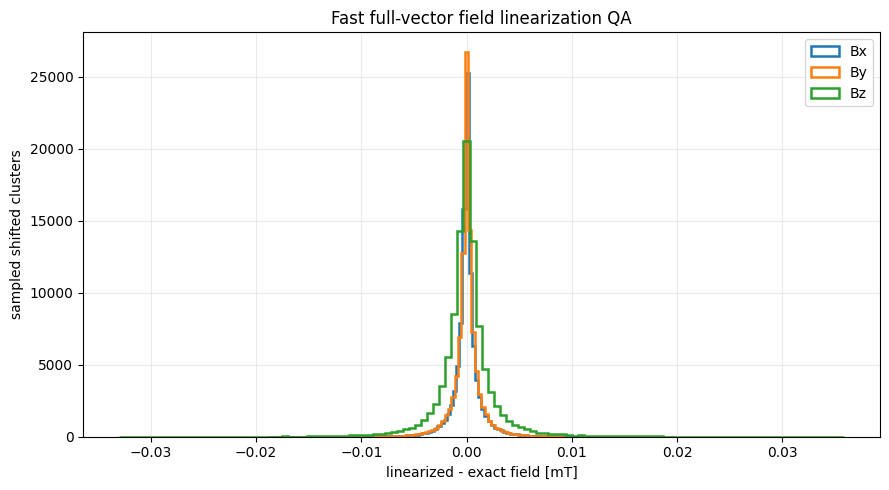

In [6]:
# ============================================================
# Fast-field approximation QA
# ============================================================

rng = np.random.default_rng(seed)
qa_count = min(100000, len(clusters))
qa_indices = rng.choice(len(clusters), size=qa_count, replace=False)

qa_xyz = cluster_xyz[qa_indices]
qa_b0 = cluster_field[qa_indices]
qa_gradient = cluster_field_gradient[qa_indices]

# Typical test shifts of order 2 mm, clipped at 5 mm.
qa_shift = np.clip(
    rng.normal(0.0, 0.20, size=(qa_count, 3)),
    -0.50,
    0.50,
)
qa_xyz_shifted = qa_xyz + qa_shift

qa_exact = np.column_stack(
    evaluate_field_map(
        qa_xyz_shifted[:, 0],
        qa_xyz_shifted[:, 1],
        qa_xyz_shifted[:, 2],
    )
)
qa_linearized = qa_b0 + np.einsum(
    'nij,nj->ni',
    qa_gradient,
    qa_shift,
)

qa_valid = (
    np.all(np.isfinite(qa_exact), axis=1)
    & np.all(np.isfinite(qa_linearized), axis=1)
)
qa_difference_millitesla = 1000.0 * (
    qa_linearized[qa_valid] - qa_exact[qa_valid]
)

print('Field linearization QA rows:', int(np.count_nonzero(qa_valid)))
print(
    'Field linearization mean error [mT] Bx,By,Bz:',
    np.mean(qa_difference_millitesla, axis=0),
)
print(
    'Field linearization RMS error [mT] Bx,By,Bz:',
    np.std(qa_difference_millitesla, axis=0),
)

plt.figure(figsize=(9, 5))
for component, label in enumerate(['Bx', 'By', 'Bz']):
    plt.hist(
        qa_difference_millitesla[:, component],
        bins=120,
        histtype='step',
        linewidth=1.8,
        label=label,
    )
plt.xlabel('linearized - exact field [mT]')
plt.ylabel('sampled shifted clusters')
plt.title('Fast full-vector field linearization QA')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# Full-field baseline convention
# ============================================================
#
# The current V0 reconstruction already supplies the baseline daughter momenta
# and candidate mass. Do NOT apply the old |<Bz>|/1.4 rescaling.
#
# The differentiable response is constructed so that zero DNN correction gives
# momentum_scale=1 and mass_after=selected_mass.

candidates['baseline_mass'] = candidates['selected_mass'].astype(np.float32)

print(
    'Baseline K0S mean mass:',
    float(
        candidates.loc[
            candidates['channel'] == 0,
            'baseline_mass',
        ].mean()
    ),
)


Baseline K0S mean mass: 0.4975455403327942


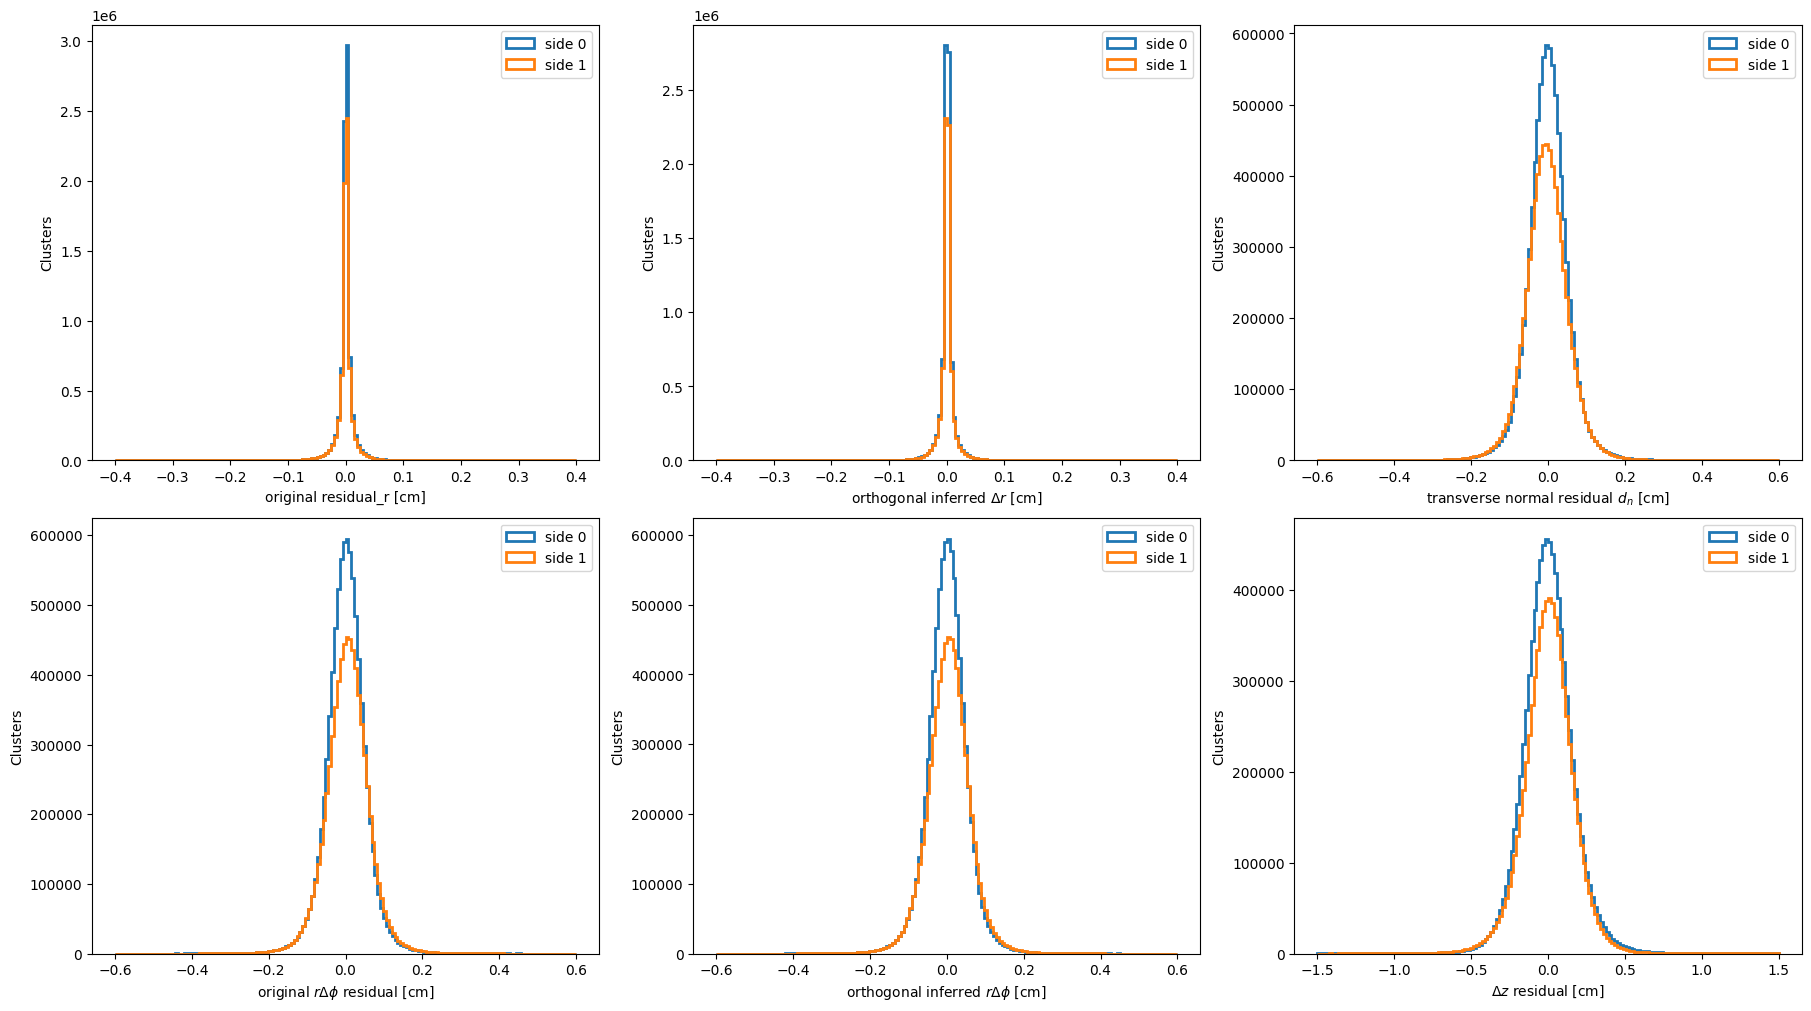

      residual_r  residual_r_orthogonal  residual_rphi  \
side                                                     
0       0.021312               0.018663       0.077933   
1       0.021080               0.018756       0.077416   

      residual_rphi_orthogonal  residual_normal_xy  residual_z  
side                                                            
0                     0.078133            0.080331    0.201402  
1                     0.077589            0.079820    0.199279  


In [8]:
# ============================================================
# Residual QA before training
# ============================================================

kshort_cluster_qa = clusters.loc[
    (clusters['channel'] == 0)
    & clusters['physical_side_z_valid'].astype(bool)
].copy()

figure, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

qa_definitions = [
    ('residual_r', r'original residual_r [cm]', (-0.40, 0.40)),
    ('residual_r_orthogonal', r'orthogonal inferred $\Delta r$ [cm]', (-0.40, 0.40)),
    ('residual_normal_xy', r'transverse normal residual $d_n$ [cm]', (-0.60, 0.60)),
    ('residual_rphi', r'original $r\Delta\phi$ residual [cm]', (-0.60, 0.60)),
    ('residual_rphi_orthogonal', r'orthogonal inferred $r\Delta\phi$ [cm]', (-0.60, 0.60)),
    ('residual_z', r'$\Delta z$ residual [cm]', (-1.50, 1.50)),
]

for axis, (column, label, value_range) in zip(axes.flat, qa_definitions):
    for side in [0, 1]:
        values = kshort_cluster_qa.loc[
            kshort_cluster_qa['side'] == side,
            column,
        ].to_numpy(float)
        values = values[np.isfinite(values)]
        axis.hist(
            values,
            bins=160,
            range=value_range,
            histtype='step',
            linewidth=2,
            label=f'side {side}',
        )
    axis.set_xlabel(label)
    axis.set_ylabel('Clusters')
    axis.legend()

plt.show()

# Directly demonstrate why the original residual_r is not used.
print(
    kshort_cluster_qa.groupby('side')[[
        'residual_r',
        'residual_r_orthogonal',
        'residual_rphi',
        'residual_rphi_orthogonal',
        'residual_normal_xy',
        'residual_z',
    ]].std()
)


## Build one joint K0S candidate sample

Residual pretraining remains side-specific, but the physics stage now uses **all accepted K0S candidates together**, including cross-side candidates when they exist.

Each daughter keeps its own side label. During the differentiable refit, the daughter is passed through the corresponding South/North spatial model. This makes the \(\pi^+/\pi^-\) spectrum constraint truly global instead of imposing it independently on the two detector halves.


In [9]:
# ============================================================
# Joint candidate-to-cluster tensor construction
# ============================================================

FIELD_COMPONENT_COLUMNS = [
    'field_bx_tesla',
    'field_by_tesla',
    'field_bz_tesla',
]

FIELD_GRADIENT_COLUMNS = [
    f'd{field_name}_d{coordinate_name}_tesla_per_cm'
    for field_name in ['bx', 'by', 'bz']
    for coordinate_name in ['x', 'y', 'z']
]


def clean_track_clusters(frame):
    frame = frame.copy()

    finite_columns = [
        'cluster_r', 'cluster_phi', 'cluster_z',
        'residual_normal_xy',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'residual_z', 'sigma_z_filled',
        *FIELD_COMPONENT_COLUMNS,
        *FIELD_GRADIENT_COLUMNS,
    ]

    finite = np.ones(len(frame), dtype=bool)
    for column in finite_columns:
        finite &= np.isfinite(frame[column].to_numpy(float))

    frame = frame.loc[finite]
    frame = frame.loc[frame['physical_side_z_valid'].astype(bool)]
    frame = frame.loc[(frame['layer'] >= 7) & (frame['layer'] <= 54)]
    frame = frame.loc[~frame['layer'].isin(excluded_layers)]

    frame = frame.loc[
        (np.abs(frame['residual_normal_xy']) < maximum_abs_residual_normal_cm)
        & (np.abs(frame['residual_z']) < maximum_abs_residual_z_cm)
    ]

    if use_recommended_clusters_only:
        frame = frame.loc[
            frame['recommended_for_reference_fit'].astype(bool)
        ]

    if use_kalman_used_clusters_only:
        frame = frame.loc[
            frame['kalman_measurement_used'].astype(bool)
        ]

    sort_columns = ['layer']
    if 'kalman_measurement_chi2' in frame.columns:
        sort_columns.append('kalman_measurement_chi2')

    frame = frame.sort_values(sort_columns)
    frame = frame.drop_duplicates('layer', keep='first')

    radial_modules = set(
        frame.loc[
            frame['radial_module'] >= 0,
            'radial_module',
        ].astype(int)
    )
    if len(radial_modules) < minimum_tpc_modules_per_track:
        return frame.iloc[0:0]

    radial_span_cm = (
        float(frame['cluster_r'].max())
        - float(frame['cluster_r'].min())
        if len(frame)
        else 0.0
    )
    if radial_span_cm < minimum_track_radial_span_cm:
        return frame.iloc[0:0]

    return frame.sort_values('layer').head(maximum_clusters)


def smooth_pair_weights(pt1, pt2):
    if not use_smooth_track_pt_reweighting:
        return np.ones(len(pt1), dtype=np.float32)

    all_pt = np.concatenate([pt1, pt2]).astype(float)
    safe = np.clip(all_pt, 0.20, 5.00)
    edges = np.linspace(np.log(0.20), np.log(5.00), 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(np.log(safe), bins=edges)

    offsets = np.arange(-8, 9, dtype=float)
    kernel = np.exp(-0.5 * (offsets / 2.0) ** 2)
    kernel /= kernel.sum()

    density = np.convolve(counts.astype(float), kernel, mode='same')
    positive = density[density > 0]
    reference = np.median(positive) if len(positive) else 1.0
    density = np.maximum(density, 0.05 * max(reference, 1.0))

    weights = (reference / density) ** track_pt_weight_power
    weights = np.clip(weights, minimum_pair_weight, maximum_pair_weight)

    def evaluate(values):
        return np.interp(
            np.log(np.clip(values, 0.20, 5.00)),
            centers,
            weights,
            left=weights[0],
            right=weights[-1],
        )

    pair = np.sqrt(evaluate(pt1) * evaluate(pt2))
    pair /= np.mean(pair)

    return np.clip(
        pair,
        minimum_pair_weight,
        maximum_pair_weight,
    ).astype(np.float32)


def build_joint_channel_arrays(channel):
    candidate_frame = candidates.loc[
        candidates['channel'] == channel
    ].copy()

    if channel == 0:
        candidate_frame = candidate_frame.loc[
            candidate_frame['pass_cut03'].astype(bool)
            & candidate_frame['pass_pion_pid'].astype(bool)
            & candidate_frame['pass_signed_delta_phi'].astype(bool)
        ]

    channel_clusters = clusters.loc[
        clusters['channel'] == channel
    ]

    grouped = {
        key: value
        for key, value in channel_clusters.groupby(
            ['candidate_id', 'daughter'],
            sort=False,
        )
    }

    records = []
    for row in candidate_frame.itertuples(index=False):
        key1 = (row.candidate_id, 1)
        key2 = (row.candidate_id, 2)

        if key1 not in grouped or key2 not in grouped:
            continue

        first = clean_track_clusters(grouped[key1])
        second = clean_track_clusters(grouped[key2])

        if (
            len(first) < minimum_clusters_per_track
            or len(second) < minimum_clusters_per_track
        ):
            continue

        first_side = int(round(float(row.side1)))
        second_side = int(round(float(row.side2)))

        if not np.all(first['side'].to_numpy(int) == first_side):
            continue
        if not np.all(second['side'].to_numpy(int) == second_side):
            continue

        records.append((row, first, second))

    if not records:
        raise RuntimeError(f'No usable candidates for channel={channel}')

    number = len(records)
    shape = (number, maximum_clusters)

    float_track_fields = [
        'r', 'phi_cluster', 'z_cluster',
        'res_normal',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'res_z', 'sigma_z', 'mask',
        'field_bx', 'field_by', 'field_bz',
        'dbx_dx', 'dbx_dy', 'dbx_dz',
        'dby_dx', 'dby_dy', 'dby_dz',
        'dbz_dx', 'dbz_dy', 'dbz_dz',
    ]

    output = {}
    for suffix in ['1', '2']:
        for field in float_track_fields:
            output[f'{field}{suffix}'] = np.zeros(
                shape,
                dtype=np.float32,
            )

    scalar_float_names = [
        'selected_mass', 'baseline_mass', 'pair_pt',
        'pca_x', 'pca_y', 'pca_z',
        'charge1', 'charge2',
        'pt1', 'pt2', 'phi1', 'phi2', 'eta1', 'eta2',
        'px1', 'py1', 'pz1', 'px2', 'py2', 'pz2',
    ]

    for name in scalar_float_names:
        output[name] = np.zeros(number, dtype=np.float32)

    output['candidate_id'] = np.zeros(number, dtype=np.int64)
    output['event_parity'] = np.zeros(number, dtype=np.int64)
    output['side1'] = np.zeros(number, dtype=np.int64)
    output['side2'] = np.zeros(number, dtype=np.int64)
    output['same_side'] = np.zeros(number, dtype=np.int64)
    output['channel'] = np.full(number, channel, dtype=np.int64)

    def fill_track(index, frame, suffix):
        count = len(frame)

        mappings = {
            f'r{suffix}': 'cluster_r',
            f'phi_cluster{suffix}': 'cluster_phi',
            f'z_cluster{suffix}': 'cluster_z',
            f'res_normal{suffix}': 'residual_normal_xy',
            f'normal_projection_r{suffix}': 'normal_projection_r',
            f'normal_projection_rphi{suffix}': 'normal_projection_rphi',
            f'sigma_normal{suffix}': 'sigma_normal',
            f'res_z{suffix}': 'residual_z',
            f'sigma_z{suffix}': 'sigma_z_filled',
            f'field_bx{suffix}': 'field_bx_tesla',
            f'field_by{suffix}': 'field_by_tesla',
            f'field_bz{suffix}': 'field_bz_tesla',
            f'dbx_dx{suffix}': 'dbx_dx_tesla_per_cm',
            f'dbx_dy{suffix}': 'dbx_dy_tesla_per_cm',
            f'dbx_dz{suffix}': 'dbx_dz_tesla_per_cm',
            f'dby_dx{suffix}': 'dby_dx_tesla_per_cm',
            f'dby_dy{suffix}': 'dby_dy_tesla_per_cm',
            f'dby_dz{suffix}': 'dby_dz_tesla_per_cm',
            f'dbz_dx{suffix}': 'dbz_dx_tesla_per_cm',
            f'dbz_dy{suffix}': 'dbz_dy_tesla_per_cm',
            f'dbz_dz{suffix}': 'dbz_dz_tesla_per_cm',
        }

        for output_name, column in mappings.items():
            output[output_name][index, :count] = (
                frame[column].to_numpy(np.float32)
            )

        output[f'mask{suffix}'][index, :count] = 1.0

    for index, (row, first, second) in enumerate(records):
        for name in scalar_float_names:
            output[name][index] = getattr(row, name)

        output['candidate_id'][index] = int(row.candidate_id)
        output['event_parity'][index] = int(row.event_parity)
        output['side1'][index] = int(row.side1)
        output['side2'][index] = int(row.side2)
        output['same_side'][index] = int(bool(row.same_side))

        fill_track(index, first, '1')
        fill_track(index, second, '2')

    output['pair_weight'] = smooth_pair_weights(
        output['pt1'],
        output['pt2'],
    )

    # Filled after the fixed pre-training K0S mass model is fitted.
    output['signal_probability'] = np.ones(number, dtype=np.float32)

    print(
        f'channel={channel}: {number} usable candidates; '
        f'same-side fraction={np.mean(output["same_side"]):.4f}'
    )

    for side in [0, 1]:
        daughter_count = (
            np.count_nonzero(output['side1'] == side)
            + np.count_nonzero(output['side2'] == side)
        )
        print(f'  daughter tracks on side {side}: {daughter_count}')

    return output


kshort_arrays = build_joint_channel_arrays(0)

validation_arrays = {}
for channel in [1, 2]:
    try:
        validation_arrays[channel] = build_joint_channel_arrays(channel)
    except RuntimeError as error:
        print(error)


channel=0: 249765 usable candidates; same-side fraction=0.9803
  daughter tracks on side 0: 271139
  daughter tracks on side 1: 228391
channel=1: 40570 usable candidates; same-side fraction=0.9779
  daughter tracks on side 0: 41736
  daughter tracks on side 1: 39404
channel=2: 43600 usable candidates; same-side fraction=0.9780
  daughter tracks on side 0: 47166
  daughter tracks on side 1: 40034


In [10]:
# ============================================================
# Cache joint arrays
# ============================================================

kshort_npz_file = cache_dir / 'kshort_joint.npz'
np.savez_compressed(kshort_npz_file, **kshort_arrays)
print('Wrote:', kshort_npz_file)

validation_npz_files = {}
for channel, arrays in validation_arrays.items():
    output_file = cache_dir / f'channel{channel}_joint.npz'
    np.savez_compressed(output_file, **arrays)
    validation_npz_files[channel] = output_file
    print('Wrote:', output_file)


def load_npz_dictionary(path):
    with np.load(path, allow_pickle=False) as input_file:
        return {
            key: input_file[key]
            for key in input_file.files
        }


Wrote: output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_wide/tensor_cache/kshort_joint.npz
Wrote: output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_wide/tensor_cache/channel1_joint.npz
Wrote: output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_wide/tensor_cache/channel2_joint.npz


In [11]:
# ============================================================
# PyTorch datasets
# ============================================================

class CandidateDataset(Dataset):
    def __init__(self, arrays, indices):
        self.data = {}
        number_of_candidates = len(arrays['candidate_id'])

        for key, values in arrays.items():
            if (
                isinstance(values, np.ndarray)
                and len(values) == number_of_candidates
            ):
                self.data[key] = torch.from_numpy(values[indices])

    def __len__(self):
        return len(self.data['candidate_id'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


class ResidualDataset(Dataset):
    def __init__(self, arrays):
        self.data = {
            key: torch.from_numpy(value)
            for key, value in arrays.items()
        }

    def __len__(self):
        return len(self.data['r'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


def flatten_training_clusters_for_side(arrays, candidate_indices, side):
    output_lists = {
        key: []
        for key in [
            'r', 'phi', 'z',
            'res_normal',
            'normal_projection_r', 'normal_projection_rphi',
            'sigma_normal',
            'res_z', 'sigma_z',
        ]
    }

    for suffix in ['1', '2']:
        daughter_on_side = (
            arrays[f'side{suffix}'][candidate_indices] == side
        )
        selected_candidate_indices = candidate_indices[daughter_on_side]

        if len(selected_candidate_indices) == 0:
            continue

        mask = (
            arrays[f'mask{suffix}'][selected_candidate_indices] > 0.5
        )

        source_names = {
            'r': f'r{suffix}',
            'phi': f'phi_cluster{suffix}',
            'z': f'z_cluster{suffix}',
            'res_normal': f'res_normal{suffix}',
            'normal_projection_r': f'normal_projection_r{suffix}',
            'normal_projection_rphi': f'normal_projection_rphi{suffix}',
            'sigma_normal': f'sigma_normal{suffix}',
            'res_z': f'res_z{suffix}',
            'sigma_z': f'sigma_z{suffix}',
        }

        for output_name, source_name in source_names.items():
            output_lists[output_name].append(
                arrays[source_name][selected_candidate_indices][mask]
                .astype(np.float32)
            )

    output = {}
    for key, pieces in output_lists.items():
        if not pieces:
            raise RuntimeError(f'No residual clusters for side {side}')
        output[key] = np.concatenate(pieces).astype(np.float32)

    return output


## Smooth drift field + fast full-field response

The spatial network itself is unchanged. The differentiable track response is new:

1. build raw and DNN-corrected 3-D cluster coordinates;
2. evaluate the full magnetic-field vector at both trajectories;
3. estimate \(q/p\) from the vector Lorentz-bending equation over adjacent track segments;
4. update the existing full-field momentum magnitude with the **raw/corrected \(q/p\) ratio**;
5. apply the small raw-to-corrected inner-track tangent change to the input momentum direction.

Because the response is relative, zero correction exactly reproduces the input V0 momentum.


In [12]:
# ============================================================
# Spatial network and differentiable refit helpers
# ============================================================

class SpatialResidualNetwork(nn.Module):
    number_of_sectors = 12
    number_of_radial_modules = 3
    number_of_local_modules = (
        number_of_sectors * number_of_radial_modules
    )

    def __init__(self, side):
        super().__init__()

        if side not in (0, 1):
            raise ValueError('side must be 0 or 1')

        self.side = int(side)

        radial_centers = torch.linspace(
            radial_basis_minimum_cm,
            radial_basis_maximum_cm,
            number_of_radial_basis_functions,
        )

        radial_spacing = (
            radial_basis_maximum_cm
            - radial_basis_minimum_cm
        ) / max(number_of_radial_basis_functions - 1, 1)

        self.register_buffer('radial_centers', radial_centers)
        self.radial_width = radial_basis_width_scale * radial_spacing

        input_width = (
            number_of_radial_basis_functions
            + 2 * number_of_phi_harmonics
            + 2
        )

        layers = []
        width = input_width

        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(width, hidden_width),
                nn.SiLU(),
                nn.Dropout(dropout_probability),
            ])
            width = hidden_width

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(
            width,
            3 if include_z_correction else 2,
        )

        # The smooth drift-dependent DNN starts from zero.
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

        # ----------------------------------------------------
        # Side-level pad-plane alignment
        # ----------------------------------------------------
        #
        # The first two parameters represent constant Delta r
        # and rDeltaPhi offsets at the pad plane.
        #
        # The four tilt parameters describe linear variation in
        # the normalized transverse coordinates:
        #
        # Delta r tilt       = a_x * x_norm + a_y * y_norm
        # rDeltaPhi tilt     = b_x * x_norm + b_y * y_norm
        #
        # tanh keeps every contribution inside its configured
        # physical bound.

        initial_delta_r = float(initial_side_delta_r_cm[self.side])
        initial_rdelta_phi = float(
            initial_side_rdelta_phi_cm[self.side]
        )

        self.side_offset_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                initial_delta_r,
                maximum_side_offset_cm,
            ),
            self.inverse_bounded_tanh(
                initial_rdelta_phi,
                maximum_side_offset_cm,
            ),
        ], dtype=torch.float32))

        initial_tilt = initial_side_tilt_coefficients[self.side]
        if len(initial_tilt) != 4:
            raise ValueError(
                'Each side requires four initial tilt coefficients'
            )

        self.side_tilt_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                float(value),
                maximum_side_tilt_displacement_cm,
            )
            for value in initial_tilt
        ], dtype=torch.float32))

        # One Delta r and one rDeltaPhi displacement for each
        # of the 36 modules on this side. They begin at zero.
        self.module_offset_raw = nn.Parameter(torch.zeros(
            self.number_of_local_modules,
            2,
            dtype=torch.float32,
        ))

    @staticmethod
    def inverse_bounded_tanh(value, maximum):
        if maximum <= 0:
            return 0.0

        ratio = max(
            min(float(value) / float(maximum), 0.999999),
            -0.999999,
        )

        return math.atanh(ratio)

    def physical_domain_and_drift_fraction(self, z):
        if self.side == 0:
            physical = (
                (z <= central_membrane_tolerance_cm)
                & (z >= -z_pad_cm - pad_plane_tolerance_cm)
            )
        else:
            physical = (
                (z >= -central_membrane_tolerance_cm)
                & (z <= z_pad_cm + pad_plane_tolerance_cm)
            )

        drift_fraction = torch.clamp(
            1.0 - torch.abs(z) / z_pad_cm,
            min=0.0,
            max=1.0,
        )

        pad_plane_fraction = 1.0 - drift_fraction

        return (
            physical.to(z.dtype),
            drift_fraction,
            pad_plane_fraction,
        )

    def features(self, r, phi, z):
        radial = torch.exp(
            -0.5
            * (
                (
                    r[..., None]
                    - self.radial_centers
                )
                / self.radial_width
            ) ** 2
        )

        phi_features = []

        for harmonic in range(1, number_of_phi_harmonics + 1):
            phi_features.extend([
                torch.sin(harmonic * phi)[..., None],
                torch.cos(harmonic * phi)[..., None],
            ])

        _, drift_fraction, _ = (
            self.physical_domain_and_drift_fraction(z)
        )

        return torch.cat([
            radial,
            *phi_features,
            drift_fraction[..., None],
            (drift_fraction ** 2)[..., None],
        ], dim=-1)

    def local_module_index(self, r, phi):
        # Radial module from the known TPC boundaries.
        radial_module = torch.zeros_like(r, dtype=torch.long)
        radial_module = torch.where(
            r >= 41.153,
            torch.ones_like(radial_module),
            radial_module,
        )
        radial_module = torch.where(
            r >= 58.367,
            torch.full_like(radial_module, 2),
            radial_module,
        )
        radial_module = torch.clamp(radial_module, 0, 2)

        wrapped_phi = torch.remainder(
            phi + math.pi,
            2.0 * math.pi,
        )

        sector = torch.floor(
            wrapped_phi / (2.0 * math.pi / 12.0)
        ).to(torch.long)
        sector = torch.clamp(sector, 0, 11)

        return 12 * radial_module + sector

    def side_alignment_field(self, r, phi):
        side_offset = (
            maximum_side_offset_cm
            * torch.tanh(self.side_offset_raw)
        )

        tilt = (
            maximum_side_tilt_displacement_cm
            * torch.tanh(self.side_tilt_raw)
        )

        # Normalize x and y by the outer TPC radius. This makes
        # each tilt coefficient approximately the displacement
        # scale reached near the outer edge.
        x_normalized = (
            r * torch.cos(phi)
            / radial_basis_maximum_cm
        )
        y_normalized = (
            r * torch.sin(phi)
            / radial_basis_maximum_cm
        )

        delta_r = (
            side_offset[0]
            + tilt[0] * x_normalized
            + tilt[1] * y_normalized
        )

        r_delta_phi = (
            side_offset[1]
            + tilt[2] * x_normalized
            + tilt[3] * y_normalized
        )

        return delta_r, r_delta_phi

    def module_alignment_field(self, r, phi):
        module_index = self.local_module_index(r, phi)

        bounded_module_offsets = (
            maximum_module_offset_cm
            * torch.tanh(self.module_offset_raw)
        )

        selected = bounded_module_offsets[module_index]

        return selected[..., 0], selected[..., 1]

    def alignment_parameters(self):
        return {
            'side_offset': (
                maximum_side_offset_cm
                * torch.tanh(self.side_offset_raw)
            ),
            'side_tilt': (
                maximum_side_tilt_displacement_cm
                * torch.tanh(self.side_tilt_raw)
            ),
            'module_offset': (
                maximum_module_offset_cm
                * torch.tanh(self.module_offset_raw)
            ),
        }

    def forward(self, r, phi, z):
        (
            physical,
            drift_fraction,
            pad_plane_fraction,
        ) = self.physical_domain_and_drift_fraction(z)

        feature_tensor = self.features(r, phi, z)
        original_shape = r.shape

        raw = self.output(
            self.trunk(
                feature_tensor.reshape(
                    -1,
                    feature_tensor.shape[-1],
                )
            )
        ).reshape(*original_shape, -1)

        drift_delta_r = (
            drift_fraction
            * maximum_delta_r_cm
            * torch.tanh(raw[..., 0])
        )

        drift_r_delta_phi = (
            drift_fraction
            * maximum_r_delta_phi_cm
            * torch.tanh(raw[..., 1])
        )

        side_delta_r, side_r_delta_phi = (
            self.side_alignment_field(r, phi)
        )

        module_delta_r, module_r_delta_phi = (
            self.module_alignment_field(r, phi)
        )

        pad_delta_r = pad_plane_fraction * (
            side_delta_r + module_delta_r
        )

        pad_r_delta_phi = pad_plane_fraction * (
            side_r_delta_phi + module_r_delta_phi
        )

        delta_r = physical * (
            drift_delta_r + pad_delta_r
        )

        r_delta_phi = physical * (
            drift_r_delta_phi + pad_r_delta_phi
        )

        if include_z_correction:
            delta_z = (
                physical
                * drift_fraction
                * maximum_delta_z_cm
                * torch.tanh(raw[..., 2])
            )
        else:
            delta_z = torch.zeros_like(delta_r)

        return delta_r, r_delta_phi, delta_z

def wrap_phi_torch(value):
    return torch.atan2(torch.sin(value), torch.cos(value))


class JointSpatialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.side_models = nn.ModuleDict({
            '0': SpatialResidualNetwork(0),
            '1': SpatialResidualNetwork(1),
        })


def raw_position_from_cylindrical(r, phi, z):
    return torch.stack([
        r * torch.cos(phi),
        r * torch.sin(phi),
        z,
    ], dim=-1)


def field_tensor_from_batch(batch, suffix):
    return torch.stack([
        batch[f'field_bx{suffix}'],
        batch[f'field_by{suffix}'],
        batch[f'field_bz{suffix}'],
    ], dim=-1)


def field_gradient_tensor_from_batch(batch, suffix):
    return torch.stack([
        torch.stack([
            batch[f'dbx_dx{suffix}'],
            batch[f'dbx_dy{suffix}'],
            batch[f'dbx_dz{suffix}'],
        ], dim=-1),
        torch.stack([
            batch[f'dby_dx{suffix}'],
            batch[f'dby_dy{suffix}'],
            batch[f'dby_dz{suffix}'],
        ], dim=-1),
        torch.stack([
            batch[f'dbz_dx{suffix}'],
            batch[f'dbz_dy{suffix}'],
            batch[f'dbz_dz{suffix}'],
        ], dim=-1),
    ], dim=-2)


def corrected_field_from_raw(
    raw_position,
    corrected_position,
    raw_field,
    raw_gradient,
):
    if field_evaluation_mode == 'linearized':
        displacement = corrected_position - raw_position
        return (
            raw_field
            + torch.einsum(
                '...ij,...j->...i',
                raw_gradient,
                displacement,
            )
        )

    if field_evaluation_mode == 'torch_trilinear':
        return torch_trilinear_field(corrected_position)

    raise ValueError(
        f'Unknown field_evaluation_mode={field_evaluation_mode!r}'
    )


def estimate_q_over_p_from_trajectory(position, field, mask):
    """
    Fast full-vector curvature estimator.

    For unit tangent u(s):
        du/ds = 0.00299792458 * (q/p) * (u x B)

    Only the raw/corrected ratio is used downstream.
    """
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]

    ds = torch.sqrt(
        torch.clamp(
            torch.sum(segment * segment, dim=-1),
            min=1.0e-10,
        )
    )

    tangent = segment / ds[..., None]

    bend_mask = segment_mask[:, 1:] * segment_mask[:, :-1]
    ds_mid = 0.5 * (ds[:, 1:] + ds[:, :-1])

    du_ds = (
        tangent[:, 1:, :] - tangent[:, :-1, :]
    ) / torch.clamp(ds_mid[..., None], min=1.0e-6)

    tangent_mid = tangent[:, 1:, :] + tangent[:, :-1, :]
    tangent_mid = tangent_mid / torch.sqrt(
        torch.clamp(
            torch.sum(tangent_mid * tangent_mid, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    field_mid = field[:, 1:-1, :]
    lorentz_direction = torch.cross(
        tangent_mid,
        field_mid,
        dim=-1,
    )

    dot_term = torch.sum(
        du_ds * lorentz_direction,
        dim=-1,
    )
    lorentz_norm2 = torch.sum(
        lorentz_direction * lorentz_direction,
        dim=-1,
    )

    weight = bend_mask * torch.clamp(ds_mid, min=0.0)

    numerator = torch.sum(weight * dot_term, dim=1)
    denominator = (
        lorentz_curvature_constant
        * torch.sum(weight * lorentz_norm2, dim=1)
    )

    q_over_p = numerator / torch.clamp(
        denominator,
        min=1.0e-10,
    )

    effective_bends = torch.sum(bend_mask, dim=1)
    valid = (
        (effective_bends >= 3)
        & torch.isfinite(q_over_p)
        & (torch.abs(q_over_p) > 1.0e-6)
    )

    return q_over_p, valid


def inner_tangent(position, mask):
    """
    Smooth tangent estimate near the innermost accepted TPC clusters.
    Layer ordering is inner -> outer.
    """
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]

    unit = segment / torch.sqrt(
        torch.clamp(
            torch.sum(segment * segment, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    index = torch.arange(
        unit.shape[1],
        dtype=unit.dtype,
        device=unit.device,
    )[None, :]

    weight = segment_mask * torch.exp(-index / 2.0)
    tangent = torch.sum(weight[..., None] * unit, dim=1)

    tangent = tangent / torch.sqrt(
        torch.clamp(
            torch.sum(tangent * tangent, dim=-1),
            min=1.0e-10,
        )
    )[..., None]

    return tangent


def refit_track_full_field(
    model,
    r,
    phi,
    z,
    mask,
    charge,
    original_pt,
    original_phi,
    original_eta,
    raw_field,
    raw_field_gradient,
):
    raw_position = raw_position_from_cylindrical(r, phi, z)

    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    corrected_r = r - delta_r * mask
    corrected_phi = (
        phi
        - (
            r_delta_phi
            / torch.clamp(r, min=1.0e-6)
        ) * mask
    )
    corrected_z = z - delta_z * mask

    corrected_position = raw_position_from_cylindrical(
        corrected_r,
        corrected_phi,
        corrected_z,
    )

    corrected_field = corrected_field_from_raw(
        raw_position,
        corrected_position,
        raw_field,
        raw_field_gradient,
    )

    raw_q_over_p, raw_qop_valid = estimate_q_over_p_from_trajectory(
        raw_position,
        raw_field,
        mask,
    )
    corrected_q_over_p, corrected_qop_valid = estimate_q_over_p_from_trajectory(
        corrected_position,
        corrected_field,
        mask,
    )

    relative_scale = (
        torch.abs(raw_q_over_p)
        / torch.clamp(
            torch.abs(corrected_q_over_p),
            min=1.0e-6,
        )
    )

    valid_scale = (
        raw_qop_valid
        & corrected_qop_valid
        & torch.isfinite(relative_scale)
    )

    relative_scale = torch.where(
        valid_scale,
        relative_scale,
        torch.ones_like(relative_scale),
    )

    relative_scale = torch.clamp(
        relative_scale,
        min=minimum_refit_scale,
        max=maximum_refit_scale,
    )

    relative_scale = (
        1.0
        + momentum_scale_response_strength
        * (relative_scale - 1.0)
    )

    original_momentum = torch.stack([
        original_pt * torch.cos(original_phi),
        original_pt * torch.sin(original_phi),
        original_pt * torch.sinh(original_eta),
    ], dim=1)

    original_p = torch.sqrt(
        torch.clamp(
            torch.sum(original_momentum * original_momentum, dim=1),
            min=1.0e-10,
        )
    )
    original_unit = original_momentum / original_p[:, None]

    raw_inner_tangent = inner_tangent(raw_position, mask)
    corrected_inner_tangent = inner_tangent(corrected_position, mask)

    orientation = torch.where(
        torch.sum(raw_inner_tangent * original_unit, dim=1) >= 0.0,
        torch.ones_like(original_p),
        -torch.ones_like(original_p),
    )

    raw_inner_tangent = raw_inner_tangent * orientation[:, None]
    corrected_inner_tangent = corrected_inner_tangent * orientation[:, None]

    direction_delta = corrected_inner_tangent - raw_inner_tangent
    corrected_unit = (
        original_unit
        + direction_correction_strength * direction_delta
    )

    corrected_unit = corrected_unit / torch.sqrt(
        torch.clamp(
            torch.sum(corrected_unit * corrected_unit, dim=1),
            min=1.0e-10,
        )
    )[:, None]

    corrected_p = original_p * relative_scale
    corrected_momentum = corrected_unit * corrected_p[:, None]

    corrected_pt = torch.sqrt(
        torch.clamp(
            corrected_momentum[:, 0] ** 2
            + corrected_momentum[:, 1] ** 2,
            min=0.0,
        )
    )

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'momentum_scale': relative_scale,
        'raw_q_over_p': raw_q_over_p,
        'corrected_q_over_p': corrected_q_over_p,
        'qop_valid': valid_scale,
        'delta_r': delta_r,
        'r_delta_phi': r_delta_phi,
        'delta_z': delta_z,
    }


def scatter_track_results(indices_and_results, number_of_rows):
    all_indices = torch.cat([item[0] for item in indices_and_results])
    order = torch.argsort(all_indices)

    output = {}
    keys = indices_and_results[0][1].keys()

    for key in keys:
        concatenated = torch.cat(
            [item[1][key] for item in indices_and_results],
            dim=0,
        )
        output[key] = concatenated[order]

    if len(all_indices) != number_of_rows:
        raise RuntimeError(
            'Per-side refit did not cover the complete candidate batch'
        )

    return output


def refit_track_by_side(
    joint_model,
    r,
    phi,
    z,
    mask,
    charge,
    original_pt,
    original_phi,
    original_eta,
    track_side,
    raw_field,
    raw_field_gradient,
):
    pieces = []
    side_integer = track_side.to(torch.long)

    for side in [0, 1]:
        indices = torch.nonzero(
            side_integer == side,
            as_tuple=False,
        )[:, 0]

        if len(indices) == 0:
            continue

        result = refit_track_full_field(
            joint_model.side_models[str(side)],
            r[indices],
            phi[indices],
            z[indices],
            mask[indices],
            charge[indices],
            original_pt[indices],
            original_phi[indices],
            original_eta[indices],
            raw_field[indices],
            raw_field_gradient[indices],
        )
        pieces.append((indices, result))

    if not pieces:
        raise RuntimeError('No valid side found in candidate batch')

    return scatter_track_results(pieces, len(track_side))


def invariant_mass(momentum1, momentum2, mass1, mass2):
    energy1 = torch.sqrt(
        torch.sum(momentum1 ** 2, dim=1)
        + mass1 ** 2
    )
    energy2 = torch.sqrt(
        torch.sum(momentum2 ** 2, dim=1)
        + mass2 ** 2
    )

    total = momentum1 + momentum2
    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(total ** 2, dim=1)
    )

    return torch.sqrt(torch.clamp(mass_squared, min=0.0))


Fixed K0S mass model:
{
  "signal_fraction": 0.9975273768433653,
  "mean": 0.4975371434537627,
  "sigma": 0.021503086026504515,
  "slope": -0.9383241746194441,
  "fit_nll": -301808.6020515437,
  "n_candidates": 124783
}
signal probability: 0.9888257384300232 0.9984920620918274 0.9993306994438171


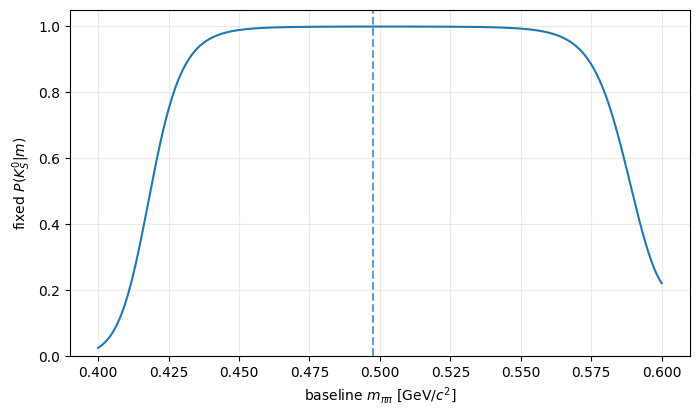

In [13]:
# ============================================================
# Fixed pre-training K0S signal probability
# ============================================================
#
# The charge-balance and mass losses should be driven by real K0S daughters,
# not by combinatorial pairs.  Fit the *uncorrected* full-field baseline mass
# once and freeze P(signal | m).  We deliberately do not recompute the
# probability from the corrected mass during training, otherwise the network
# could improve its loss simply by moving candidates into/out of the signal
# region.

from scipy.stats import norm as scipy_norm

def _normalized_linear_background(mass, slope, low=min_k0s_mass, high=max_k0s_mass):
    mass = np.asarray(mass, dtype=np.float64)
    center = 0.5 * (low + high)
    half_width = 0.5 * (high - low)
    u = (mass - center) / max(half_width, 1.0e-12)
    # slope is bounded so that 1+slope*u remains positive throughout [-1,1].
    density = np.clip(1.0 + slope * u, 1.0e-8, None)
    # Integral of the odd slope term vanishes on a symmetric interval.
    return density / (high - low)


def fit_fixed_k0s_mass_model(mass_values):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    mass_values = mass_values[
        np.isfinite(mass_values)
        & (mass_values >= min_k0s_mass)
        & (mass_values <= max_k0s_mass)
    ]

    if mass_values.size < 100:
        raise RuntimeError('Not enough K0S candidates to fit the fixed signal model.')

    def nll(theta):
        signal_logit, mean, log_sigma, slope_raw = theta
        signal_fraction = 1.0 / (1.0 + np.exp(-signal_logit))
        sigma = np.exp(log_sigma)
        slope = 0.95 * np.tanh(slope_raw)

        signal = scipy_norm.pdf(mass_values, loc=mean, scale=sigma)

        # Correct the Gaussian normalization for the finite fit window.
        norm_window = (
            scipy_norm.cdf(min_k0s_mass, loc=mean, scale=sigma)
            - scipy_norm.cdf(max_k0s_mass, loc=mean, scale=sigma)
        )
        norm_window = abs(norm_window)
        signal = signal / max(norm_window, 1.0e-12)

        background = _normalized_linear_background(
            mass_values,
            slope,
        )

        pdf = (
            signal_fraction * signal
            + (1.0 - signal_fraction) * background
        )
        return -np.log(np.clip(pdf, 1.0e-15, None)).sum()

    initial_sigma = np.clip(
        np.nanstd(
            mass_values[
                (mass_values > 0.47)
                & (mass_values < 0.525)
            ]
        ),
        0.004,
        0.025,
    )

    initial = np.array([
        0.0,
        pdg_kshort_mass,
        np.log(initial_sigma),
        0.0,
    ])

    fit = minimize(
        nll,
        initial,
        method='L-BFGS-B',
        bounds=[
            (-6.0, 6.0),
            (0.485, 0.510),
            (np.log(0.002), np.log(0.040)),
            (-3.0, 3.0),
        ],
    )

    if not fit.success:
        print('WARNING: fixed K0S mass fit:', fit.message)

    signal_logit, mean, log_sigma, slope_raw = fit.x

    model = {
        'signal_fraction': float(1.0 / (1.0 + np.exp(-signal_logit))),
        'mean': float(mean),
        'sigma': float(np.exp(log_sigma)),
        'slope': float(0.95 * np.tanh(slope_raw)),
        'fit_nll': float(fit.fun),
        'n_candidates': int(mass_values.size),
    }
    return model


def fixed_signal_probability(mass_values, model):
    mass_values = np.asarray(mass_values, dtype=np.float64)

    signal = scipy_norm.pdf(
        mass_values,
        loc=model['mean'],
        scale=model['sigma'],
    )

    norm_window = (
        scipy_norm.cdf(
            max_k0s_mass,
            loc=model['mean'],
            scale=model['sigma'],
        )
        - scipy_norm.cdf(
            min_k0s_mass,
            loc=model['mean'],
            scale=model['sigma'],
        )
    )
    signal = signal / max(norm_window, 1.0e-12)

    background = _normalized_linear_background(
        mass_values,
        model['slope'],
    )

    signal_weighted = model['signal_fraction'] * signal
    background_weighted = (1.0 - model['signal_fraction']) * background

    probability = signal_weighted / np.clip(
        signal_weighted + background_weighted,
        1.0e-15,
        None,
    )

    return np.clip(
        probability,
        minimum_signal_probability_for_physics,
        1.0,
    ).astype(np.float32)


training_mass_mask = (
    kshort_arrays['event_parity'].astype(np.int64)
    == training_parity
)

fixed_mass_model = fit_fixed_k0s_mass_model(
    kshort_arrays['baseline_mass'][training_mass_mask]
)

kshort_arrays['signal_probability'] = fixed_signal_probability(
    kshort_arrays['baseline_mass'],
    fixed_mass_model,
)

# Refresh the cache with the fixed signal weights.
np.savez_compressed(
    cache_dir / 'kshort_joint.npz',
    **kshort_arrays,
)

print('Fixed K0S mass model:')
print(json.dumps(fixed_mass_model, indent=2))
print(
    'signal probability:',
    float(kshort_arrays['signal_probability'].min()),
    float(kshort_arrays['signal_probability'].mean()),
    float(kshort_arrays['signal_probability'].max()),
)

mass_grid = np.linspace(min_k0s_mass, max_k0s_mass, 600)
probability_grid = fixed_signal_probability(
    mass_grid,
    fixed_mass_model,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mass_grid, probability_grid)
ax.axvline(pdg_kshort_mass, ls='--', alpha=0.7)
ax.set_xlabel(r'baseline $m_{\pi\pi}$ [GeV/$c^2$]')
ax.set_ylabel(r'fixed $P(K^0_S|m)$')
ax.set_ylim(0.0, 1.05)
ax.grid(alpha=0.25)
plt.show()


In [14]:
# ============================================================
# Batch correction and global physics losses
# ============================================================

def _track_field_tensors(batch, suffix):
    raw_field = torch.stack([
        batch[f'field_bx{suffix}'],
        batch[f'field_by{suffix}'],
        batch[f'field_bz{suffix}'],
    ], dim=-1)

    gradient = torch.stack([
        batch[f'dbx_dx{suffix}'], batch[f'dbx_dy{suffix}'], batch[f'dbx_dz{suffix}'],
        batch[f'dby_dx{suffix}'], batch[f'dby_dy{suffix}'], batch[f'dby_dz{suffix}'],
        batch[f'dbz_dx{suffix}'], batch[f'dbz_dy{suffix}'], batch[f'dbz_dz{suffix}'],
    ], dim=-1)

    gradient = gradient.reshape(
        *gradient.shape[:-1],
        3,
        3,
    )

    return raw_field, gradient


def correct_batch(joint_model, batch, channel=0):
    field1, gradient1 = _track_field_tensors(batch, '1')
    field2, gradient2 = _track_field_tensors(batch, '2')

    first = refit_track_by_side(
        joint_model,
        batch['r1'],
        batch['phi_cluster1'],
        batch['z_cluster1'],
        batch['mask1'],
        batch['charge1'],
        batch['pt1'],
        batch['phi1'],
        batch['eta1'],
        batch['side1'],
        field1,
        gradient1,
    )

    second = refit_track_by_side(
        joint_model,
        batch['r2'],
        batch['phi_cluster2'],
        batch['z_cluster2'],
        batch['mask2'],
        batch['charge2'],
        batch['pt2'],
        batch['phi2'],
        batch['eta2'],
        batch['side2'],
        field2,
        gradient2,
    )

    if channel == 0:
        mass1 = torch.full_like(batch['charge1'], pion_mass)
        mass2 = torch.full_like(batch['charge2'], pion_mass)
    elif channel == 1:
        # Lambda: positive daughter is proton.
        mass1 = torch.where(
            batch['charge1'] > 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] > 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )
    else:
        # anti-Lambda: negative daughter is antiproton.
        mass1 = torch.where(
            batch['charge1'] < 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] < 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )

    mass = invariant_mass(
        first['momentum'],
        second['momentum'],
        mass1,
        mass2,
    )

    return first, second, mass


def masked_huber(prediction, target, sigma, mask=None):
    normalized = (
        prediction - target
    ) / torch.clamp(sigma, min=1.0e-4)

    loss = F.smooth_l1_loss(
        normalized,
        torch.zeros_like(normalized),
        reduction='none',
    )

    if mask is None:
        return torch.mean(loss)

    return torch.sum(loss * mask) / torch.clamp(
        torch.sum(mask),
        min=1.0,
    )


def residual_batch_loss(model, batch):
    delta_r, r_delta_phi, delta_z = model(
        batch['r'],
        batch['phi'],
        batch['z'],
    )

    predicted_normal = (
        delta_r * batch['normal_projection_r']
        + r_delta_phi * batch['normal_projection_rphi']
    )

    loss = masked_huber(
        predicted_normal,
        batch['res_normal'],
        batch['sigma_normal'],
    )

    if include_z_correction:
        loss = loss + masked_huber(
            delta_z,
            batch['res_z'],
            batch['sigma_z'],
        )

    return loss


def candidate_residual_loss(joint_model, batch):
    track_losses = []

    for suffix in ['1', '2']:
        side_losses = []
        side_weights = []

        for side in [0, 1]:
            selected = (
                batch[f'side{suffix}'].to(torch.long) == side
            )

            if not torch.any(selected):
                continue

            model = joint_model.side_models[str(side)]

            delta_r, r_delta_phi, delta_z = model(
                batch[f'r{suffix}'][selected],
                batch[f'phi_cluster{suffix}'][selected],
                batch[f'z_cluster{suffix}'][selected],
            )

            predicted_normal = (
                delta_r
                * batch[f'normal_projection_r{suffix}'][selected]
                + r_delta_phi
                * batch[f'normal_projection_rphi{suffix}'][selected]
            )

            mask = batch[f'mask{suffix}'][selected]

            loss = masked_huber(
                predicted_normal,
                batch[f'res_normal{suffix}'][selected],
                batch[f'sigma_normal{suffix}'][selected],
                mask,
            )

            if include_z_correction:
                loss = loss + masked_huber(
                    delta_z,
                    batch[f'res_z{suffix}'][selected],
                    batch[f'sigma_z{suffix}'][selected],
                    mask,
                )

            side_losses.append(loss)
            side_weights.append(
                torch.sum(mask).detach()
            )

        if side_losses:
            denominator = torch.clamp(
                torch.stack(side_weights).sum(),
                min=1.0,
            )
            track_losses.append(
                sum(
                    loss * weight
                    for loss, weight in zip(side_losses, side_weights)
                ) / denominator
            )

    if not track_losses:
        first_parameter = next(joint_model.parameters())
        return torch.zeros(
            (),
            dtype=first_parameter.dtype,
            device=first_parameter.device,
        )

    return sum(track_losses) / len(track_losses)


def weighted_mean_variance_neff(values, weights):
    total_weight = torch.sum(weights)
    normalization = torch.clamp(total_weight, min=1.0e-12)

    mean = torch.sum(weights * values) / normalization

    variance = torch.sum(
        weights * (values - mean) ** 2
    ) / normalization

    sum_weight_squared = torch.sum(weights ** 2)
    neff = total_weight ** 2 / torch.clamp(
        sum_weight_squared,
        min=1.0e-12,
    )

    return mean, variance, neff


def corrected_track_pt(track_result):
    momentum = track_result['momentum']
    return torch.sqrt(
        torch.clamp(
            momentum[:, 0] ** 2 + momentum[:, 1] ** 2,
            min=0.0,
        )
    )


def split_corrected_pt_by_charge(first, second, batch):
    pt1 = corrected_track_pt(first)
    pt2 = corrected_track_pt(second)

    charge1 = batch['charge1']
    charge2 = batch['charge2']

    opposite_charge = (
        ((charge1 > 0) & (charge2 < 0))
        | ((charge1 < 0) & (charge2 > 0))
    )

    positive_pt = torch.where(
        charge1 > 0,
        pt1,
        pt2,
    )
    negative_pt = torch.where(
        charge1 < 0,
        pt1,
        pt2,
    )

    base_weight = (
        batch['pair_weight']
        * batch['signal_probability']
        * opposite_charge.to(batch['pair_weight'].dtype)
    )

    return positive_pt, negative_pt, base_weight


def soft_histogram_counts_and_squares(
    values,
    weights,
    minimum,
    maximum,
    number_of_bins,
):
    centers = torch.linspace(
        minimum,
        maximum,
        number_of_bins,
        dtype=values.dtype,
        device=values.device,
    )

    if number_of_bins > 1:
        spacing = (
            maximum - minimum
        ) / float(number_of_bins - 1)
    else:
        spacing = 1.0

    kernel_width = max(
        charge_balance_kernel_width_bins * spacing,
        1.0e-6,
    )

    clamped = torch.clamp(
        values,
        min=minimum,
        max=maximum,
    )

    distance = torch.abs(
        clamped[:, None] - centers[None, :]
    )

    assignment = torch.clamp(
        1.0 - distance / kernel_width,
        min=0.0,
    )

    assignment = assignment / torch.clamp(
        torch.sum(assignment, dim=1, keepdim=True),
        min=1.0e-12,
    )

    contribution = assignment * weights[:, None]

    counts = torch.sum(contribution, dim=0)
    sum_squares = torch.sum(contribution ** 2, dim=0)

    return centers, counts, sum_squares


def global_charge_balance_loss(first, second, batch):
    positive_pt, negative_pt, base_weight = (
        split_corrected_pt_by_charge(first, second, batch)
    )

    (
        centers,
        positive_counts,
        positive_sum_squares,
    ) = soft_histogram_counts_and_squares(
        positive_pt,
        base_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    (
        _,
        negative_counts,
        negative_sum_squares,
    ) = soft_histogram_counts_and_squares(
        negative_pt,
        base_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    positive_neff = (
        positive_counts ** 2
        / torch.clamp(positive_sum_squares, min=1.0e-12)
    )
    negative_neff = (
        negative_counts ** 2
        / torch.clamp(negative_sum_squares, min=1.0e-12)
    )

    active = (
        (positive_neff >= charge_balance_minimum_bin_effective_entries)
        & (negative_neff >= charge_balance_minimum_bin_effective_entries)
    )

    log_ratio = torch.log(
        torch.clamp(positive_counts, min=1.0e-8)
        / torch.clamp(negative_counts, min=1.0e-8)
    )

    statistical_variance = (
        1.0 / torch.clamp(positive_neff, min=1.0)
        + 1.0 / torch.clamp(negative_neff, min=1.0)
    )

    total_variance = (
        statistical_variance
        + charge_balance_systematic_floor_fraction ** 2
    )

    priority = torch.clamp(
        (
            centers
            / charge_balance_pt_priority_reference_gev
        ) ** charge_balance_pt_priority_power,
        max=charge_balance_maximum_priority,
    )

    bin_weight = (
        active.to(log_ratio.dtype)
        * priority
        / torch.clamp(total_variance, min=1.0e-8)
    )

    loss = torch.sum(
        bin_weight * log_ratio ** 2
    ) / torch.clamp(
        torch.sum(bin_weight),
        min=1.0,
    )

    diagnostics = {
        'centers': centers,
        'positive_counts': positive_counts,
        'negative_counts': negative_counts,
        'positive_neff': positive_neff,
        'negative_neff': negative_neff,
        'log_ratio': log_ratio,
        'total_variance': total_variance,
        'priority': priority,
        'active': active,
    }

    return loss, diagnostics


def physics_candidate_weights(batch):
    return (
        batch['pair_weight']
        * batch['signal_probability']
    )


def pt_binned_mass_loss(corrected_mass, batch):
    weights_all = physics_candidate_weights(batch)

    total_loss = torch.zeros(
        (),
        dtype=corrected_mass.dtype,
        device=corrected_mass.device,
    )
    total_weight = torch.zeros_like(total_loss)
    diagnostics = []

    baseline_mass = batch['baseline_mass']

    for lower, upper in zip(
        pt_mass_scale_bin_edges[:-1],
        pt_mass_scale_bin_edges[1:],
    ):
        selection = (
            (batch['pair_pt'] >= float(lower))
            & (batch['pair_pt'] < float(upper))
        )

        weights = (
            weights_all
            * selection.to(weights_all.dtype)
        )

        corrected_mean, corrected_variance, neff = (
            weighted_mean_variance_neff(
                corrected_mass,
                weights,
            )
        )

        baseline_mean, baseline_variance, _ = (
            weighted_mean_variance_neff(
                baseline_mass,
                weights,
            )
        )

        active = (
            neff >= pt_mass_scale_minimum_effective_entries
        ).to(corrected_mass.dtype)

        mean_standard_error = torch.sqrt(
            torch.clamp(
                corrected_variance
                / torch.clamp(neff, min=1.0)
                + pt_mass_mean_systematic_floor_gev ** 2,
                min=1.0e-12,
            )
        )

        mean_pull_squared = (
            (corrected_mean - pdg_kshort_mass)
            / mean_standard_error
        ) ** 2

        # Do not let the correction improve the mean by simply broadening the
        # peak. Only penalize worsening relative to the fixed baseline sample.
        width_guard = torch.relu(
            corrected_variance - baseline_variance
        ) / torch.clamp(
            baseline_variance,
            min=1.0e-6,
        )

        center = 0.5 * (float(lower) + float(upper))
        priority = min(
            (center / pt_mass_priority_reference_gev)
            ** pt_mass_priority_power,
            pt_mass_maximum_priority,
        )

        bin_weight = (
            active
            * float(priority)
            * torch.sqrt(torch.clamp(neff, min=0.0))
        )

        bin_loss = (
            mean_pull_squared
            + pt_mass_width_guard_weight * width_guard
        )

        total_loss = total_loss + bin_weight * bin_loss
        total_weight = total_weight + bin_weight

        diagnostics.append({
            'lower': float(lower),
            'upper': float(upper),
            'neff': neff,
            'corrected_mean': corrected_mean,
            'baseline_mean': baseline_mean,
            'corrected_variance': corrected_variance,
            'baseline_variance': baseline_variance,
            'mean_pull_squared': mean_pull_squared,
            'width_guard': width_guard,
            'active': active,
            'priority': float(priority),
        })

    return (
        total_loss / torch.clamp(total_weight, min=1.0),
        diagnostics,
    )


def inclusive_mass_mean_loss(corrected_mass, batch):
    weights = physics_candidate_weights(batch)

    mean, variance, neff = weighted_mean_variance_neff(
        corrected_mass,
        weights,
    )

    standard_error = torch.sqrt(
        torch.clamp(
            variance / torch.clamp(neff, min=1.0)
            + pt_mass_mean_systematic_floor_gev ** 2,
            min=1.0e-12,
        )
    )

    return (
        (mean - pdg_kshort_mass) / standard_error
    ) ** 2


def regularization_from_points(model, r, phi, z, mask):
    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    normalization = torch.clamp(mask.sum(), min=1.0)

    amplitude_r = torch.sum(
        (delta_r / 0.25) ** 2 * mask
    ) / normalization

    amplitude_rphi = torch.sum(
        (r_delta_phi / 0.10) ** 2 * mask
    ) / normalization

    if include_z_correction:
        amplitude_z = torch.sum(
            (delta_z / 0.20) ** 2 * mask
        ) / normalization
    else:
        amplitude_z = torch.zeros_like(amplitude_r)

    perturbed_r = torch.clamp(
        r + 0.25 * torch.randn_like(r),
        radial_basis_minimum_cm,
        radial_basis_maximum_cm,
    )
    perturbed_phi = phi + 0.005 * torch.randn_like(phi)
    perturbed_z = z + 0.50 * torch.randn_like(z)

    if model.side == 0:
        perturbed_z = torch.clamp(
            perturbed_z,
            -z_pad_cm,
            0.0,
        )
    else:
        perturbed_z = torch.clamp(
            perturbed_z,
            0.0,
            z_pad_cm,
        )

    dr_noise, rdphi_noise, dz_noise = model(
        perturbed_r,
        perturbed_phi,
        perturbed_z,
    )

    smoothness_r = torch.sum(
        ((dr_noise - delta_r) / 0.040) ** 2 * mask
    ) / normalization

    smoothness_rphi = torch.sum(
        ((rdphi_noise - r_delta_phi) / 0.020) ** 2 * mask
    ) / normalization

    if include_z_correction:
        smoothness_z = torch.sum(
            ((dz_noise - delta_z) / 0.050) ** 2 * mask
        ) / normalization
    else:
        smoothness_z = torch.zeros_like(smoothness_r)

    mean_field = (
        torch.sum(delta_r * mask)
        / normalization
        / 0.25
    ) ** 2 + (
        torch.sum(r_delta_phi * mask)
        / normalization
        / 0.10
    ) ** 2

    if include_z_correction:
        mean_field = mean_field + (
            torch.sum(delta_z * mask)
            / normalization
            / 0.20
        ) ** 2

    alignment = model.alignment_parameters()

    side_offset_prior = torch.mean(
        (
            alignment['side_offset']
            / max(maximum_side_offset_cm, 1.0e-6)
        ) ** 2
    )

    side_tilt_prior = torch.mean(
        (
            alignment['side_tilt']
            / max(maximum_side_tilt_displacement_cm, 1.0e-6)
        ) ** 2
    )

    module_offset = alignment['module_offset']
    module_zero_mean = torch.mean(
        torch.mean(module_offset, dim=0) ** 2
    ) / max(maximum_module_offset_cm ** 2, 1.0e-8)

    module_rms = torch.mean(
        module_offset ** 2
    ) / max(maximum_module_offset_cm ** 2, 1.0e-8)

    return {
        'amplitude_r': amplitude_r,
        'amplitude_rphi': amplitude_rphi,
        'amplitude_z': amplitude_z,
        'smoothness_r': smoothness_r,
        'smoothness_rphi': smoothness_rphi,
        'smoothness_z': smoothness_z,
        'mean_field': mean_field,
        'side_alignment_prior': (
            side_offset_prior + side_tilt_prior
        ),
        'module_zero_mean': module_zero_mean,
        'module_rms': module_rms,
    }


def joint_regularization_losses(joint_model, batch):
    accumulator = None
    number_of_parts = 0

    for suffix in ['1', '2']:
        for side in [0, 1]:
            selection = (
                batch[f'side{suffix}'].to(torch.long)
                == side
            )

            if not torch.any(selection):
                continue

            values = regularization_from_points(
                joint_model.side_models[str(side)],
                batch[f'r{suffix}'][selection],
                batch[f'phi_cluster{suffix}'][selection],
                batch[f'z_cluster{suffix}'][selection],
                batch[f'mask{suffix}'][selection],
            )

            if accumulator is None:
                accumulator = {
                    key: value
                    for key, value in values.items()
                }
            else:
                for key, value in values.items():
                    accumulator[key] = accumulator[key] + value

            number_of_parts += 1

    if accumulator is None:
        raise RuntimeError('No side present for regularization')

    return {
        key: value / number_of_parts
        for key, value in accumulator.items()
    }


def total_regularization_loss(terms):
    return (
        delta_r_amplitude_loss_weight * terms['amplitude_r']
        + rdelta_phi_amplitude_loss_weight * terms['amplitude_rphi']
        + delta_z_amplitude_loss_weight * terms['amplitude_z']
        + delta_r_smoothness_loss_weight * terms['smoothness_r']
        + rdelta_phi_smoothness_loss_weight * terms['smoothness_rphi']
        + delta_z_smoothness_loss_weight * terms['smoothness_z']
        + mean_field_loss_weight * terms['mean_field']
        + alignment_prior_weight * terms['side_alignment_prior']
        + module_zero_mean_weight * terms['module_zero_mean']
        + module_rms_weight * terms['module_rms']
    )


In [15]:
# ============================================================
# Sanity check: zero spatial correction must preserve baseline momenta/mass
# ============================================================
#
# The trainable geometry profile may intentionally start with non-zero side
# offsets, so use an explicit zero model for this identity check.

class ZeroSpatialModel(nn.Module):
    def __init__(self, side):
        super().__init__()
        self.side = int(side)
        self.dummy = nn.Parameter(torch.zeros(()), requires_grad=False)

    def forward(self, r, phi, z):
        zero = torch.zeros_like(r)
        return zero, zero, zero


class ZeroJointSpatialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.side_models = nn.ModuleDict({
            '0': ZeroSpatialModel(0),
            '1': ZeroSpatialModel(1),
        })


zero_joint_model = ZeroJointSpatialModel().eval()

zero_check_indices = np.flatnonzero(
    kshort_arrays['event_parity'].astype(np.int64) == training_parity
)[: min(2048, np.count_nonzero(
    kshort_arrays['event_parity'].astype(np.int64) == training_parity
))]

zero_check_loader = DataLoader(
    CandidateDataset(kshort_arrays, zero_check_indices),
    batch_size=max(1, len(zero_check_indices)),
    shuffle=False,
)

zero_batch = next(iter(zero_check_loader))

with torch.no_grad():
    zero_first, zero_second, zero_mass = correct_batch(
        zero_joint_model,
        zero_batch,
        channel=0,
    )

baseline_mass = zero_batch['baseline_mass']

mass_difference_mev = (
    zero_mass - baseline_mass
) * 1000.0

print(
    'zero-map mass difference [MeV]: '
    f'mean={float(mass_difference_mev.mean()):+.6f}, '
    f'RMS={float(mass_difference_mev.std()):.6f}, '
    f'max|diff|={float(torch.max(torch.abs(mass_difference_mev))):.6f}'
)

for label, result, original_pt, original_eta in [
    ('daughter 1', zero_first, zero_batch['pt1'], zero_batch['eta1']),
    ('daughter 2', zero_second, zero_batch['pt2'], zero_batch['eta2']),
]:
    scale = result['momentum_scale']
    valid = result['qop_valid']

    print(
        label,
        'zero-map momentum scale:',
        f'mean={float(scale.mean()):.8f}, '
        f'RMS={float(scale.std()):.8f}, '
        f'q/p valid={float(valid.float().mean()):.3f}'
    )

    # Absolute q/p is only a diagnostic. Training uses the ratio
    # q/p(raw) / q/p(corrected), which cancels much of this approximation bias.
    original_p = original_pt * torch.cosh(original_eta)
    qop_abs_p = 1.0 / torch.clamp(
        torch.abs(result['raw_q_over_p']),
        min=1.0e-6,
    )

    good = (
        valid
        & torch.isfinite(qop_abs_p)
        & torch.isfinite(original_p)
        & (original_p > 0)
    )

    if torch.any(good):
        ratio = (
            qop_abs_p[good]
            / original_p[good]
        ).cpu().numpy()

        q16, q50, q84 = np.quantile(
            ratio,
            [0.16, 0.50, 0.84],
        )

        print(
            f'  absolute-q/p diagnostic p_est/p_input: '
            f'median={q50:.3f}, 16-84%=[{q16:.3f}, {q84:.3f}]'
        )

print(
    '\nInterpretation: the full-vector trajectory estimator is used only for '
    'the *relative* response to a spatial correction. At exactly zero spatial '
    'correction, the original full-field V0 momentum is preserved by construction.'
)


zero-map mass difference [MeV]: mean=-0.000036, RMS=0.000723, max|diff|=0.004351
daughter 1 zero-map momentum scale: mean=1.00000000, RMS=0.00000000, q/p valid=1.000
  absolute-q/p diagnostic p_est/p_input: median=0.995, 16-84%=[0.579, 2.172]
daughter 2 zero-map momentum scale: mean=1.00000000, RMS=0.00000000, q/p valid=1.000
  absolute-q/p diagnostic p_est/p_input: median=0.931, 16-84%=[0.499, 2.215]

Interpretation: the full-vector trajectory estimator is used only for the *relative* response to a spatial correction. At exactly zero spatial correction, the original full-field V0 momentum is preserved by construction.


In [16]:
# ============================================================
# Validation helpers
# ============================================================

def peak_metrics(values, weights=None):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    values = values[finite]

    if weights is None:
        weights = np.ones(len(values), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[finite]

    if len(values) == 0 or np.sum(weights) <= 0:
        return {
            'mean': np.nan,
            'width': np.nan,
            'neff': 0.0,
        }

    total = np.sum(weights)
    mean = np.sum(weights * values) / total
    variance = np.sum(weights * (values - mean) ** 2) / total
    neff = total ** 2 / max(np.sum(weights ** 2), 1.0e-12)

    return {
        'mean': float(mean),
        'width': float(np.sqrt(max(variance, 0.0))),
        'neff': float(neff),
    }


def numpy_global_charge_balance(
    positive_pt,
    negative_pt,
    weights,
):
    positive_pt = np.asarray(positive_pt, dtype=float)
    negative_pt = np.asarray(negative_pt, dtype=float)
    weights = np.asarray(weights, dtype=float)

    edges = np.linspace(
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins + 1,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])

    positive_counts, _ = np.histogram(
        positive_pt,
        bins=edges,
        weights=weights,
    )
    negative_counts, _ = np.histogram(
        negative_pt,
        bins=edges,
        weights=weights,
    )

    positive_sum_squares, _ = np.histogram(
        positive_pt,
        bins=edges,
        weights=weights ** 2,
    )
    negative_sum_squares, _ = np.histogram(
        negative_pt,
        bins=edges,
        weights=weights ** 2,
    )

    positive_neff = (
        positive_counts ** 2
        / np.maximum(positive_sum_squares, 1.0e-12)
    )
    negative_neff = (
        negative_counts ** 2
        / np.maximum(negative_sum_squares, 1.0e-12)
    )

    ratio = positive_counts / np.maximum(
        negative_counts,
        1.0e-12,
    )

    sigma_log = np.sqrt(
        1.0 / np.maximum(positive_neff, 1.0)
        + 1.0 / np.maximum(negative_neff, 1.0)
        + charge_balance_systematic_floor_fraction ** 2
    )

    active = (
        (positive_neff >= charge_balance_minimum_bin_effective_entries)
        & (negative_neff >= charge_balance_minimum_bin_effective_entries)
        & (positive_counts > 0)
        & (negative_counts > 0)
    )

    priority = np.minimum(
        (
            centers
            / charge_balance_pt_priority_reference_gev
        ) ** charge_balance_pt_priority_power,
        charge_balance_maximum_priority,
    )

    log_ratio = np.log(np.maximum(ratio, 1.0e-12))

    score_weight = np.where(
        active,
        priority / np.maximum(sigma_log ** 2, 1.0e-12),
        0.0,
    )

    score = (
        np.sum(score_weight * log_ratio ** 2)
        / max(np.sum(score_weight), 1.0)
    )

    return {
        'edges': edges,
        'centers': centers,
        'positive_counts': positive_counts,
        'negative_counts': negative_counts,
        'positive_neff': positive_neff,
        'negative_neff': negative_neff,
        'ratio': ratio,
        'log_ratio': log_ratio,
        'sigma_log': sigma_log,
        'active': active,
        'priority': priority,
        'score': float(score),
    }


def numpy_pt_mass_score(
    corrected_mass,
    baseline_mass,
    pair_pt,
    weights,
):
    corrected_mass = np.asarray(corrected_mass, dtype=float)
    baseline_mass = np.asarray(baseline_mass, dtype=float)
    pair_pt = np.asarray(pair_pt, dtype=float)
    weights = np.asarray(weights, dtype=float)

    rows = []
    total_score = 0.0
    total_weight = 0.0

    for lower, upper in zip(
        pt_mass_scale_bin_edges[:-1],
        pt_mass_scale_bin_edges[1:],
    ):
        selected = (
            (pair_pt >= lower)
            & (pair_pt < upper)
        )

        if not np.any(selected):
            continue

        corrected = peak_metrics(
            corrected_mass[selected],
            weights[selected],
        )
        baseline = peak_metrics(
            baseline_mass[selected],
            weights[selected],
        )

        active = (
            corrected['neff']
            >= pt_mass_scale_minimum_effective_entries
        )

        center = 0.5 * (float(lower) + float(upper))
        priority = min(
            (center / pt_mass_priority_reference_gev)
            ** pt_mass_priority_power,
            pt_mass_maximum_priority,
        )

        standard_error = math.sqrt(
            corrected['width'] ** 2
            / max(corrected['neff'], 1.0)
            + pt_mass_mean_systematic_floor_gev ** 2
        )

        pull2 = (
            (corrected['mean'] - pdg_kshort_mass)
            / max(standard_error, 1.0e-8)
        ) ** 2

        width_guard = max(
            corrected['width'] ** 2
            - baseline['width'] ** 2,
            0.0,
        ) / max(
            baseline['width'] ** 2,
            1.0e-6,
        )

        weight = (
            priority
            * math.sqrt(max(corrected['neff'], 0.0))
            if active
            else 0.0
        )

        total_score += weight * (
            pull2
            + pt_mass_width_guard_weight * width_guard
        )
        total_weight += weight

        rows.append({
            'lower': float(lower),
            'upper': float(upper),
            'corrected_mean': corrected['mean'],
            'corrected_width': corrected['width'],
            'baseline_mean': baseline['mean'],
            'baseline_width': baseline['width'],
            'neff': corrected['neff'],
            'active': active,
            'priority': priority,
            'pull2': pull2,
            'width_guard': width_guard,
        })

    return (
        total_score / max(total_weight, 1.0),
        pd.DataFrame(rows),
    )


def evaluate_joint_model(joint_model, loader, channel=0):
    joint_model.eval()

    collected = {
        'mass_before': [],
        'mass_after': [],
        'pair_pt': [],
        'pair_weight': [],
        'signal_probability': [],
        'pt_positive_before': [],
        'pt_negative_before': [],
        'pt_positive_after': [],
        'pt_negative_after': [],
        'pt1_after': [],
        'pt2_after': [],
        'charge1': [],
        'charge2': [],
        'momentum_scale1': [],
        'momentum_scale2': [],
        'side1': [],
        'side2': [],
    }

    with torch.no_grad():
        for batch in loader:
            first, second, mass_after = correct_batch(
                joint_model,
                batch,
                channel=channel,
            )

            mass_before = batch['baseline_mass']

            pt1_after = corrected_track_pt(first)
            pt2_after = corrected_track_pt(second)

            positive_before = torch.where(
                batch['charge1'] > 0,
                batch['pt1'],
                batch['pt2'],
            )
            negative_before = torch.where(
                batch['charge1'] < 0,
                batch['pt1'],
                batch['pt2'],
            )

            positive_after = torch.where(
                batch['charge1'] > 0,
                pt1_after,
                pt2_after,
            )
            negative_after = torch.where(
                batch['charge1'] < 0,
                pt1_after,
                pt2_after,
            )

            values = {
                'mass_before': mass_before,
                'mass_after': mass_after,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'signal_probability': batch['signal_probability'],
                'pt_positive_before': positive_before,
                'pt_negative_before': negative_before,
                'pt_positive_after': positive_after,
                'pt_negative_after': negative_after,
                'pt1_after': pt1_after,
                'pt2_after': pt2_after,
                'charge1': batch['charge1'],
                'charge2': batch['charge2'],
                'momentum_scale1': first['momentum_scale'],
                'momentum_scale2': second['momentum_scale'],
                'side1': batch['side1'],
                'side2': batch['side2'],
            }

            for key, value in values.items():
                collected[key].append(
                    value.detach().cpu().numpy()
                )

    for key in collected:
        collected[key] = np.concatenate(collected[key])

    weights = (
        collected['pair_weight']
        * collected['signal_probability']
    )

    result = {
        'arrays': collected,
        'before_peak': peak_metrics(
            collected['mass_before'],
            weights,
        ),
        'after_peak': peak_metrics(
            collected['mass_after'],
            weights,
        ),
    }

    if channel == 0:
        charge_before = numpy_global_charge_balance(
            collected['pt_positive_before'],
            collected['pt_negative_before'],
            weights,
        )

        charge_after = numpy_global_charge_balance(
            collected['pt_positive_after'],
            collected['pt_negative_after'],
            weights,
        )

        mass_score, mass_table = numpy_pt_mass_score(
            collected['mass_after'],
            collected['mass_before'],
            collected['pair_pt'],
            weights,
        )

        width_worsening = max(
            result['after_peak']['width'] ** 2
            - result['before_peak']['width'] ** 2,
            0.0,
        ) / max(
            result['before_peak']['width'] ** 2,
            1.0e-8,
        )

        result.update({
            'charge_before': charge_before,
            'charge_after': charge_after,
            'mass_score': float(mass_score),
            'mass_table': mass_table,
            'score': (
                charge_after['score']
                + pt_mass_scale_loss_weight * mass_score
                + pt_mass_width_guard_weight * width_worsening
            ),
        })

    return result


## Two-stage training: residual initialization, then one global K0S physics fit

Stage A keeps the useful part of the previous workflow: each TPC side is initialized from its own local track residuals.

Stage B is deliberately different.  The South and North spatial models are put into one `JointSpatialModel` and optimized together.  Every K0S contributes to the same global positive/negative daughter spectrum, including candidates whose daughters are on different sides.

The hybrid objective is

\[
L =
1.00\,L_{\rm charge}
+0.70\,L_{m,p_T}
+0.15\,L_{m,\rm incl}
+0.08\,L_{\rm residual}
+L_{\rm regularization}.
\]

Before hybrid training, the four main loss components are measured on the initialized model and divided by those initial scales. The coefficients therefore encode the intended hierarchy rather than arbitrary raw loss units.

For charge balance, each pT bin has a statistical uncertainty from its effective weighted entries plus a 5% systematic floor. High-pT bins receive a smooth priority factor, but bins with too few effective entries are disabled rather than allowed to drive the map through fluctuations.


In [17]:
# ============================================================
# Stage A side residual pretraining + Stage B global hybrid training
# ============================================================

def configure_worker_threads(number_of_threads):
    os.environ['OMP_NUM_THREADS'] = str(number_of_threads)
    os.environ['MKL_NUM_THREADS'] = str(number_of_threads)
    os.environ['OPENBLAS_NUM_THREADS'] = str(number_of_threads)
    os.environ['NUMEXPR_NUM_THREADS'] = str(number_of_threads)

    torch.set_num_threads(number_of_threads)

    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def pretrain_side_worker(side, ensemble_index):
    started = time.time()

    try:
        configure_worker_threads(threads_per_side)

        model_seed = seed + 10000 * side + ensemble_index
        random.seed(model_seed)
        np.random.seed(model_seed)
        torch.manual_seed(model_seed)

        arrays = load_npz_dictionary(kshort_npz_file)

        training_indices = np.flatnonzero(
            arrays['event_parity'].astype(np.int64) == training_parity
        )

        residual_arrays = flatten_training_clusters_for_side(
            arrays,
            training_indices,
            side,
        )

        residual_loader = DataLoader(
            ResidualDataset(residual_arrays),
            batch_size=min(
                residual_batch_size,
                len(residual_arrays['r']),
            ),
            shuffle=True,
            num_workers=0,
            drop_last=False,
        )

        model = SpatialResidualNetwork(side)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )

        history = []

        for epoch in range(residual_pretraining_epochs):
            model.train()
            loss_sum = 0.0
            number_of_batches = 0

            for batch in residual_loader:
                optimizer.zero_grad(set_to_none=True)

                loss = residual_batch_loss(model, batch)

                if not torch.isfinite(loss):
                    raise FloatingPointError(
                        'Non-finite residual pretraining loss'
                    )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0,
                )
                optimizer.step()

                loss_sum += float(loss.detach())
                number_of_batches += 1

            average = loss_sum / max(number_of_batches, 1)

            history.append({
                'epoch': epoch,
                'residual_loss': average,
            })

            if epoch % 10 == 0 or epoch == residual_pretraining_epochs - 1:
                print(
                    f'[side {side}, ensemble {ensemble_index}] '
                    f'residual epoch {epoch}: {average:.6f}'
                )

        checkpoint = (
            checkpoint_dir
            / f'pretrained_side{side}_ensemble{ensemble_index}.pt'
        )

        torch.save({
            'state_dict': model.state_dict(),
            'side': side,
            'ensemble_index': ensemble_index,
            'model_seed': model_seed,
        }, checkpoint)

        pd.DataFrame(history).to_csv(
            work_dir
            / f'residual_history_side{side}_ensemble{ensemble_index}.csv',
            index=False,
        )

        return {
            'success': True,
            'side': side,
            'ensemble_index': ensemble_index,
            'checkpoint': str(checkpoint),
            'elapsed_seconds': time.time() - started,
        }

    except Exception as error:
        traceback.print_exc()
        return {
            'success': False,
            'side': side,
            'ensemble_index': ensemble_index,
            'error': repr(error),
        }


def run_residual_pretraining():
    jobs = [
        (side, ensemble_index)
        for ensemble_index in range(number_of_ensemble_models)
        for side in [0, 1]
    ]

    if joblib_available and parallel_side_jobs > 1:
        with parallel_backend(
            'loky',
            inner_max_num_threads=threads_per_side,
        ):
            results = Parallel(
                n_jobs=parallel_side_jobs,
                verbose=10,
            )(
                delayed(pretrain_side_worker)(
                    side,
                    ensemble_index,
                )
                for side, ensemble_index in jobs
            )
    else:
        results = [
            pretrain_side_worker(side, ensemble_index)
            for side, ensemble_index in jobs
        ]

    failures = [
        result
        for result in results
        if not result.get('success', False)
    ]

    if failures:
        raise RuntimeError(
            f'Residual pretraining failures: {failures}'
        )

    return results


residual_pretraining_results = run_residual_pretraining()
pd.DataFrame(residual_pretraining_results)


def calibrate_loss_scales(model, loader, maximum_batches=8):
    """
    Put heterogeneous physics losses on comparable numerical scales.

    The user-level coefficients can then encode the intended hierarchy
    (charge balance > K0S mass > residuals) instead of compensating for
    arbitrary raw loss units.
    """
    sums = {
        'charge': 0.0,
        'pt_mass': 0.0,
        'inclusive_mass': 0.0,
        'residual': 0.0,
    }
    count = 0

    model.eval()

    with torch.no_grad():
        for batch in loader:
            first, second, corrected_mass = correct_batch(
                model,
                batch,
                channel=0,
            )

            charge, _ = global_charge_balance_loss(
                first,
                second,
                batch,
            )
            pt_mass, _ = pt_binned_mass_loss(
                corrected_mass,
                batch,
            )
            inclusive_mass = inclusive_mass_mean_loss(
                corrected_mass,
                batch,
            )
            residual = candidate_residual_loss(
                model,
                batch,
            )

            sums['charge'] += float(charge)
            sums['pt_mass'] += float(pt_mass)
            sums['inclusive_mass'] += float(inclusive_mass)
            sums['residual'] += float(residual)
            count += 1

            if count >= maximum_batches:
                break

    if count == 0:
        raise RuntimeError('Could not calibrate loss scales from an empty loader')

    # The lower bounds prevent an already-small component from exploding after
    # normalization. These are only numerical safeguards; the relative
    # coefficients above remain the physics hierarchy.
    floors = {
        'charge': 1.0e-3,
        'pt_mass': 1.0e-2,
        'inclusive_mass': 1.0e-2,
        'residual': 1.0e-2,
    }

    scales = {
        key: max(value / count, floors[key])
        for key, value in sums.items()
    }

    print('Initial loss normalizers:', scales)
    return scales


def train_joint_ensemble(ensemble_index):
    configure_worker_threads(total_cpu_threads)

    model_seed = seed + 50000 + ensemble_index
    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    arrays = load_npz_dictionary(kshort_npz_file)

    training_indices = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == training_parity
    )

    validation_indices_all = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == validation_parity
    )

    if (
        maximum_validation_candidates is not None
        and len(validation_indices_all) > maximum_validation_candidates
    ):
        rng = np.random.default_rng(seed + 9000 + ensemble_index)
        validation_indices = np.sort(
            rng.choice(
                validation_indices_all,
                size=maximum_validation_candidates,
                replace=False,
            )
        )
    else:
        validation_indices = validation_indices_all

    if len(training_indices) == 0 or len(validation_indices) == 0:
        raise RuntimeError('Empty train/validation split')

    training_loader = DataLoader(
        CandidateDataset(arrays, training_indices),
        batch_size=min(candidate_batch_size, len(training_indices)),
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )

    validation_loader = DataLoader(
        CandidateDataset(arrays, validation_indices),
        batch_size=min(validation_batch_size, len(validation_indices)),
        shuffle=False,
        num_workers=0,
        drop_last=False,
    )

    model = JointSpatialModel()

    # Initialize both side models from residual-only pretraining.
    for side in [0, 1]:
        pretrained = torch.load(
            checkpoint_dir
            / f'pretrained_side{side}_ensemble{ensemble_index}.pt',
            map_location='cpu',
            weights_only=False,
        )
        model.side_models[str(side)].load_state_dict(
            pretrained['state_dict']
        )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    loss_normalizers = calibrate_loss_scales(
        model,
        training_loader,
        maximum_batches=loss_scale_calibration_batches,
    )

    initial_validation_metrics = evaluate_joint_model(
        model,
        validation_loader,
        channel=0,
    )
    validation_charge_normalizer = max(
        initial_validation_metrics['charge_after']['score'],
        1.0e-3,
    )
    validation_mass_normalizer = max(
        initial_validation_metrics['mass_score'],
        1.0e-2,
    )

    print(
        'Validation score normalizers:',
        {
            'charge': validation_charge_normalizer,
            'mass': validation_mass_normalizer,
        },
    )

    best_state = copy.deepcopy(model.state_dict())
    best_score = np.inf
    best_epoch = -1
    stale_epochs = 0
    history = []

    for epoch in range(hybrid_training_epochs):
        model.train()

        sums = {
            'total': 0.0,
            'charge': 0.0,
            'pt_mass': 0.0,
            'inclusive_mass': 0.0,
            'residual': 0.0,
            'regularization': 0.0,
            'scale1': 0.0,
            'scale2': 0.0,
        }
        number_of_batches = 0

        for batch in training_loader:
            optimizer.zero_grad(set_to_none=True)

            first, second, corrected_mass = correct_batch(
                model,
                batch,
                channel=0,
            )

            charge_loss, _ = global_charge_balance_loss(
                first,
                second,
                batch,
            )

            pt_mass_loss, _ = pt_binned_mass_loss(
                corrected_mass,
                batch,
            )

            inclusive_mass_loss = inclusive_mass_mean_loss(
                corrected_mass,
                batch,
            )

            residual_loss_value = candidate_residual_loss(
                model,
                batch,
            )

            regularization_terms = joint_regularization_losses(
                model,
                batch,
            )

            regularization_loss = total_regularization_loss(
                regularization_terms
            )

            total_loss = (
                charge_balance_loss_weight
                * charge_loss / loss_normalizers['charge']
                + pt_mass_scale_loss_weight
                * pt_mass_loss / loss_normalizers['pt_mass']
                + inclusive_mass_loss_weight
                * inclusive_mass_loss / loss_normalizers['inclusive_mass']
                + residual_loss_weight
                * residual_loss_value / loss_normalizers['residual']
                + regularization_loss
            )

            if not torch.isfinite(total_loss):
                raise FloatingPointError(
                    'Non-finite global hybrid loss'
                )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0,
            )

            optimizer.step()

            sums['total'] += float(total_loss.detach())
            sums['charge'] += float(charge_loss.detach())
            sums['pt_mass'] += float(pt_mass_loss.detach())
            sums['inclusive_mass'] += float(inclusive_mass_loss.detach())
            sums['residual'] += float(residual_loss_value.detach())
            sums['regularization'] += float(regularization_loss.detach())
            sums['scale1'] += float(first['momentum_scale'].mean().detach())
            sums['scale2'] += float(second['momentum_scale'].mean().detach())
            number_of_batches += 1

        do_validation = (
            epoch % validation_interval == 0
            or epoch == hybrid_training_epochs - 1
        )

        if not do_validation:
            continue

        metrics = evaluate_joint_model(
            model,
            validation_loader,
            channel=0,
        )

        validation_width_guard = max(
            metrics['after_peak']['width'] ** 2
            - metrics['before_peak']['width'] ** 2,
            0.0,
        ) / max(
            metrics['before_peak']['width'] ** 2,
            1.0e-8,
        )

        validation_score = (
            metrics['charge_after']['score']
            / validation_charge_normalizer
            + pt_mass_scale_loss_weight
            * metrics['mass_score']
            / validation_mass_normalizer
            + pt_mass_width_guard_weight
            * validation_width_guard
        )

        row = {
            'epoch': epoch,
            'validation_score': validation_score,
            'validation_charge_score': metrics['charge_after']['score'],
            'validation_mass_score': metrics['mass_score'],
            'mass_mean_before': metrics['before_peak']['mean'],
            'mass_mean_after': metrics['after_peak']['mean'],
            'mass_width_before': metrics['before_peak']['width'],
            'mass_width_after': metrics['after_peak']['width'],
        }

        for key, value in sums.items():
            row[f'train_{key}'] = (
                value / max(number_of_batches, 1)
            )

        history.append(row)

        print(
            f'[joint ensemble {ensemble_index}]',
            row,
        )

        if validation_score < best_score - 1.0e-5:
            best_score = validation_score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += validation_interval

        if stale_epochs >= patience:
            print(
                f'[joint ensemble {ensemble_index}] '
                f'early stopping at epoch {epoch}'
            )
            break

    model.load_state_dict(best_state)

    final_metrics = evaluate_joint_model(
        model,
        validation_loader,
        channel=0,
    )

    final_width_guard = max(
        final_metrics['after_peak']['width'] ** 2
        - final_metrics['before_peak']['width'] ** 2,
        0.0,
    ) / max(
        final_metrics['before_peak']['width'] ** 2,
        1.0e-8,
    )
    final_score = (
        final_metrics['charge_after']['score']
        / validation_charge_normalizer
        + pt_mass_scale_loss_weight
        * final_metrics['mass_score']
        / validation_mass_normalizer
        + pt_mass_width_guard_weight
        * final_width_guard
    )

    checkpoint_path = (
        checkpoint_dir
        / f'joint_spatial_model_ensemble{ensemble_index}.pt'
    )

    torch.save({
        'state_dict': model.state_dict(),
        'ensemble_index': ensemble_index,
        'model_seed': model_seed,
        'best_epoch': best_epoch,
        'best_score': best_score,
        'fixed_mass_model': fixed_mass_model,
        'loss_normalizers': loss_normalizers,
        'validation_score_normalizers': {
            'charge': validation_charge_normalizer,
            'mass': validation_mass_normalizer,
        },
        'configuration': {
            'geometry_profile_name': geometry_profile_name,
            'include_z_correction': include_z_correction,
            'field_evaluation_mode': field_evaluation_mode,
            'field_gradient_step_cm': field_gradient_step_cm,
            'lorentz_curvature_constant': lorentz_curvature_constant,
            'charge_balance_systematic_floor_fraction': (
                charge_balance_systematic_floor_fraction
            ),
            'charge_balance_pt_priority_power': (
                charge_balance_pt_priority_power
            ),
            'charge_balance_maximum_priority': (
                charge_balance_maximum_priority
            ),
            'charge_balance_minimum_bin_effective_entries': (
                charge_balance_minimum_bin_effective_entries
            ),
            'charge_balance_loss_weight': charge_balance_loss_weight,
            'pt_mass_scale_loss_weight': pt_mass_scale_loss_weight,
            'inclusive_mass_loss_weight': inclusive_mass_loss_weight,
            'residual_loss_weight': residual_loss_weight,
            'pt_mass_scale_bin_edges': pt_mass_scale_bin_edges.tolist(),
            'field_map_root_file': str(field_map_root_file),
            'field_map_tree_name': field_map_tree_name,
            'training_response': (
                'full-vector relative-q/p trajectory response; '
                'original full-field momentum preserved at zero correction'
            ),
            'charge_balance_scope': (
                'global K0S pi+/pi- across both TPC sides'
            ),
        },
    }, checkpoint_path)

    pd.DataFrame(history).to_csv(
        work_dir
        / f'joint_hybrid_history_ensemble{ensemble_index}.csv',
        index=False,
    )

    return {
        'success': True,
        'ensemble_index': ensemble_index,
        'checkpoint': str(checkpoint_path),
        'best_epoch': best_epoch,
        'score': final_score,
        'charge_score_before': final_metrics['charge_before']['score'],
        'charge_score_after': final_metrics['charge_after']['score'],
        'mass_mean_before': final_metrics['before_peak']['mean'],
        'mass_mean_after': final_metrics['after_peak']['mean'],
        'mass_width_before': final_metrics['before_peak']['width'],
        'mass_width_after': final_metrics['after_peak']['width'],
    }


joint_training_results = []

for ensemble_index in range(number_of_ensemble_models):
    joint_training_results.append(
        train_joint_ensemble(ensemble_index)
    )

joint_training_table = pd.DataFrame(joint_training_results)
joint_training_table.to_csv(
    work_dir / 'joint_training_results.csv',
    index=False,
)

joint_training_table


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed: 54.9min finished


Initial loss normalizers: {'charge': 0.07154288562014699, 'pt_mass': 7.922392249107361, 'inclusive_mass': 42.00084400177002, 'residual': 0.42415759712457657}
Validation score normalizers: {'charge': 0.08570213752520398, 'mass': 30.109977927598905}
[joint ensemble 0] {'epoch': 0, 'validation_score': 0.4612824452817401, 'validation_charge_score': 0.006614205415972977, 'validation_mass_score': 10.276515833625098, 'mass_mean_before': 0.497642655908516, 'mass_mean_after': 0.49810303522154287, 'mass_width_before': 0.02155708492317692, 'mass_width_after': 0.03024125492495451, 'train_total': 0.9405495394021273, 'train_charge': 0.027175214781891555, 'train_pt_mass': 4.969919059425592, 'train_inclusive_mass': 10.257092787309375, 'train_residual': 0.429925873875618, 'train_regularization': 0.0038569004682358354, 'train_scale1': 1.0026986189186573, 'train_scale2': 1.0036070495843887}
[joint ensemble 0] {'epoch': 10, 'validation_score': 0.31083592505585045, 'validation_charge_score': 0.005163161195

,success,ensemble_index,checkpoint,best_epoch,score,charge_score_before,charge_score_after,mass_mean_before,mass_mean_after,mass_width_before,mass_width_after
0,True,0,output/v0_spatial_residual_dnn_v8_fullfield_gl...,20,0.255507,0.004391,0.005636,0.497643,0.499225,0.021557,0.030373


[side 1, ensemble 0] residual epoch 0: 0.494026
[side 0, ensemble 0] residual epoch 0: 0.464853
[side 1, ensemble 0] residual epoch 10: 0.423392
[side 0, ensemble 0] residual epoch 10: 0.430121
[side 1, ensemble 0] residual epoch 20: 0.421200
[side 0, ensemble 0] residual epoch 20: 0.428232
[side 1, ensemble 0] residual epoch 29: 0.420200
[side 0, ensemble 0] residual epoch 29: 0.427106


In [18]:
# ============================================================
# Load the joint ensemble and expose side-wise ensemble models for map export
# ============================================================

joint_trained_models = []

for result in joint_training_results:
    checkpoint = torch.load(
        result['checkpoint'],
        map_location='cpu',
        weights_only=False,
    )

    model = JointSpatialModel()
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    joint_trained_models.append(model)


class EnsembleSpatialModel(nn.Module):
    def __init__(self, models):
        super().__init__()
        if not models:
            raise ValueError('EnsembleSpatialModel requires at least one model')
        self.models = nn.ModuleList(models)
        self.side = int(models[0].side)

    def forward(self, r, phi, z):
        outputs = [
            model(r, phi, z)
            for model in self.models
        ]

        return tuple(
            torch.stack(
                [output[index] for output in outputs],
                dim=0,
            ).mean(dim=0)
            for index in range(3)
        )


trained_models = {
    side: [
        joint_model.side_models[str(side)]
        for joint_model in joint_trained_models
    ]
    for side in [0, 1]
}

ensemble_models = {
    side: EnsembleSpatialModel(
        trained_models[side]
    ).eval()
    for side in [0, 1]
}


class JointEnsembleModel(nn.Module):
    def __init__(self, side_ensemble_models):
        super().__init__()
        self.side_models = nn.ModuleDict({
            str(side): side_ensemble_models[side]
            for side in [0, 1]
        })


joint_ensemble_model = JointEnsembleModel(
    ensemble_models
).eval()


# Verify the trained ensembles at the pad plane and report fitted geometry.
for side in [0, 1]:
    test_r = torch.full((200,), 53.0)
    test_phi = torch.linspace(-math.pi, math.pi, 200)
    test_z = torch.full(
        (200,),
        -z_pad_cm if side == 0 else z_pad_cm,
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            test_r,
            test_phi,
            test_z,
        )

    print(
        f'side {side} trained pad-plane maxima [cm]:',
        float(torch.max(torch.abs(delta_r))),
        float(torch.max(torch.abs(r_delta_phi))),
        float(torch.max(torch.abs(delta_z))),
    )


for side in [0, 1]:
    for ensemble_index, model in enumerate(trained_models[side]):
        parameters = model.alignment_parameters()

        print(
            f'side={side}, ensemble={ensemble_index}, side_offset_cm=',
            parameters['side_offset'].detach().cpu().numpy(),
        )

        print(
            f'side={side}, ensemble={ensemble_index}, side_tilt_coefficients_cm=',
            parameters['side_tilt'].detach().cpu().numpy(),
        )

        module_offsets = (
            parameters['module_offset']
            .detach()
            .cpu()
            .numpy()
        )

        print(
            f'side={side}, ensemble={ensemble_index}, '
            'module offset max|x| [cm]=',
            float(np.max(np.abs(module_offsets))),
            'RMS [cm]=',
            float(np.sqrt(np.mean(module_offsets ** 2))),
        )


side 0 trained pad-plane maxima [cm]: 0.03776709735393524 0.025988219305872917 0.0
side 1 trained pad-plane maxima [cm]: 0.11989017575979233 0.031165536493062973 0.0
side=0, ensemble=0, side_offset_cm= [ 0.02555614 -0.01627782]
side=0, ensemble=0, side_tilt_coefficients_cm= [ 0.00037845  0.00696975  0.00976767 -0.00399511]
side=0, ensemble=0, module offset max|x| [cm]= 0.026749271899461746 RMS [cm]= 0.009224067442119122
side=1, ensemble=0, side_offset_cm= [0.07412704 0.0159845 ]
side=1, ensemble=0, side_tilt_coefficients_cm= [-0.0420791   0.02743175  0.00857338  0.00257298]
side=1, ensemble=0, module offset max|x| [cm]= 0.04000460356473923 RMS [cm]= 0.011692576110363007


Global charge-balance score: before = 0.004220408253678057 after = 0.005312318049525886


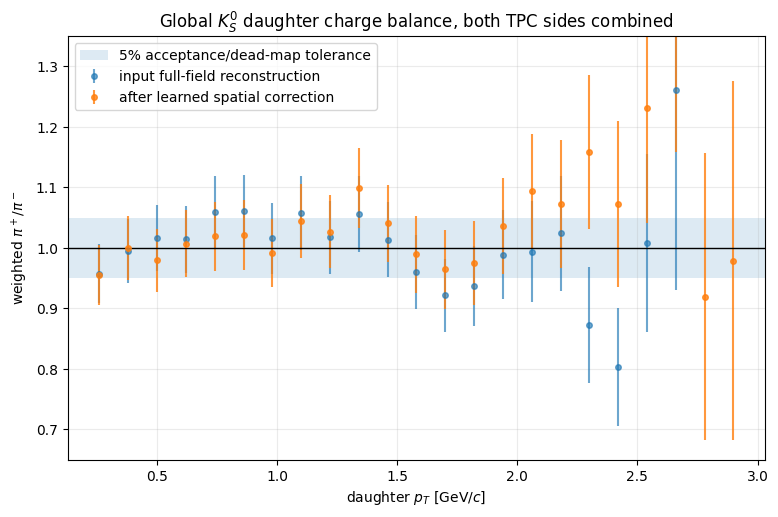

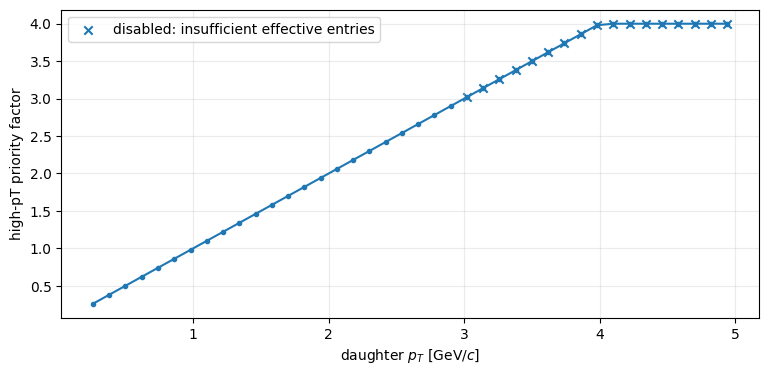

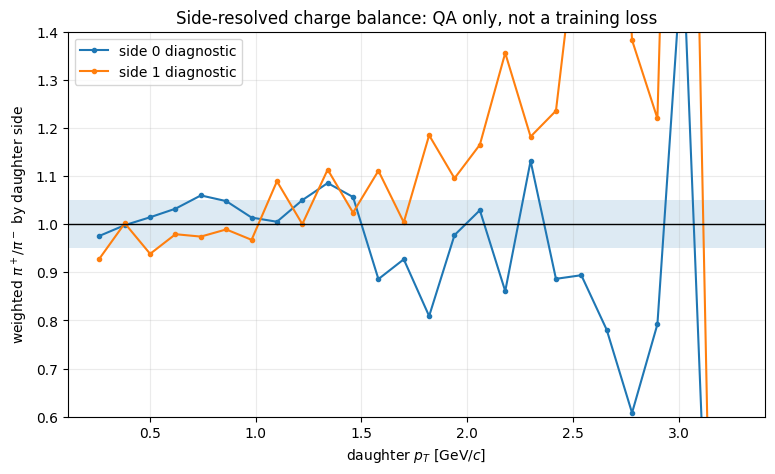

In [19]:
# ============================================================
# Held-out global K0S charge-balance validation
# ============================================================

arrays = load_npz_dictionary(kshort_npz_file)

validation_indices = np.flatnonzero(
    arrays['event_parity'].astype(np.int64) == validation_parity
)

if (
    maximum_validation_candidates is not None
    and len(validation_indices) > maximum_validation_candidates
):
    rng = np.random.default_rng(seed + 4242)
    validation_indices = np.sort(
        rng.choice(
            validation_indices,
            size=maximum_validation_candidates,
            replace=False,
        )
    )

validation_loader = DataLoader(
    CandidateDataset(arrays, validation_indices),
    batch_size=min(
        validation_batch_size,
        len(validation_indices),
    ),
    shuffle=False,
    num_workers=0,
)

k0s_validation = evaluate_joint_model(
    joint_ensemble_model,
    validation_loader,
    channel=0,
)

charge_before = k0s_validation['charge_before']
charge_after = k0s_validation['charge_after']

charge_table = pd.DataFrame({
    'pt_center_gev': charge_after['centers'],
    'ratio_before': charge_before['ratio'],
    'ratio_after': charge_after['ratio'],
    'positive_neff_after': charge_after['positive_neff'],
    'negative_neff_after': charge_after['negative_neff'],
    'sigma_log_after': charge_after['sigma_log'],
    'priority': charge_after['priority'],
    'active': charge_after['active'],
})

charge_table.to_csv(
    work_dir / 'global_charge_balance_validation.csv',
    index=False,
)

print(
    'Global charge-balance score:',
    'before =', charge_before['score'],
    'after =', charge_after['score'],
)

fig, ax = plt.subplots(figsize=(9, 5.5))

active_before = charge_before['active']
active_after = charge_after['active']

# Convert sigma(log R) to an approximately symmetric ratio uncertainty.
ratio_error_before = (
    charge_before['ratio']
    * charge_before['sigma_log']
)
ratio_error_after = (
    charge_after['ratio']
    * charge_after['sigma_log']
)

ax.errorbar(
    charge_before['centers'][active_before],
    charge_before['ratio'][active_before],
    yerr=ratio_error_before[active_before],
    fmt='o',
    ms=4,
    alpha=0.65,
    label='input full-field reconstruction',
)

ax.errorbar(
    charge_after['centers'][active_after],
    charge_after['ratio'][active_after],
    yerr=ratio_error_after[active_after],
    fmt='o',
    ms=4,
    alpha=0.8,
    label='after learned spatial correction',
)

ax.axhline(1.0, color='black', lw=1.0)
ax.axhspan(
    1.0 - charge_balance_systematic_floor_fraction,
    1.0 + charge_balance_systematic_floor_fraction,
    alpha=0.15,
    label='5% acceptance/dead-map tolerance',
)

ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$')
ax.set_title(
    r'Global $K^0_S$ daughter charge balance, both TPC sides combined'
)
ax.set_ylim(0.65, 1.35)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

# Show how much priority is assigned to statistically usable high-pT bins.
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    charge_after['centers'],
    charge_after['priority'],
    marker='o',
    ms=3,
)
ax.scatter(
    charge_after['centers'][~charge_after['active']],
    charge_after['priority'][~charge_after['active']],
    marker='x',
    label='disabled: insufficient effective entries',
)
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel('high-pT priority factor')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


# ------------------------------------------------------------
# Diagnostic only: charge balance by the actual side of each daughter.
# This is NOT used as a training constraint. It helps identify real dead-map
# or acceptance asymmetries that the 5% global systematic floor is intended
# not to overfit.
# ------------------------------------------------------------

validation_arrays_np = k0s_validation['arrays']
validation_weight = (
    validation_arrays_np['pair_weight']
    * validation_arrays_np['signal_probability']
)

side_charge_rows = []

for side in [0, 1]:
    positive_pt_parts = []
    negative_pt_parts = []
    positive_weight_parts = []
    negative_weight_parts = []

    for daughter in [1, 2]:
        daughter_side = validation_arrays_np[f'side{daughter}']
        original_charge = validation_arrays_np[f'charge{daughter}']
        corrected_pt = validation_arrays_np[f'pt{daughter}_after']

        positive = (
            (daughter_side == side)
            & (original_charge > 0)
        )
        negative = (
            (daughter_side == side)
            & (original_charge < 0)
        )

        positive_pt_parts.append(corrected_pt[positive])
        negative_pt_parts.append(corrected_pt[negative])
        positive_weight_parts.append(validation_weight[positive])
        negative_weight_parts.append(validation_weight[negative])

    positive_pt_side = np.concatenate(positive_pt_parts)
    negative_pt_side = np.concatenate(negative_pt_parts)
    positive_weight_side = np.concatenate(positive_weight_parts)
    negative_weight_side = np.concatenate(negative_weight_parts)

    edges = np.linspace(
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins + 1,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])

    nplus, _ = np.histogram(
        positive_pt_side,
        bins=edges,
        weights=positive_weight_side,
    )
    nminus, _ = np.histogram(
        negative_pt_side,
        bins=edges,
        weights=negative_weight_side,
    )

    ratio = nplus / np.maximum(nminus, 1.0e-12)

    for center, value, plus, minus in zip(
        centers,
        ratio,
        nplus,
        nminus,
    ):
        side_charge_rows.append({
            'side': side,
            'pt_center_gev': center,
            'ratio_after': value,
            'weighted_positive': plus,
            'weighted_negative': minus,
        })

side_charge_table = pd.DataFrame(side_charge_rows)
side_charge_table.to_csv(
    work_dir / 'charge_balance_by_side_diagnostic.csv',
    index=False,
)

fig, ax = plt.subplots(figsize=(9, 5))
for side in [0, 1]:
    frame = side_charge_table.loc[
        side_charge_table['side'] == side
    ]
    usable = (
        (frame['weighted_positive'] > 0)
        & (frame['weighted_negative'] > 0)
    )
    ax.plot(
        frame.loc[usable, 'pt_center_gev'],
        frame.loc[usable, 'ratio_after'],
        marker='o',
        ms=3,
        label=f'side {side} diagnostic',
    )

ax.axhline(1.0, color='black', lw=1.0)
ax.axhspan(
    0.95,
    1.05,
    alpha=0.15,
)
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$ by daughter side')
ax.set_title('Side-resolved charge balance: QA only, not a training loss')
ax.set_ylim(0.6, 1.4)
ax.grid(alpha=0.25)
ax.legend()
plt.show()


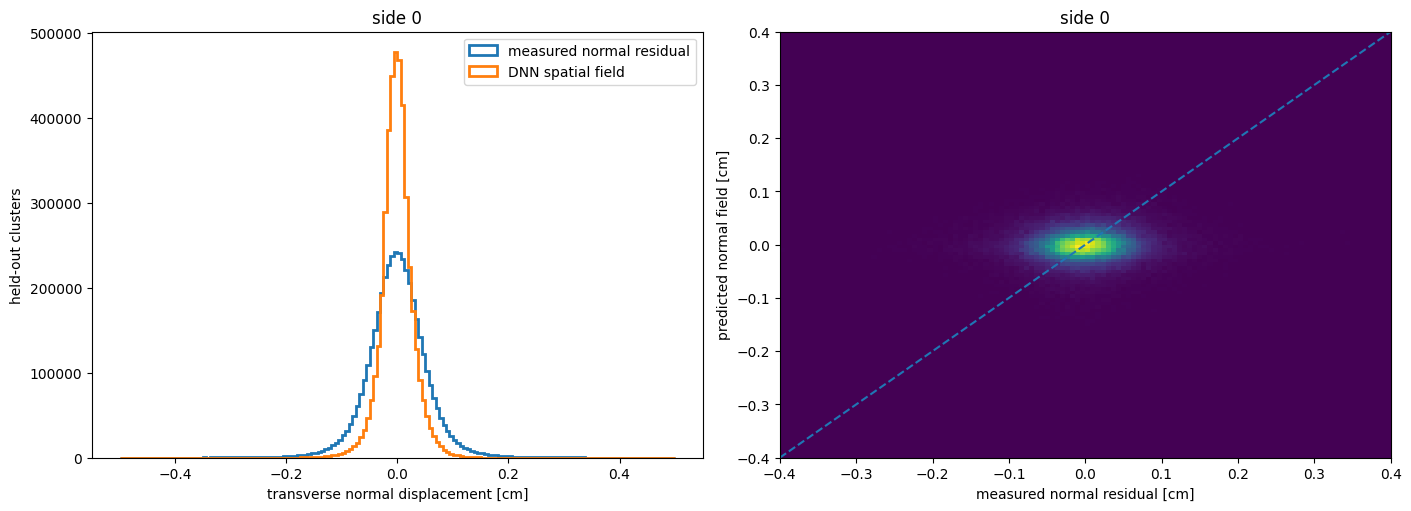

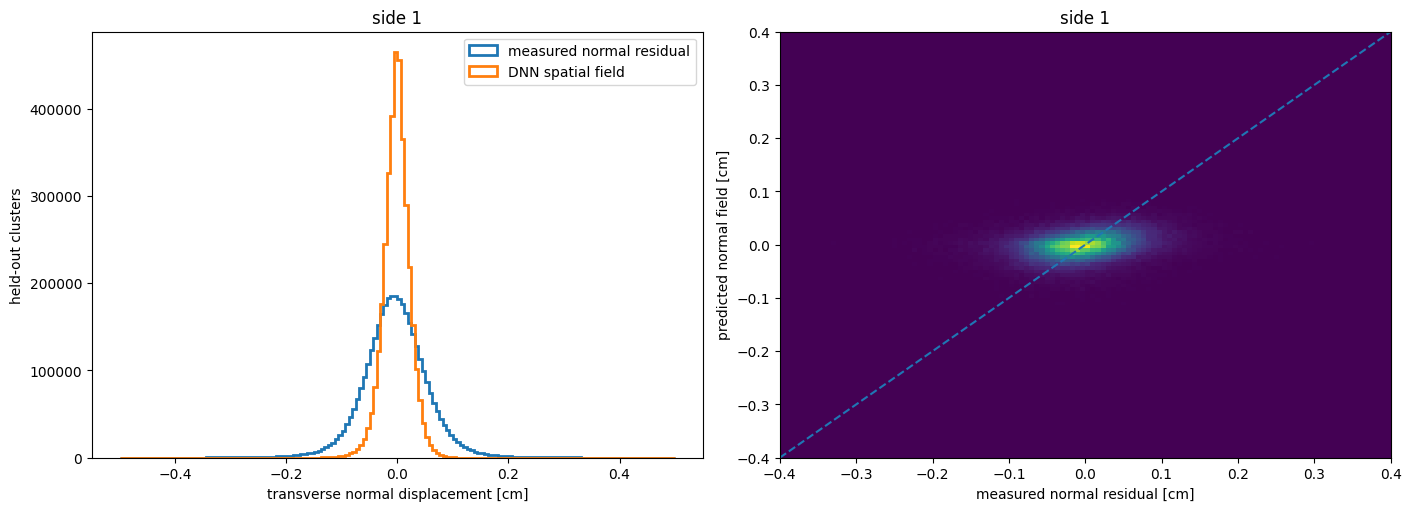

,side,clusters,target_mean,prediction_mean,rmse,correlation
0,0,4315093,-0.000626,-0.001097,0.082910,0.028861
1,1,3715467,-0.004399,-0.001906,0.078964,0.162607


In [20]:
# ============================================================
# Held-out residual-prediction QA
# ============================================================

residual_qa_rows = []

arrays = load_npz_dictionary(kshort_npz_file)
validation_indices = np.flatnonzero(
    arrays['event_parity'].astype(np.int64) == validation_parity
)

for side in [0, 1]:
    flat = flatten_training_clusters_for_side(
        arrays,
        validation_indices,
        side,
    )

    model = ensemble_models[side]

    prediction_chunks = []
    chunk_size = 200000

    with torch.no_grad():
        for start in range(0, len(flat['r']), chunk_size):
            stop = min(start + chunk_size, len(flat['r']))

            r_tensor = torch.from_numpy(flat['r'][start:stop])
            phi_tensor = torch.from_numpy(flat['phi'][start:stop])
            z_tensor = torch.from_numpy(flat['z'][start:stop])

            delta_r, r_delta_phi, _ = model(
                r_tensor,
                phi_tensor,
                z_tensor,
            )

            predicted_normal = (
                delta_r.cpu().numpy()
                * flat['normal_projection_r'][start:stop]
                + r_delta_phi.cpu().numpy()
                * flat['normal_projection_rphi'][start:stop]
            )

            prediction_chunks.append(predicted_normal)

    predicted_normal = np.concatenate(prediction_chunks)
    target_normal = flat['res_normal']

    correlation = (
        float(np.corrcoef(predicted_normal, target_normal)[0, 1])
        if np.std(predicted_normal) > 0 and np.std(target_normal) > 0
        else np.nan
    )

    residual_qa_rows.append({
        'side': side,
        'clusters': len(target_normal),
        'target_mean': float(np.mean(target_normal)),
        'prediction_mean': float(np.mean(predicted_normal)),
        'rmse': float(np.sqrt(np.mean((predicted_normal - target_normal) ** 2))),
        'correlation': correlation,
    })

    figure, axes = plt.subplots(
        1, 2,
        figsize=(14, 5),
        constrained_layout=True,
    )

    axes[0].hist(
        target_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='measured normal residual',
    )

    axes[0].hist(
        predicted_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='DNN spatial field',
    )

    axes[0].set_xlabel('transverse normal displacement [cm]')
    axes[0].set_ylabel('held-out clusters')
    axes[0].set_title(f'side {side}')
    axes[0].legend()

    sample_size = min(100000, len(target_normal))
    sample = np.random.default_rng(seed + side).choice(
        len(target_normal),
        size=sample_size,
        replace=False,
    )

    axes[1].hist2d(
        target_normal[sample],
        predicted_normal[sample],
        bins=120,
        range=[[-0.4, 0.4], [-0.4, 0.4]],
    )

    axes[1].plot(
        [-0.4, 0.4],
        [-0.4, 0.4],
        linestyle='--',
    )
    axes[1].set_xlabel('measured normal residual [cm]')
    axes[1].set_ylabel('predicted normal field [cm]')
    axes[1].set_title(f'side {side}')

    plt.show()

residual_qa_summary = pd.DataFrame(residual_qa_rows)
residual_qa_summary.to_csv(
    work_dir / 'heldout_residual_qa.csv',
    index=False,
)

display(residual_qa_summary)


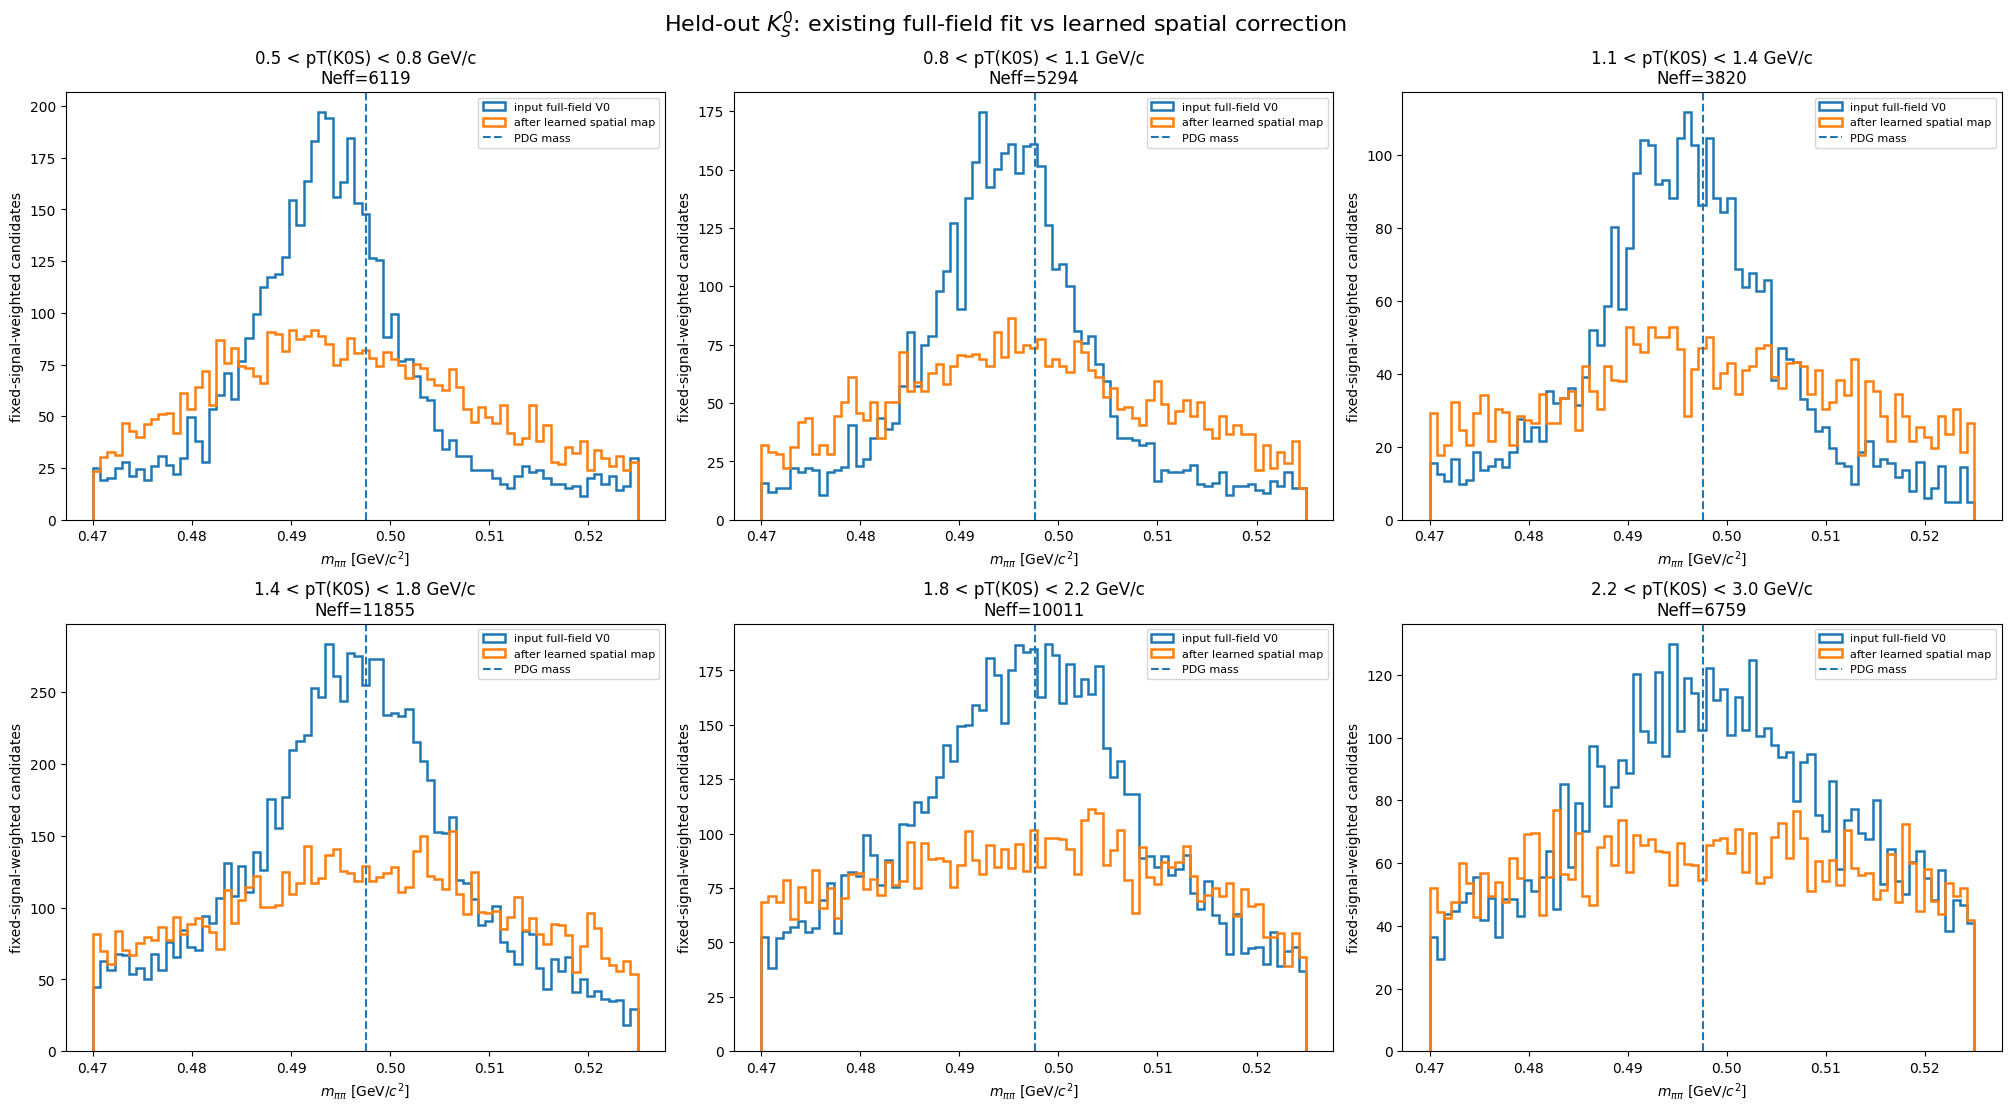

,pt_low,pt_high,entries,neff,mean_input,mean_after,mean_error_input_mev,mean_error_after_mev,width_input_mev,width_after_mev
0,0.5,0.8,6120,6118.533939,0.495739,0.497437,-1.872279,-0.173759,19.951870,24.728101
1,0.8,1.1,5295,5294.309947,0.496609,0.498810,-1.001684,1.198553,18.374938,25.589971
2,1.1,1.4,3820,3819.521642,0.495412,0.497995,-2.199198,0.384210,19.038152,27.719771
3,1.4,1.8,11858,11855.273224,0.495217,0.497463,-2.394296,-0.147741,19.771595,30.672799
4,1.8,2.2,10019,10011.074229,0.495821,0.497410,-1.789647,-0.200933,21.671062,33.281548
5,2.2,3.0,6831,6758.795457,0.498994,0.498935,1.383075,1.323576,22.738250,34.853320


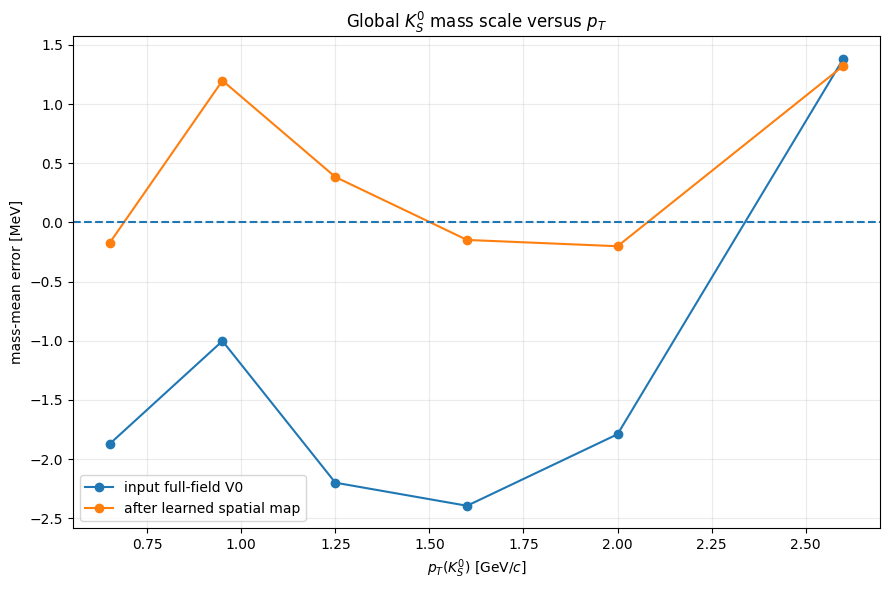

,daughter,side,tracks,mean_scale,rms_scale,q16,median,q84
0,1,0,27653,1.001673,0.077812,0.953124,0.999943,1.049399
1,1,1,22347,1.021273,0.077115,0.971848,1.018722,1.075457
2,2,0,26659,1.000552,0.084825,0.943163,0.998559,1.059168
3,2,1,23341,1.023333,0.084841,0.965722,1.021297,1.090015


In [21]:
# ============================================================
# Held-out K0S mass validation: input full-field reconstruction vs DNN map
# ============================================================

arrays = k0s_validation['arrays']
physics_weight = (
    arrays['pair_weight']
    * arrays['signal_probability']
)

kshort_validation_rows = []

figure, axes = plt.subplots(
    2, 3,
    figsize=(20, 11),
    constrained_layout=True,
)
axes = axes.ravel()

for axis, lower, upper in zip(
    axes,
    pt_mass_scale_bin_edges[:-1],
    pt_mass_scale_bin_edges[1:],
):
    selection = (
        (arrays['pair_pt'] >= lower)
        & (arrays['pair_pt'] < upper)
    )

    before = arrays['mass_before'][selection]
    after = arrays['mass_after'][selection]
    weights = physics_weight[selection]

    before_metrics = peak_metrics(before, weights)
    after_metrics = peak_metrics(after, weights)

    kshort_validation_rows.append({
        'pt_low': float(lower),
        'pt_high': float(upper),
        'entries': int(np.count_nonzero(selection)),
        'neff': after_metrics['neff'],
        'mean_input': before_metrics['mean'],
        'mean_after': after_metrics['mean'],
        'mean_error_input_mev': 1000.0 * (
            before_metrics['mean'] - pdg_kshort_mass
        ),
        'mean_error_after_mev': 1000.0 * (
            after_metrics['mean'] - pdg_kshort_mass
        ),
        'width_input_mev': 1000.0 * before_metrics['width'],
        'width_after_mev': 1000.0 * after_metrics['width'],
    })

    axis.hist(
        before,
        bins=75,
        range=(0.47, 0.525),
        weights=weights,
        histtype='step',
        linewidth=1.8,
        label='input full-field V0',
    )

    axis.hist(
        after,
        bins=75,
        range=(0.47, 0.525),
        weights=weights,
        histtype='step',
        linewidth=1.8,
        label='after learned spatial map',
    )

    axis.axvline(
        pdg_kshort_mass,
        linestyle='--',
        linewidth=1.5,
        label='PDG mass',
    )

    axis.set_title(
        f'{lower:.1f} < pT(K0S) < {upper:.1f} GeV/c\n'
        f'Neff={after_metrics["neff"]:.0f}'
    )
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('fixed-signal-weighted candidates')
    axis.legend(fontsize=8)

figure.suptitle(
    r'Held-out $K^0_S$: existing full-field fit vs learned spatial correction',
    fontsize=16,
)
plt.show()

kshort_validation_frame = pd.DataFrame(kshort_validation_rows)
kshort_validation_frame.to_csv(
    work_dir / 'kshort_mass_scale_vs_pt.csv',
    index=False,
)
display(kshort_validation_frame)

pt_center = 0.5 * (
    kshort_validation_frame['pt_low'].to_numpy(float)
    + kshort_validation_frame['pt_high'].to_numpy(float)
)

plt.figure(figsize=(9, 6))
plt.plot(
    pt_center,
    kshort_validation_frame['mean_error_input_mev'],
    marker='o',
    label='input full-field V0',
)
plt.plot(
    pt_center,
    kshort_validation_frame['mean_error_after_mev'],
    marker='o',
    label='after learned spatial map',
)
plt.axhline(0.0, linestyle='--', linewidth=1.5)
plt.xlabel(r'$p_T(K^0_S)$ [GeV/$c$]')
plt.ylabel('mass-mean error [MeV]')
plt.title(r'Global $K^0_S$ mass scale versus $p_T$')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(
    work_dir / 'kshort_mass_scale_vs_pt.pdf'
)
plt.show()


# Momentum-scale response, separated by the actual TPC side of each daughter.
scale_rows = []

for daughter in [1, 2]:
    side_values = arrays[f'side{daughter}']
    scale_values = arrays[f'momentum_scale{daughter}']

    for side in [0, 1]:
        selected = side_values == side
        values = scale_values[selected]

        scale_rows.append({
            'daughter': daughter,
            'side': side,
            'tracks': int(np.count_nonzero(selected)),
            'mean_scale': float(np.mean(values)) if len(values) else np.nan,
            'rms_scale': float(np.std(values)) if len(values) else np.nan,
            'q16': float(np.quantile(values, 0.16)) if len(values) else np.nan,
            'median': float(np.quantile(values, 0.50)) if len(values) else np.nan,
            'q84': float(np.quantile(values, 0.84)) if len(values) else np.nan,
        })

scale_frame = pd.DataFrame(scale_rows)
scale_frame.to_csv(
    work_dir / 'momentum_scale_by_daughter_side.csv',
    index=False,
)
display(scale_frame)


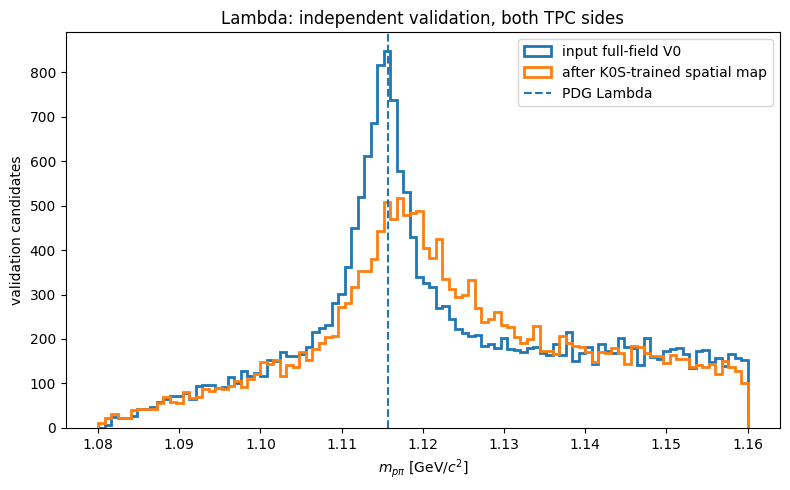

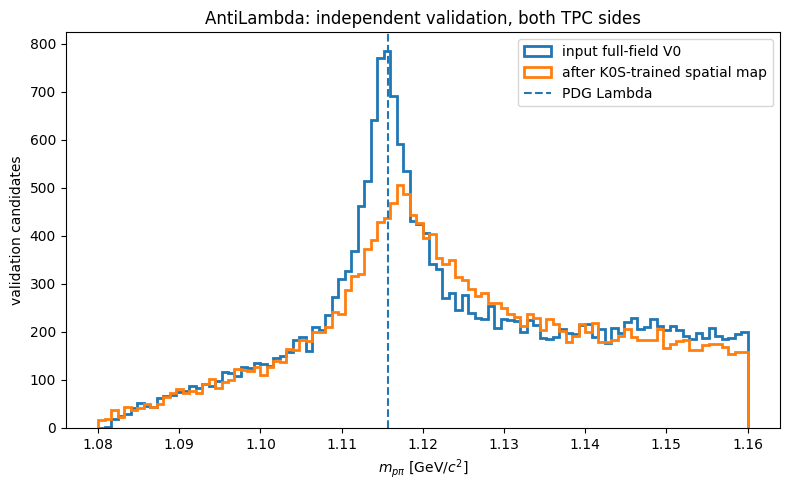

,channel,entries,mean_before,mean_after,width_before,width_after,mean_shift_mev
0,Lambda,20440,1.123072,1.126807,0.017862,0.020546,3.735366
1,AntiLambda,21842,1.124427,1.128011,0.018208,0.021316,3.584151


In [22]:
# ============================================================
# Lambda and anti-Lambda validation only
# ============================================================
#
# These channels are never used in the K0S training loss. They are a useful
# external check of whether the learned spatial map improves another V0 mass
# hypothesis without being explicitly trained to do so.

lambda_rows = []

for channel, label in [(1, 'Lambda'), (2, 'AntiLambda')]:
    if channel not in validation_npz_files:
        print(f'No cached {label} validation sample')
        continue

    arrays = load_npz_dictionary(
        validation_npz_files[channel]
    )

    indices = np.flatnonzero(
        arrays['event_parity'].astype(np.int64) == validation_parity
    )

    if len(indices) == 0:
        continue

    if (
        maximum_validation_candidates is not None
        and len(indices) > maximum_validation_candidates
    ):
        rng = np.random.default_rng(seed + 7000 + channel)
        indices = np.sort(
            rng.choice(
                indices,
                size=maximum_validation_candidates,
                replace=False,
            )
        )

    loader = DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=min(validation_batch_size, len(indices)),
        shuffle=False,
        num_workers=0,
    )

    metrics = evaluate_joint_model(
        joint_ensemble_model,
        loader,
        channel=channel,
    )

    before = metrics['arrays']['mass_before']
    after = metrics['arrays']['mass_after']

    lambda_rows.append({
        'channel': label,
        'entries': len(indices),
        'mean_before': metrics['before_peak']['mean'],
        'mean_after': metrics['after_peak']['mean'],
        'width_before': metrics['before_peak']['width'],
        'width_after': metrics['after_peak']['width'],
        'mean_shift_mev': 1000.0 * (
            metrics['after_peak']['mean']
            - metrics['before_peak']['mean']
        ),
    })

    plt.figure(figsize=(8, 5))

    plt.hist(
        before,
        bins=100,
        range=(1.08, 1.16),
        histtype='step',
        linewidth=2,
        label='input full-field V0',
    )

    plt.hist(
        after,
        bins=100,
        range=(1.08, 1.16),
        histtype='step',
        linewidth=2,
        label='after K0S-trained spatial map',
    )

    plt.axvline(
        1.115683,
        linestyle='--',
        label='PDG Lambda',
    )

    plt.xlabel(r'$m_{p\pi}$ [GeV/$c^2$]')
    plt.ylabel('validation candidates')
    plt.title(f'{label}: independent validation, both TPC sides')
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        work_dir / f'{label.lower()}_validation_global.pdf'
    )
    plt.show()

lambda_summary = pd.DataFrame(lambda_rows)
lambda_summary.to_csv(
    work_dir / 'lambda_validation.csv',
    index=False,
)

display(lambda_summary)


## Export the physical detector-space map

Each side histogram retains the full signed-\(z\) axis for compatibility, but the model returns zero outside that side's physical domain.

The exported map contains the sum of:

- the smooth drift-dependent DNN correction;
- the fitted side-level pad-plane offset and tilt-like field;
- the fitted local module displacement.

The QA panels include the pad-plane endpoint, where transverse corrections are now allowed to be nonzero while \(\Delta z\) remains zero.


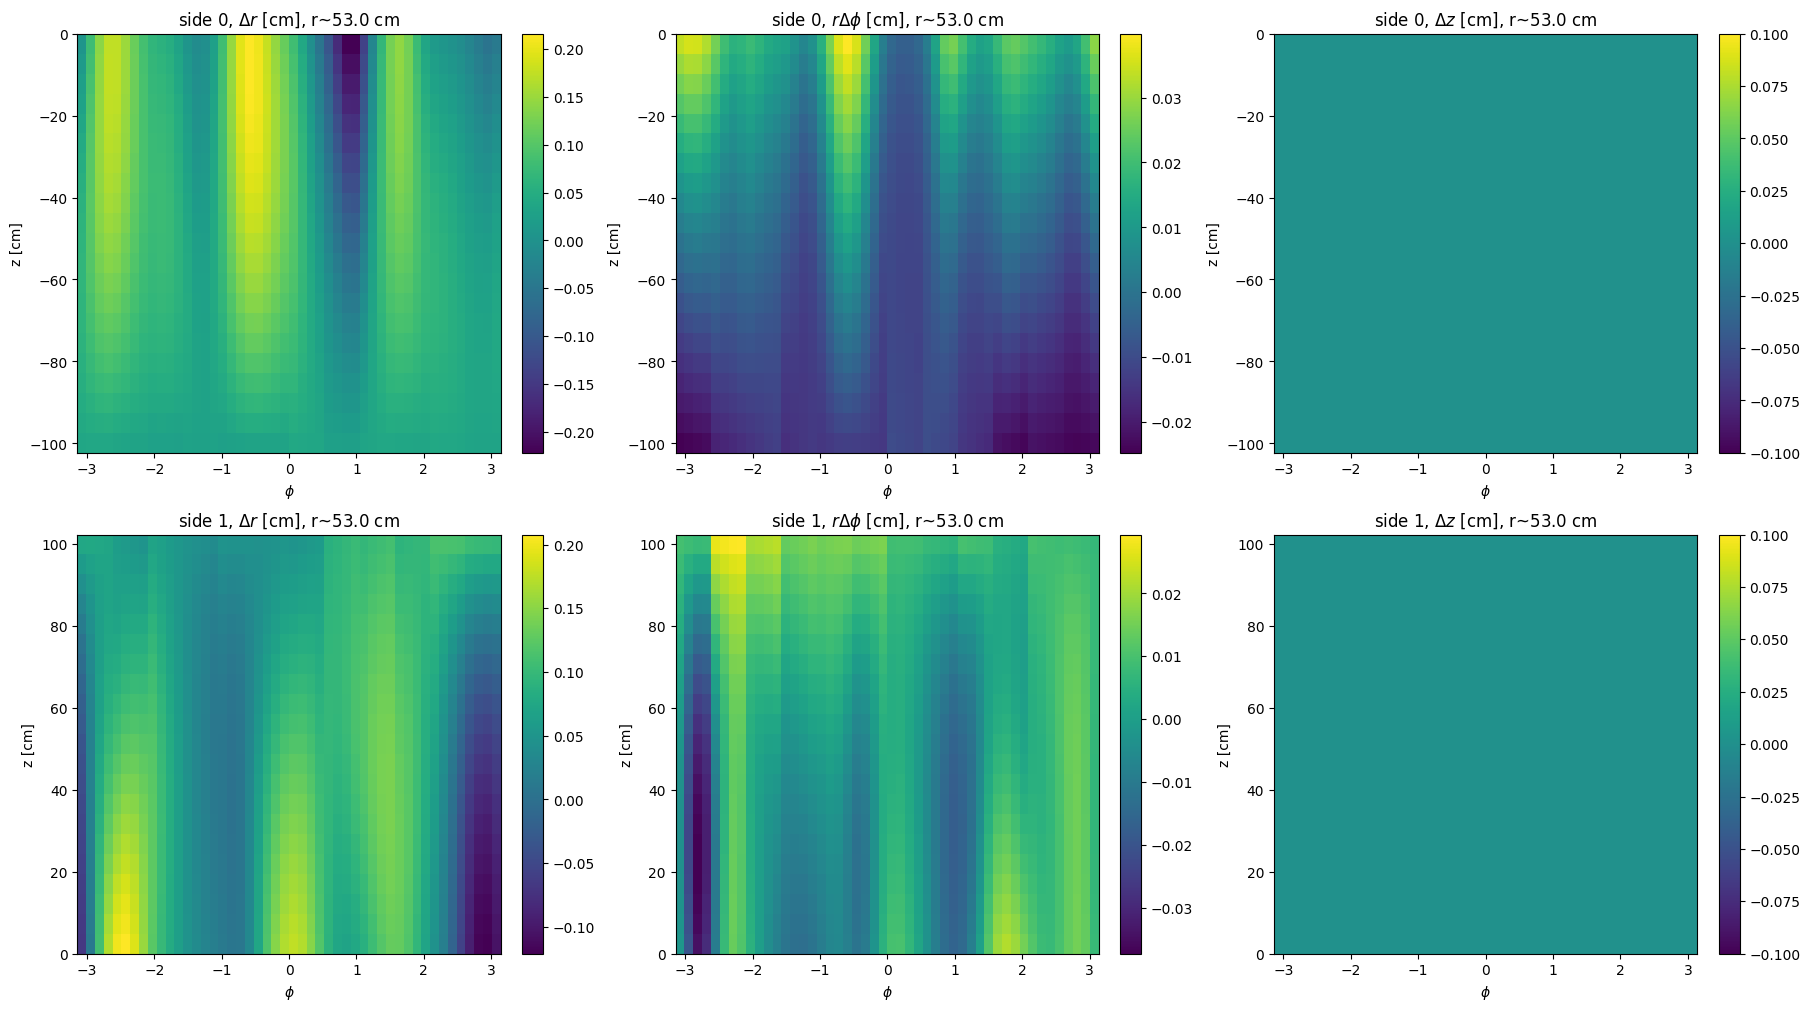

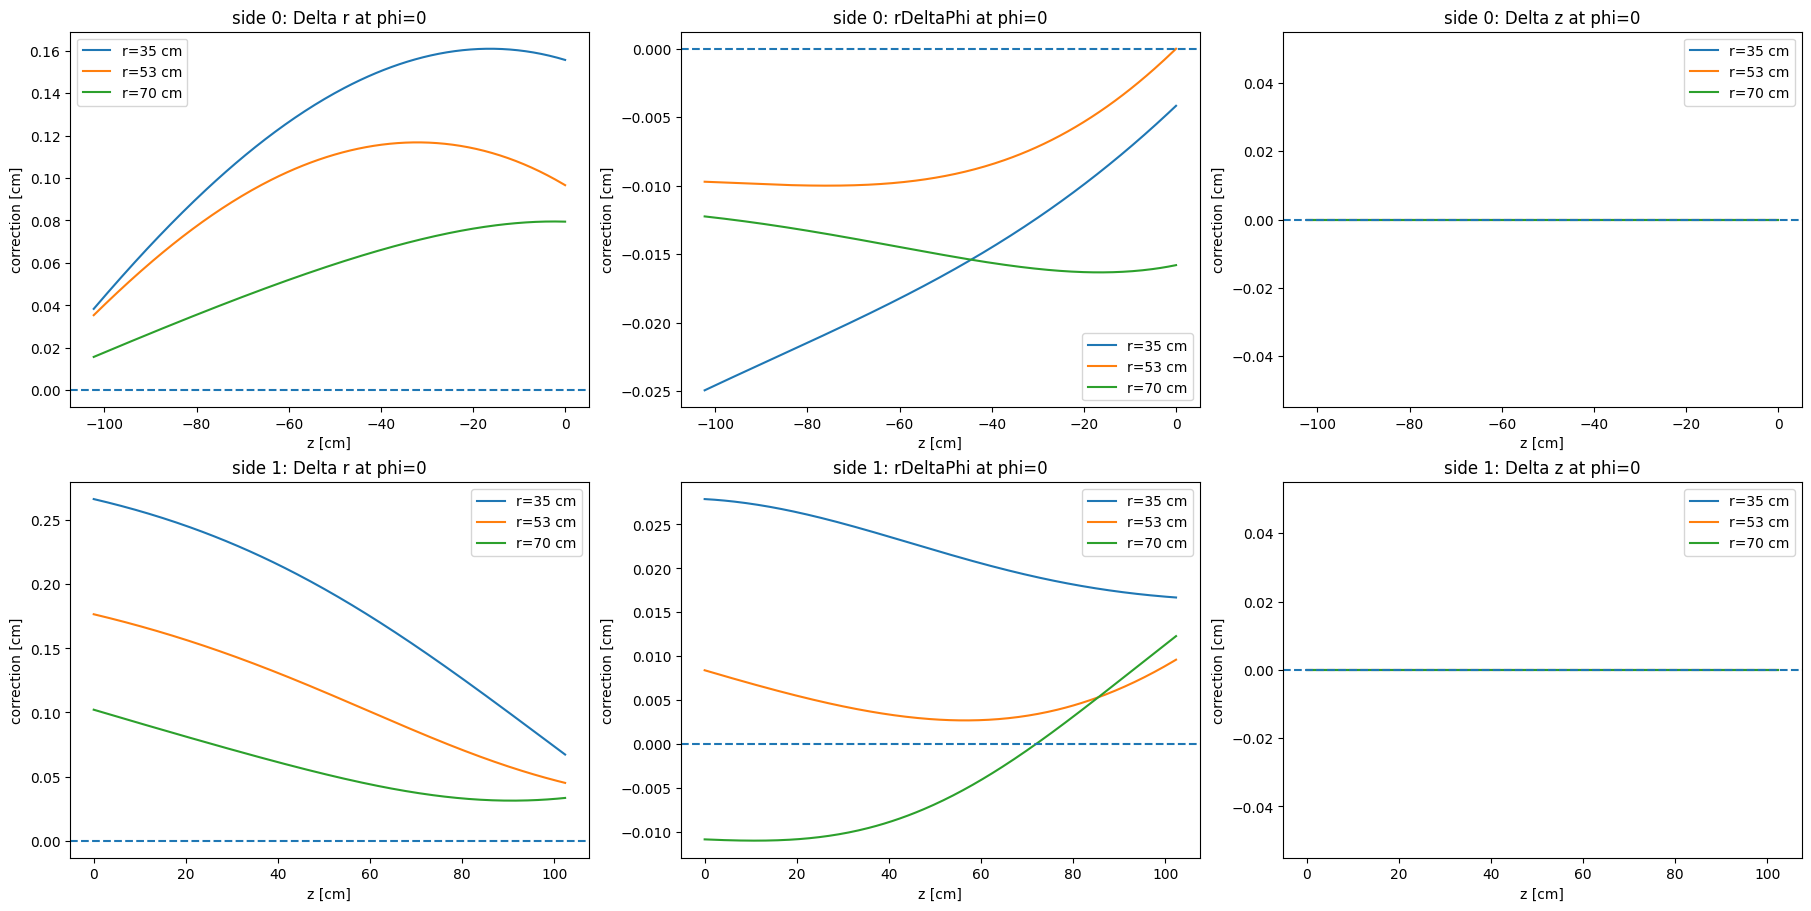

Wrote: output/v0_spatial_residual_dnn_v8_fullfield_globalbalance_wide/v0_spatial_map_transverse_only_wide.root


In [23]:
# ============================================================
# Spatial-map QA and ROOT export
# ============================================================

r_edges = np.linspace(30.5, 76.5, 47)
phi_edges = np.linspace(-math.pi, math.pi, 49)
z_edges = np.linspace(-z_pad_cm, z_pad_cm, 43)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

map_rows = []

for side in [0, 1]:
    r_grid, phi_grid, z_grid = np.meshgrid(
        r_centers,
        phi_centers,
        z_centers,
        indexing='ij',
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            torch.from_numpy(r_grid.astype(np.float32)),
            torch.from_numpy(phi_grid.astype(np.float32)),
            torch.from_numpy(z_grid.astype(np.float32)),
        )

    for (
        radius_value,
        phi_value,
        z_value,
        delta_r_value,
        r_delta_phi_value,
        delta_z_value,
    ) in zip(
        r_grid.ravel(),
        phi_grid.ravel(),
        z_grid.ravel(),
        delta_r.numpy().ravel(),
        r_delta_phi.numpy().ravel(),
        delta_z.numpy().ravel(),
    ):
        map_rows.append({
            'side': side,
            'r': radius_value,
            'phi': phi_value,
            'z': z_value,
            'delta_r': delta_r_value,
            'rdelta_phi': r_delta_phi_value,
            'delta_z': delta_z_value,
        })

map_frame = pd.DataFrame(map_rows)
map_frame.to_csv(
    work_dir / 'v0_spatial_residual_map_grid.csv',
    index=False,
)

# Physical phi-z slices near r=53 cm.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    constrained_layout=True,
)

selected_radius = r_centers[
    np.argmin(np.abs(r_centers - 53.0))
]

for side in [0, 1]:
    if side == 0:
        physical_z_selection = map_frame['z'] <= 0.0
    else:
        physical_z_selection = map_frame['z'] >= 0.0

    subset = map_frame.loc[
        (map_frame['side'] == side)
        & np.isclose(map_frame['r'], selected_radius)
        & physical_z_selection
    ]

    for column_index, (column, title) in enumerate([
        ('delta_r', r'$\Delta r$ [cm]'),
        ('rdelta_phi', r'$r\Delta\phi$ [cm]'),
        ('delta_z', r'$\Delta z$ [cm]'),
    ]):
        values = subset.pivot(
            index='z',
            columns='phi',
            values=column,
        )

        image = axes[side, column_index].pcolormesh(
            values.columns,
            values.index,
            values.values,
            shading='auto',
        )

        axes[side, column_index].set_xlabel(r'$\phi$')
        axes[side, column_index].set_ylabel('z [cm]')
        axes[side, column_index].set_title(
            f'side {side}, {title}, r~{selected_radius:.1f} cm'
        )

        figure.colorbar(
            image,
            ax=axes[side, column_index],
        )

plt.show()

# Explicit z profiles showing the nonzero transverse pad-plane endpoint.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True,
)

profile_phi = 0.0
profile_radii = [35.0, 53.0, 70.0]

for side in [0, 1]:
    z_profile = (
        np.linspace(-z_pad_cm, 0.0, 240)
        if side == 0
        else np.linspace(0.0, z_pad_cm, 240)
    )

    for radius_value in profile_radii:
        with torch.no_grad():
            delta_r, r_delta_phi, delta_z = ensemble_models[side](
                torch.full((len(z_profile),), radius_value),
                torch.full((len(z_profile),), profile_phi),
                torch.from_numpy(z_profile.astype(np.float32)),
            )

        axes[side, 0].plot(
            z_profile,
            delta_r.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 1].plot(
            z_profile,
            r_delta_phi.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 2].plot(
            z_profile,
            delta_z.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

    axes[side, 0].set_title(f'side {side}: Delta r at phi=0')
    axes[side, 1].set_title(f'side {side}: rDeltaPhi at phi=0')
    axes[side, 2].set_title(f'side {side}: Delta z at phi=0')

    for axis in axes[side]:
        axis.axhline(0.0, linestyle='--')
        axis.set_xlabel('z [cm]')
        axis.set_ylabel('correction [cm]')
        axis.legend()

plt.show()

root_file = work_dir / (
    f'v0_spatial_map_with_z_{geometry_profile_name}.root'
    if include_z_correction
    else f'v0_spatial_map_transverse_only_{geometry_profile_name}.root'
)

if root is None:
    print('PyROOT unavailable; ROOT map not written')
else:
    output = root.TFile.Open(str(root_file), 'RECREATE')

    root.TNamed(
        'residual_convention',
        'map is measured-minus-fit field; apply corrected cluster = measured - map',
    ).Write()

    root.TNamed(
        'transverse_training_constraint',
        'normal projection: dn = delta_r*(n.er) + rdelta_phi*(n.ephi)',
    ).Write()

    root.TNamed(
        'pad_plane_boundary',
        (
            f'transverse side/module alignment may be nonzero at '
            f'abs(z)={z_pad_cm} cm; Delta z remains zero'
        ),
    ).Write()

    root.TNamed(
        'geometry_profile',
        geometry_profile_name,
    ).Write()

    root.TNamed(
        'geometry_limits_cm',
        json.dumps({
            'maximum_side_offset_cm': maximum_side_offset_cm,
            'maximum_side_tilt_displacement_cm': (
                maximum_side_tilt_displacement_cm
            ),
            'maximum_module_offset_cm': maximum_module_offset_cm,
            'minimum_tpc_modules_per_track': (
                minimum_tpc_modules_per_track
            ),
        }),
    ).Write()

    root.TNamed(
        'include_z_correction',
        str(int(include_z_correction)),
    ).Write()

    root.TNamed(
        'training_field_response',
        (
            'full-vector magnetic-field relative q/p response; '
            f'field mode={field_evaluation_mode}; '
            'zero spatial correction preserves the input full-field V0 momentum'
        ),
    ).Write()

    root.TNamed(
        'charge_balance_constraint',
        (
            'global K0S pi+/pi- daughter pT balance across both TPC sides; '
            f'systematic floor={charge_balance_systematic_floor_fraction:.3f}; '
            f'high-pT priority power={charge_balance_pt_priority_power:.3f}'
        ),
    ).Write()

    root.TNamed(
        'fixed_k0s_signal_model',
        json.dumps(fixed_mass_model),
    ).Write()

    for side in [0, 1]:
        directory = output.mkdir(f'side{side}')
        directory.cd()

        histograms = {
            'h3_delta_r': root.TH3D(
                'h3_delta_r',
                'Delta r;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_rdelta_phi': root.TH3D(
                'h3_rdelta_phi',
                'rDeltaPhi;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_delta_z': root.TH3D(
                'h3_delta_z',
                'Delta z;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
        }

        subset = map_frame.loc[
            map_frame['side'] == side
        ]

        for row in subset.itertuples(index=False):
            for name, column in [
                ('h3_delta_r', 'delta_r'),
                ('h3_rdelta_phi', 'rdelta_phi'),
                ('h3_delta_z', 'delta_z'),
            ]:
                histogram = histograms[name]
                histogram.SetBinContent(
                    histogram.FindBin(row.r, row.phi, row.z),
                    getattr(row, column),
                )

        for histogram in histograms.values():
            histogram.Write()

    output.Close()
    print('Wrote:', root_file)


## Applying the map in production

The exported ROOT object is still a **detector-space residual correction map**, not a momentum-scale lookup table:

\[
\vec x_{\rm corrected}
=
\vec x_{\rm measured}
-
\Delta\vec x_{\rm learned}.
\]

After applying the map to TPC clusters, run the ordinary C++ V0 track fit with the real sPHENIX magnetic-field map.  The fast full-vector \(q/p\) estimator in this notebook exists only to make the physics loss differentiable and fast enough for training; it is **not** intended to replace the production Kalman/RKN propagation.

This separation is useful: the final object remains a spatial calibration, while the K0S mass and charge-balance information constrain that calibration through a field-aware track response.


## Recommended first run and checks

Start with the default

```python
field_evaluation_mode = 'linearized'
charge_balance_systematic_floor_fraction = 0.05

charge_balance_loss_weight = 1.00
pt_mass_scale_loss_weight = 0.70
inclusive_mass_loss_weight = 0.15
residual_loss_weight = 0.08
```

Before trusting a trained map, check these in order:

1. **Field linearization QA** — random 1–5 mm cluster displacements should give very small differences between the linearized and exact field lookup. If not, switch a short test to `field_evaluation_mode='torch_trilinear'`.
2. **Zero-map identity test** — zero spatial correction must leave the input full-field K0S momentum/mass unchanged apart from floating-point/recalculation differences.
3. **Global charge ratio** — the held-out weighted \(\pi^+/\pi^-\) spectrum should move toward one without the last high-pT bins being driven by tiny effective statistics. The gray band in the validation plot is the explicit 5% dead-map/acceptance tolerance.
4. **K0S mass vs pT** — improvement should occur without a significant peak-width penalty.
5. **Residual QA** — residual agreement may improve modestly, but it is intentionally a weaker constraint during physics fine-tuning.
6. **Lambda / anti-Lambda validation** — these channels are not used in training; a consistent improvement is therefore a particularly valuable cross-check.
7. **Map morphology** — inspect the exported \(r,\phi,z\) map and pad-plane alignment parameters. Reject solutions that satisfy global physics constraints by creating implausibly sharp local structures.

If the linearized field response gives a promising result, repeat a shorter fine-tuning/validation pass with exact differentiable trilinear field lookup. Agreement of the two is a strong check that the fast approximation is not driving the result.
